<a href="https://colab.research.google.com/github/ferdinandrafols/Mensagens-ao-Congresso-Nacional-2023-2026-/blob/main/AG_RafolsFerdinand_Otimizacao_Hiperparametros_v10_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos Genéticos para Otimização de Hiperparâmetros de Classificadores de Texto
## Aplicação ao Corpus das Mensagens Presidenciais ao Congresso Nacional — Mandato Lula III (2023–2026)

---

| | |
|---|---|
| **Disciplina** | Algoritmos Genéticos |
| **Professor** | Prof. Keiji Yamanaka |
| **Discente** | Ferdinand Rafols |
| **Programa** | PPGEELT/UFU · EL142A · 2026/1 |
| **Repositório** | [`ferdinandrafols/mestrado-llm-acgl`](https://github.com/ferdinandrafols/mestrado-llm-acgl) |

---

## Articulação com o Mestrado

Este notebook é o **terceiro vértice** de uma pesquisa que atravessa três disciplinas do PPGEELT:

| Disciplina | Contribuição para este notebook |
|---|---|
| **Aprendizado de Máquinas (EL142A)** | Corpus, léxico V1, pipeline TF-IDF + classificadores supervisionados |
| **Visualização da Informação** | Paleta de identidade, heatmaps, princípios de Ware & Munzner |
| **Algoritmos Genéticos (este)** | Otimização automática dos hiperparâmetros do pipeline de AM |

**Pergunta central deste notebook:**
> *É possível usar um Algoritmo Genético para encontrar automaticamente a melhor configuração do pipeline TF-IDF + classificador — superando a escolha manual de hiperparâmetros?*

---

## Estrutura do Notebook

| Fase | Conteúdo |
|---|---|
| **0** | Setup do ambiente |
| **1** | Extração do corpus dos PDFs (autocontido) |
| **2** | Léxico V1 — original da Etapa 1 de AM — rotulagem e diagnóstico |
| **3** | Diagnóstico crítico do V1 → motivação para o refinamento |
| **4** | Léxico V3 — refinado — comparação V1 → V3 |
| **5** | Fundamentos do Algoritmo Genético |
| **6** | AG em ação: otimização dos hiperparâmetros |
| **7** | Resultados, visualizações e análise evolutiva |
| **8** | Conclusões e próximos passos |


---

## Versão 10 (V10) — Atualização para a revisão do artigo (RITA)

A **Fase 7**, ao final do notebook, acrescenta três validações pedidas na revisão, **sem alterar as fases anteriores** (preservadas como registro do que foi rodado):

1. **Estimativa de generalização sem viés de seleção** — validação cruzada *aninhada* (seleção de hiperparâmetros no laço interno, avaliação no externo).
2. **Tabela 2 com dispersão e teste de Wilcoxon** entre os classificadores, com o **TF-IDF padronizado** entre os três (corrige a Seção 4.3 do artigo).
3. **Tamanhos de efeito** (rank-biserial) dos testes de Wilcoxon já reportados.

Terminologia padronizada para **«agenda governamental»**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CONFIGURAÇÃO V10 — Persistência no Google Drive
# ============================================================
import os
# >>> AJUSTE para a sua pasta no Drive <<<
DRIVE_BASE = "/content/drive/MyDrive/Mestrado/Etapa4_RITA"
CKPT_DIR  = os.path.join(DRIVE_BASE, "checkpoints")
DIR_DADOS = os.path.join(DRIVE_BASE, "dados")
DIR_FIG   = os.path.join(DRIVE_BASE, "figuras")
for _d in (CKPT_DIR, DIR_DADOS, DIR_FIG):
    os.makedirs(_d, exist_ok=True)
# Onde estão os 4 PDFs. Para não reenviar a cada sessão, suba-os ao Drive e use:
#   PDF_DIR_BASE = os.path.join(DRIVE_BASE, "pdfs")
PDF_DIR_BASE = "/content"
print("V10 — saídas persistentes em:", DRIVE_BASE)
print("PDFs lidos de:", PDF_DIR_BASE)

V10 — saídas persistentes em: /content/drive/MyDrive/Mestrado/Etapa4_RITA
PDFs lidos de: /content


---
# Fase 0 — Setup do Ambiente

Instalamos as bibliotecas necessárias e definimos a paleta de identidade visual do projeto
(compartilhada com os notebooks de AM e Visualização da Informação).


In [ ]:
# Instalação de dependências
!pip install -q pdfplumber scikit-learn pandas numpy matplotlib seaborn

print("✓ Dependências instaladas.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 43.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
✓ Dependências instaladas.


In [ ]:
import re
import gc
import json
import unicodedata
import random
import warnings
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdfplumber

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# ── Paleta de identidade do projeto (compartilhada entre os três notebooks) ──
PALETTE = {
    "navy":  "#0D1B2A",
    "amber": "#F59E0B",
    "2023":  "#059669",
    "2024":  "#10B981",
    "2025":  "#F59E0B",
    "2026":  "#DC2626",
    "muted": "#64748B",
    "light": "#F8FAFC",
    "green": "#16A34A",
    "red":   "#DC2626",
}

# ── Cores por classe temática (9 classes V3) ─────────────────────────────────
CORES_CLASSES = {
    "economia_desenvolvimento":       "#2563EB",
    "programas_sociais":              "#7C3AED",
    "saude":                          "#059669",
    "educacao_ciencia":               "#F59E0B",
    "reforma_agraria_agropecuaria":   "#92400E",
    "politica_externa":               "#0891B2",
    "infraestrutura_logistica":       "#EA580C",
    "meio_ambiente_energia":          "#16A34A",
    "governanca_institucional":       "#6B7280",
    "outros_institucional":           "#D1D5DB",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]   = 110
plt.rcParams["savefig.dpi"]  = 150
plt.rcParams["font.family"]  = "DejaVu Sans"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("✓ Setup concluído.")
print(f"  Paleta: {len(PALETTE)} cores de identidade")
print(f"  Classes: {len(CORES_CLASSES)} (9 temáticas + 1 residual)")


✓ Setup concluído.
  Paleta: 10 cores de identidade
  Classes: 10 (9 temáticas + 1 residual)


---
# Fase 1 — Extração do Corpus dos PDFs

## Corpus: Mensagens Presidenciais ao Congresso Nacional

O corpus é composto por **4 documentos oficiais** emitidos pelo presidente Luiz Inácio Lula da Silva
ao Congresso Nacional durante o terceiro mandato (2023–2026), conforme previsto no Art. 84 da
Constituição Federal.

| Ano | Páginas | Palavras | Arquivo |
|---|---|---|---|
| 2023 | 180 | 40.788 | `MensagemaoCongressoNacional2023.pdf` |
| 2024 | 333 | 109.205 | `mensagemaocongressonacional2024_vf.pdf` |
| 2025 | 668 | 220.982 | `MensagemCongressoNacional2025.pdf` |
| 2026 | 914 | 322.582 | `mensagem-ao-congresso-nacional-2026.pdf` |
| **Total** | **2.095** | **693.557** | — |

> **Nota metodológica:** o volume cresce dramaticamente ao longo do mandato (8× maior em 2026
> comparado a 2023). Por isso, todas as análises temáticas usam **proporções relativas**,
> não contagens absolutas.

## Estratégia de extração: processamento chunked

O PDF de 2026 tem 914 páginas (~11,5 MB). Carregar o arquivo inteiro de uma vez causa
estouro de memória no Colab. A solução é processar em **blocos de 120 páginas**,
fechando e reabrindo o arquivo a cada bloco para liberar RAM.

## Instruções

1. No menu lateral do Colab, clique em **Arquivos** (ícone de pasta)
2. Faça upload dos 4 PDFs na pasta raiz (`/content/`)
3. Execute as células abaixo em sequência


In [ ]:
# ── Catálogo do corpus ────────────────────────────────────────────────────────
MENSAGENS = [
    {"year": 2023, "filename": "MensagemaoCongressoNacional2023.pdf",
     "pages": 180,  "words_real": 40_788},
    {"year": 2024, "filename": "mensagemaocongressonacional2024_vf.pdf",
     "pages": 333,  "words_real": 109_205},
    {"year": 2025, "filename": "MensagemCongressoNacional2025.pdf",
     "pages": 668,  "words_real": 220_982},
    {"year": 2026, "filename": "mensagem-ao-congresso-nacional-2026.pdf",
     "pages": 914,  "words_real": 322_582},
]

PDF_DIR   = Path(PDF_DIR_BASE)        # definido na Configuração V9
CHUNK_SIZE = 120                       # páginas por bloco (evita OOM no 2026)

print("Corpus catalogado:")
df_meta = pd.DataFrame(MENSAGENS)
print(df_meta[["year","filename","pages","words_real"]].to_string(index=False))
print(f"\nTotal: {df_meta['pages'].sum():,} páginas / {df_meta['words_real'].sum():,} palavras")


Corpus catalogado:
 year                                filename  pages  words_real
 2023     MensagemaoCongressoNacional2023.pdf    180       40788
 2024  mensagemaocongressonacional2024_vf.pdf    333      109205
 2025       MensagemCongressoNacional2025.pdf    668      220982
 2026 mensagem-ao-congresso-nacional-2026.pdf    914      322582

Total: 2,095 páginas / 693,557 palavras


In [ ]:
# ── Funções de extração e normalização ───────────────────────────────────────

def normalize_text(text: str) -> str:
    """
    Normalização leve para texto em português extraído de PDF.
    Replica exatamente a função usada no notebook AED (Etapa 1 de AM).
    """
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    # Remove cabeçalhos/rodapés típicos das Mensagens
    text = re.sub(r"^.*Página \d+.*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"^\d+\s*$",         "", text, flags=re.MULTILINE)
    return text.strip()


def segmentar_paragrafos(text: str, year: int,
                          min_words: int = 10,
                          min_chars: int = 60) -> list[dict]:
    """
    Quebra o texto em parágrafos por dupla quebra de linha.

    Filtros aplicados:
    - Mínimo de 10 palavras e 60 caracteres (remove títulos e cabeçalhos curtos)
    - Remove linhas que são apenas números ou símbolos
    """
    raw = re.split(r"\n{2,}", text)
    paras = []
    for p in raw:
        p = re.sub(r"\s+", " ", p).strip()
        if len(p) < min_chars:
            continue
        words = p.split()
        if len(words) < min_words:
            continue
        if re.match(r"^[\d\s\W]{1,30}$", p):
            continue
        paras.append({"text": p, "year": year, "n_words": len(words)})
    return paras


def extract_pdf_chunked(path: Path, year: int,
                         chunk_size: int = CHUNK_SIZE) -> str:
    """
    Extrai texto do PDF em blocos de `chunk_size` páginas.

    Estratégia chunked: abre e fecha o arquivo a cada bloco,
    forçando a liberação de memória pelo garbage collector.
    Essencial para o PDF de 2026 (914 páginas, 11,5 MB).
    """
    total_pages = next(m["pages"] for m in MENSAGENS if m["year"] == year)
    page_texts  = []

    for start in range(0, total_pages, chunk_size):
        end = min(start + chunk_size, total_pages)
        print(f"  [{year}] páginas {start+1}–{end} / {total_pages}", flush=True)
        with pdfplumber.open(path) as pdf:
            for i in range(start, end):
                if i >= len(pdf.pages):
                    break
                t = pdf.pages[i].extract_text()
                if t:
                    page_texts.append(t)
        gc.collect()   # força liberação de RAM após cada bloco

    return normalize_text("\n\n".join(page_texts))


print("✓ Funções de extração definidas.")


✓ Funções de extração definidas.


In [ ]:
# ── Extração efetiva dos 4 PDFs ───────────────────────────────────────────────
# Esta célula leva ~3–5 minutos no Colab (CPU padrão).

all_paragraphs = []

for m in MENSAGENS:
    year = m["year"]
    path = PDF_DIR / m["filename"]

    if not path.exists():
        print(f"⚠️  PDF não encontrado: {path}")
        print(f"   Faça upload do arquivo e reexecute esta célula.")
        continue

    print(f"\nExtraindo {year}...")
    text  = extract_pdf_chunked(path, year)
    paras = segmentar_paragrafos(text, year)
    all_paragraphs.extend(paras)
    print(f"  → {len(paras)} parágrafos extraídos")

df_corpus = pd.DataFrame(all_paragraphs)
print(f"\n{'='*50}")
print(f"Total extraído: {len(df_corpus):,} parágrafos")
print(f"Por ano:")
print(df_corpus.groupby('year').size().to_string())



Extraindo 2023...
  [2023] páginas 1–120 / 180
  [2023] páginas 121–180 / 180
  → 177 parágrafos extraídos

Extraindo 2024...
  [2024] páginas 1–120 / 333
  [2024] páginas 121–240 / 333
  [2024] páginas 241–333 / 333
  → 331 parágrafos extraídos

Extraindo 2025...
  [2025] páginas 1–120 / 668
  [2025] páginas 121–240 / 668
  [2025] páginas 241–360 / 668
  [2025] páginas 361–480 / 668
  [2025] páginas 481–600 / 668
  [2025] páginas 601–668 / 668
  → 676 parágrafos extraídos

Extraindo 2026...
  [2026] páginas 1–120 / 914
  [2026] páginas 121–240 / 914
  [2026] páginas 241–360 / 914
  [2026] páginas 361–480 / 914
  [2026] páginas 481–600 / 914
  [2026] páginas 601–720 / 914
  [2026] páginas 721–840 / 914
  [2026] páginas 841–914 / 914
  → 905 parágrafos extraídos

Total extraído: 2,089 parágrafos
Por ano:
year
2023    177
2024    331
2025    676
2026    905


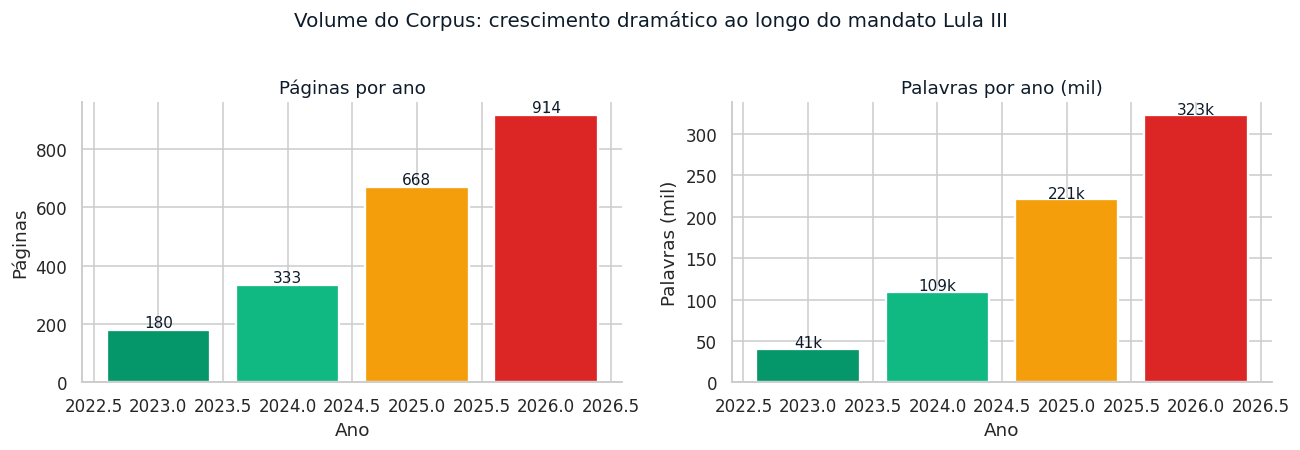

Nota: volume 8× maior em 2026 vs 2023 → análises usam proporções relativas.


In [ ]:
# ── Visualização: volume por ano ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

anos   = [m["year"]   for m in MENSAGENS]
paginas= [m["pages"]  for m in MENSAGENS]
words  = [m["words_real"] for m in MENSAGENS]
cores  = [PALETTE[str(a)] for a in anos]

# Páginas
axes[0].bar(anos, paginas, color=cores, edgecolor="white", linewidth=1.5)
for ax, val in zip(axes[0].patches, paginas):
    axes[0].text(ax.get_x()+ax.get_width()/2, ax.get_height()+10,
                 str(val), ha="center", fontsize=10, color=PALETTE["navy"])
axes[0].set_title("Páginas por ano", fontsize=12, color=PALETTE["navy"])
axes[0].set_xlabel("Ano"); axes[0].set_ylabel("Páginas")

# Palavras
axes[1].bar(anos, [w/1000 for w in words], color=cores, edgecolor="white", linewidth=1.5)
for ax, val in zip(axes[1].patches, words):
    axes[1].text(ax.get_x()+ax.get_width()/2, val/1000+2,
                 f"{val/1000:.0f}k", ha="center", fontsize=10, color=PALETTE["navy"])
axes[1].set_title("Palavras por ano (mil)", fontsize=12, color=PALETTE["navy"])
axes[1].set_xlabel("Ano"); axes[1].set_ylabel("Palavras (mil)")

sns.despine()
plt.suptitle("Volume do Corpus: crescimento dramático ao longo do mandato Lula III",
             fontsize=13, color=PALETTE["navy"], y=1.02)
plt.tight_layout()
plt.show()
print("Nota: volume 8× maior em 2026 vs 2023 → análises usam proporções relativas.")


---
# Fase 1B — Limpeza Estrutural do Corpus

## Por que esta fase existe

Uma auditoria de qualidade dos dados revelou que a extração dos PDFs deixou passar
dois tipos de contaminação que não pertencem ao conteúdo legítimo da agenda governamental:

**1. Cabeçalho/rodapé de página infiltrado.** A string *"Mensagem ao Congresso
Nacional [ano]"* — repetida em quase toda página do PDF — foi concatenada ao texto
real de **1.851 parágrafos** (89% do corpus). Em 99,5% dos casos ela aparece no
início do parágrafo, indicando que é o cabeçalho da página grudado ao conteúdo.

**2. Elementos editoriais não-discursivos.** Sumários (linhas com pontilhados),
títulos de seção em maiúsculas, legendas de gráficos/tabelas, blocos densos de
números (tabelas extraídas como texto), página de catalogação (CDU/ISBN) e listas
de autoridades (ministros).

## Impacto medido

A remoção do cabeçalho **não altera** o F1-macro (Δ ≈ −0,0004): por estar presente
em 89% dos parágrafos de forma uniforme, o TF-IDF já o tratava como ruído de fundo
(IDF baixo). A remoção é, portanto, uma correção de **higiene metodológica**, não
de desempenho.

A remoção dos elementos editoriais **reduz** o F1-macro (de ~0,814 para ~0,785).
Isso é esperado e **desejável**: muitos desses elementos eram títulos-gabarito
(ex.: "5 POLÍTICA EXTERNA E SOBERANIA"), triviais de classificar, que inflavam
artificialmente a métrica. O corpus limpo mede o desempenho no **conteúdo efetivo da agenda**,
sem casos-gabarito — um resultado mais honesto e defensável.

> **Decisão metodológica:** optamos pela limpeza completa, assumindo números menores
> porém mais íntegros, em conformidade com os princípios de reprodutibilidade e análise
> crítica exigidos pela disciplina de Aprendizado de Máquinas.


In [ ]:
# ── Limpeza estrutural do corpus ─────────────────────────────────────────────
# Aplica-se ao df_corpus produzido na Fase 1, ANTES da rotulagem (Fases 2 e 4).

import re as _re

def limpar_cabecalho(texto):
    """Remove o cabeçalho/rodapé 'Mensagem ao Congresso Nacional AAAA' que a
    extração concatenou ao texto. Essa string nunca é conteúdo discursivo."""
    texto = _re.sub(r"\s*Mensagem ao Congresso Nacional \d{4}\s*", " ", texto)
    return _re.sub(r"\s+", " ", texto).strip()

def _frac_maiusculas(t):
    letras = [c for c in t if c.isalpha()]
    return sum(1 for c in letras if c.isupper()) / len(letras) if letras else 0

def _densidade_numerica(t):
    tokens = t.split()
    if not tokens:
        return 0
    return sum(1 for x in tokens if _re.match(r"^[\d.,%-]+$", x)) / len(tokens)

def eh_elemento_editorial(texto):
    """Identifica parágrafos que são estrutura editorial, não discurso.
    Retorna (True, motivo) ou (False, '')."""
    if _re.search(r"\.{4,}", texto):
        return True, "sumario_pontilhado"
    if _frac_maiusculas(texto) > 0.5:
        return True, "titulo_maiusculas"
    if _re.match(r"^(Gráfico|Figura|Tabela|Fonte:|Quadro)\s", texto):
        return True, "legenda_figura"
    if _densidade_numerica(texto) > 0.25:
        return True, "tabela_numerica"
    if _re.search(r"Copyright|CDU|CIP|reprodução sem fins", texto):
        return True, "catalogacao"
    if len(_re.findall(r"Ministr[oa] de Estado", texto)) >= 3:
        return True, "lista_autoridades"
    return False, ""

# ── Aplicar limpeza ───────────────────────────────────────────────────────────
n_inicial = len(df_corpus)

# Passo 1: remover cabeçalho de todos os parágrafos
df_corpus["text"] = df_corpus["text"].apply(limpar_cabecalho)

# Passo 2: marcar e remover elementos editoriais
diag = df_corpus["text"].apply(eh_elemento_editorial)
df_corpus["_eh_editorial"] = [d[0] for d in diag]
df_corpus["_motivo_remocao"] = [d[1] for d in diag]

# Relatório de remoção por categoria
print("RELATÓRIO DE LIMPEZA ESTRUTURAL")
print("=" * 55)
print(f"Cabeçalho 'Mensagem ao Congresso Nacional AAAA' removido de todos os parágrafos.")
print(f"\nElementos editoriais removidos por categoria:")
motivos = df_corpus[df_corpus["_eh_editorial"]]["_motivo_remocao"].value_counts()
for motivo, n in motivos.items():
    print(f"  {motivo:22s}: {n:3d}")

# Passo 3: remover editoriais e parágrafos que ficaram curtos demais
df_corpus = df_corpus[~df_corpus["_eh_editorial"]].copy()
df_corpus = df_corpus[df_corpus["text"].str.len() >= 60].reset_index(drop=True)
df_corpus = df_corpus.drop(columns=["_eh_editorial", "_motivo_remocao"])

n_final = len(df_corpus)
print(f"\nParágrafos: {n_inicial} → {n_final} (removidos {n_inicial - n_final})")
print(f"\n✓ Corpus limpo. As Fases 2 e 4 (rotulagem) operam sobre este corpus.")


RELATÓRIO DE LIMPEZA ESTRUTURAL
Cabeçalho 'Mensagem ao Congresso Nacional AAAA' removido de todos os parágrafos.

Elementos editoriais removidos por categoria:
  legenda_figura        :  82
  sumario_pontilhado    :  21
  catalogacao           :  20
  lista_autoridades     :  10
  tabela_numerica       :   9
  titulo_maiusculas     :   4

Parágrafos: 2089 → 1943 (removidos 146)

✓ Corpus limpo. As Fases 2 e 4 (rotulagem) operam sobre este corpus.


---
# Fase 2 — Léxico V1: Rotulagem Fraca (Etapa 1 de AM)

## O que é rotulagem fraca?

Em NLP supervisionado, precisamos de rótulos (classes) para cada exemplo de treinamento.
Rotular manualmente 2.089 parágrafos seria inviável. A solução é a **rotulagem fraca
por léxico**: definimos listas de palavras-âncora por tema e atribuímos automaticamente
um rótulo a cada parágrafo pela contagem de termos encontrados.

**Regra de decisão:**
1. Para cada classe, conta quantas palavras do léxico aparecem no parágrafo
2. A classe com maior contagem ganha o rótulo
3. Em caso de **empate** → rótulo `outros_institucional` (residual)
4. Se **nenhuma palavra** do léxico aparece → também residual

Esta é exatamente a função implementada no **notebook AED da Etapa 1 de AM**,
reproduzida aqui para garantir consistência entre os três projetos de mestrado.

## Léxico V1 — 7 classes temáticas + 1 residual

O léxico V1 foi desenvolvido para o contexto institucional brasileiro das
Mensagens Presidenciais. As 7 classes temáticas refletem as grandes áreas
de política pública do governo federal.


In [ ]:
# ── LÉXICO V1 — Reprodução fiel do AED (Etapa 1 de AM) ───────────────────────
# Fonte: Etapa1_RafolsFerdinand_AED_CORRIGIDO.ipynb
# Qualquer alteração aqui deve ser documentada e refletida nos outros notebooks.

LEXICON_V1 = {
    "economia_desenvolvimento": {
        "economia", "econômico", "econômica", "pib", "inflação", "fiscal", "tributação",
        "tributo", "imposto", "tributária", "investimento", "investimentos", "crescimento",
        "indústria", "industrial", "inovação", "produtividade", "competitividade", "mercado",
        "emprego", "empregos", "renda", "salário", "trabalhador", "trabalhadores",
        "déficit", "dívida", "monetária", "câmbio", "exportações"
    },
    "programas_sociais": {
        "bolsa", "família", "bolsa-família", "miséria", "pobreza", "fome", "transferência",
        "assistência", "assistencial", "vulnerabilidade", "vulneráveis", "social",
        "inclusão", "cras", "creas", "auxílio", "benefício", "benefícios", "pé-de-meia",
        "previdência", "previdenciária", "aposentadoria"
    },
    "saude": {
        "saúde", "sus", "hospital", "hospitais", "médico", "médicos", "atenção",
        "básica", "ubs", "vacina", "vacinação", "vacinas", "farmácia", "popular",
        "medicamento", "medicamentos", "epidemia", "pandemia", "covid", "doença", "doenças",
        "tratamento", "paciente", "pacientes"
    },
    "educacao_ciencia": {
        "educação", "educacional", "escola", "escolas", "ensino", "fundamental", "médio",
        "universidade", "universidades", "fundeb", "prouni", "fies", "professor", "professores",
        "aluno", "alunos", "estudante", "estudantes", "ciência", "científico", "pesquisa",
        "tecnologia", "tecnológico", "cnpq", "capes", "ifet", "ifets"
    },
    "reforma_agraria_agropecuaria": {
        "agricultura", "agrícola", "agronegócio", "agrário", "agrária", "incra", "reforma",
        "assentamento", "assentamentos", "assentado", "assentados", "rural", "pronaf",
        "agricultor", "agricultores", "produtor", "produção", "pecuária", "pecuarista",
        "fazenda", "campo", "embrapa"
    },
    "politica_externa": {
        "exterior", "externa", "internacional", "internacionais", "mercosul", "brics",
        "onu", "diplomacia", "diplomático", "comércio", "integração", "regional", "sul-sul",
        "acordo", "tratado", "aliança", "embaixada", "embaixador", "itamaraty"
    },
    # NOTA: esta classe funde dois domínios distintos (infraestrutura física e
    # política ambiental). A fusão foi herdada do léxico original do AED.
    # A Fase 3 documenta por que isso é problemático e a Fase 4 apresenta a solução.
    "infraestrutura_meio_ambiente": {
        "infraestrutura", "pac", "energia", "energético", "elétrica", "petróleo", "gás",
        "renovável", "solar", "eólica", "transição", "ambiental", "ambiente", "amazônia",
        "desmatamento", "clima", "climática", "carbono", "saneamento", "transporte",
        "transportes", "rodovia", "rodovias", "ferrovia", "porto", "portos", "aeroporto"
    },
}

RESIDUAL_V1 = "outros_institucional"

total_termos_v1 = sum(len(v) for v in LEXICON_V1.values())
print(f"Léxico V1: {len(LEXICON_V1)} classes temáticas + 1 residual = 8 classes no total")
print(f"Total de termos-âncora: {total_termos_v1}")
print()
for cls, terms in LEXICON_V1.items():
    print(f"  {cls:<35}: {len(terms):2d} termos")


Léxico V1: 7 classes temáticas + 1 residual = 8 classes no total
Total de termos-âncora: 171

  economia_desenvolvimento           : 30 termos
  programas_sociais                  : 22 termos
  saude                              : 24 termos
  educacao_ciencia                   : 27 termos
  reforma_agraria_agropecuaria       : 22 termos
  politica_externa                   : 19 termos
  infraestrutura_meio_ambiente       : 27 termos


In [ ]:
# ── Função de rotulagem (idêntica à do AED) ──────────────────────────────────

def label_by_lexicon(text: str, lexicon: dict, residual: str) -> str:
    """
    Rotula um parágrafo por contagem de termos-âncora.

    Parâmetros
    ----------
    text     : texto do parágrafo
    lexicon  : dicionário {classe: set(termos)}
    residual : rótulo atribuído em caso de empate ou zero hits

    Retorno
    -------
    Rótulo da classe vencedora, ou `residual` se empate/zero.

    Decisão de design (herdada do AED):
    - Tokenização por regex \b[a-záàâãéêíóôõúçü]+\b (apenas letras, sem pontuação)
    - Intersecção de conjuntos → eficiente para vocabulários grandes
    - Empate deliberadamente enviado para residual: melhor não rotular
      do que rotular errado em contexto de aprendizado supervisionado
    """
    tokens    = set(re.findall(r"\b[a-záàâãéêíóôõúçü]+\b", text.lower()))
    scores    = {cls: len(tokens & terms) for cls, terms in lexicon.items()}
    max_score = max(scores.values())

    if max_score == 0:
        return residual                          # nenhuma âncora encontrada

    top = [cls for cls, s in scores.items() if s == max_score]
    if len(top) > 1:
        return residual                          # empate → não decidir

    return top[0]


print("✓ Função de rotulagem definida.")
print("  Algoritmo: tokenização regex → intersecção de conjuntos → máximo único")


✓ Função de rotulagem definida.
  Algoritmo: tokenização regex → intersecção de conjuntos → máximo único


In [ ]:
# ── Aplicar léxico V1 ao corpus ──────────────────────────────────────────────
df_corpus["label_v1"] = df_corpus["text"].apply(
    lambda t: label_by_lexicon(t, LEXICON_V1, RESIDUAL_V1)
)

counts_v1   = df_corpus["label_v1"].value_counts()
residual_n  = counts_v1.get(RESIDUAL_V1, 0)
residual_pct= residual_n / len(df_corpus) * 100

print("Distribuição de rótulos — Léxico V1:")
print(counts_v1.to_string())
print(f"\nResidual: {residual_n} parágrafos ({residual_pct:.1f}%)")
print(f"Rotulados: {len(df_corpus)-residual_n} parágrafos ({100-residual_pct:.1f}%)")


Distribuição de rótulos — Léxico V1:
label_v1
outros_institucional            429
economia_desenvolvimento        396
infraestrutura_meio_ambiente    335
educacao_ciencia                240
programas_sociais               202
politica_externa                138
saude                           125
reforma_agraria_agropecuaria     78

Residual: 429 parágrafos (22.1%)
Rotulados: 1514 parágrafos (77.9%)


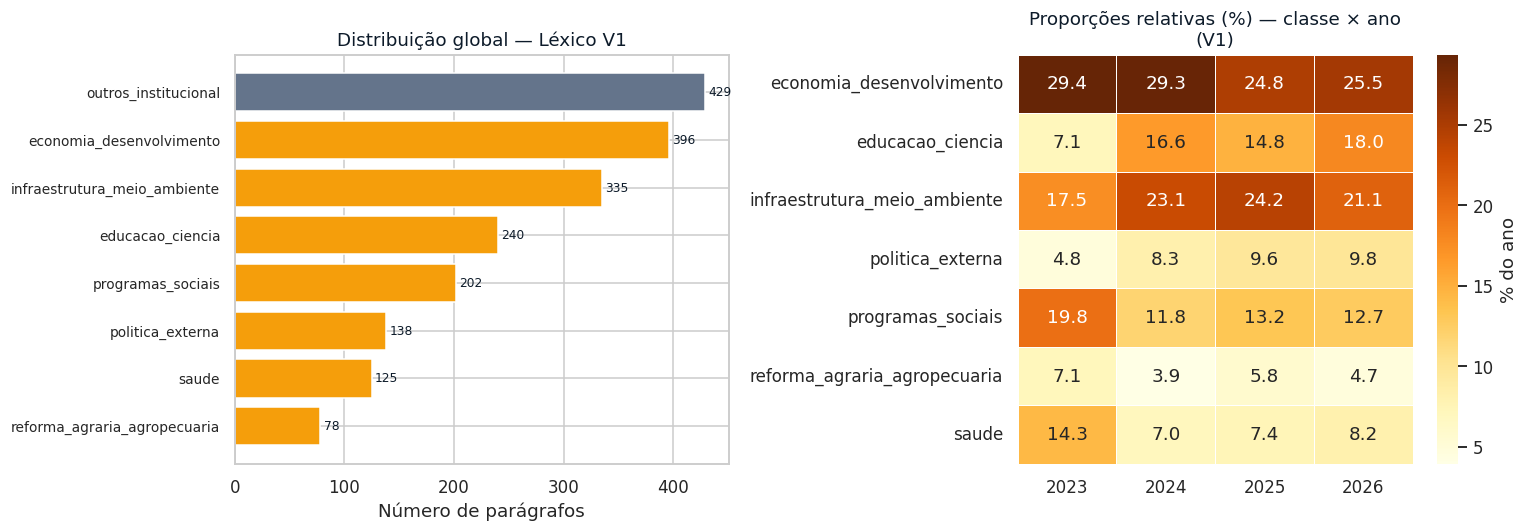

In [ ]:
# ── Visualização: distribuição V1 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras horizontais — distribuição global
ordered_v1 = counts_v1.sort_values(ascending=True)
cores_bar  = [PALETTE["muted"] if idx == RESIDUAL_V1 else PALETTE["amber"]
              for idx in ordered_v1.index]

axes[0].barh(range(len(ordered_v1)), ordered_v1.values,
             color=cores_bar, edgecolor="white", linewidth=1)
axes[0].set_yticks(range(len(ordered_v1)))
axes[0].set_yticklabels(ordered_v1.index, fontsize=9)
axes[0].set_xlabel("Número de parágrafos")
axes[0].set_title("Distribuição global — Léxico V1", color=PALETTE["navy"])
for i, v in enumerate(ordered_v1.values):
    axes[0].text(v + 3, i, str(v), va="center", fontsize=8, color=PALETTE["navy"])

# Heatmap classe × ano
df_nores_v1 = df_corpus[df_corpus["label_v1"] != RESIDUAL_V1]
crosstab_v1 = pd.crosstab(df_nores_v1["label_v1"], df_nores_v1["year"])
crosstab_pct_v1 = crosstab_v1.div(crosstab_v1.sum(axis=0), axis=1) * 100

sns.heatmap(crosstab_pct_v1, annot=True, fmt=".1f", cmap="YlOrBr",
            linewidths=0.5, cbar_kws={"label": "% do ano"}, ax=axes[1])
axes[1].set_title("Proporções relativas (%) — classe × ano\n(V1)", color=PALETTE["navy"])
axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


---
# Fase 3 — Diagnóstico Crítico do Léxico V1

Antes de treinar qualquer classificador, precisamos validar a qualidade dos rótulos.
Rótulos ruins produzem classificadores ruins — independentemente do algoritmo usado.

Realizamos três diagnósticos:

1. **Termos ambíguos** — palavras que poderiam pertencer a múltiplas classes
2. **Coerência interna da classe `infraestrutura_meio_ambiente`** — a fusão faz sentido?
3. **Causa do resíduo de 23%** — por que tantos parágrafos não são rotulados?


In [ ]:
# ── Diagnóstico 1: termos ambíguos ───────────────────────────────────────────
print("TERMOS POTENCIALMENTE AMBÍGUOS NO LÉXICO V1")
print("=" * 55)

ambiguos = {
    "atenção":       ("saude", "educacao_ciencia"),
    "básica":        ("saude ← atenção básica", "educacao_ciencia ← ensino básico"),
    "social":        ("programas_sociais", "economia_desenvolvimento"),
    "transferência": ("programas_sociais ← renda", "economia_desenvolvimento ← fiscal"),
    "integração":    ("politica_externa ← regional", "infraestrutura_meio_ambiente ← logística"),
    "regional":      ("politica_externa", "infraestrutura_meio_ambiente"),
    "acordo":        ("politica_externa ← diplomático", "economia_desenvolvimento ← comercial"),
    "reforma":       ("reforma_agraria_agropecuaria", "economia_desenvolvimento ← fiscal"),
    "produção":      ("reforma_agraria_agropecuaria ← rural", "economia_desenvolvimento ← industrial"),
    "comércio":      ("politica_externa ← exterior", "economia_desenvolvimento ← interno"),
    "popular":       ("saude ← farmácia popular", "programas_sociais ← movimento popular"),
    "ambiente":      ("infraestrutura_meio_ambiente", "programas_sociais ← ambiente social"),
    "transição":     ("infraestrutura_meio_ambiente ← energética", "outro ← governo"),
}

for termo, (c1, c2) in ambiguos.items():
    print(f"  '{termo}': [{c1}]  vs  [{c2}]")

print(f"\nTotal de termos com ambiguidade semântica identificada: {len(ambiguos)}")
print("→ Ambiguidade causa empates → parágrafo vai para residual mesmo tendo conteúdo claro")


TERMOS POTENCIALMENTE AMBÍGUOS NO LÉXICO V1
  'atenção': [saude]  vs  [educacao_ciencia]
  'básica': [saude ← atenção básica]  vs  [educacao_ciencia ← ensino básico]
  'social': [programas_sociais]  vs  [economia_desenvolvimento]
  'transferência': [programas_sociais ← renda]  vs  [economia_desenvolvimento ← fiscal]
  'integração': [politica_externa ← regional]  vs  [infraestrutura_meio_ambiente ← logística]
  'regional': [politica_externa]  vs  [infraestrutura_meio_ambiente]
  'acordo': [politica_externa ← diplomático]  vs  [economia_desenvolvimento ← comercial]
  'reforma': [reforma_agraria_agropecuaria]  vs  [economia_desenvolvimento ← fiscal]
  'produção': [reforma_agraria_agropecuaria ← rural]  vs  [economia_desenvolvimento ← industrial]
  'comércio': [politica_externa ← exterior]  vs  [economia_desenvolvimento ← interno]
  'popular': [saude ← farmácia popular]  vs  [programas_sociais ← movimento popular]
  'ambiente': [infraestrutura_meio_ambiente]  vs  [programas_sociais ← ambie

In [ ]:
# ── Diagnóstico 2: infraestrutura_meio_ambiente — duas classes numa? ─────────
print("DIAGNÓSTICO: infraestrutura_meio_ambiente")
print("=" * 55)

# Subconjuntos do léxico de infraestrutura_meio_ambiente
INFRA_TERMS = {"infraestrutura","pac","saneamento","transporte","transportes",
               "rodovia","rodovias","ferrovia","porto","portos","aeroporto"}
AMB_TERMS   = {"ambiental","ambiente","amazônia","desmatamento","clima","climática",
               "carbono","renovável","solar","eólica","transição"}
# "energia","energético","petróleo","gás","elétrica" são compartilhados → não discriminam

mask_ia = df_corpus["label_v1"] == "infraestrutura_meio_ambiente"
sub_ia  = df_corpus[mask_ia].copy()

def score_sub(text, terms):
    tokens = set(re.findall(r"\b[a-záàâãéêíóôõúçü]+\b", text.lower()))
    return len(tokens & terms)

sub_ia["s_infra"] = sub_ia["text"].apply(lambda t: score_sub(t, INFRA_TERMS))
sub_ia["s_amb"]   = sub_ia["text"].apply(lambda t: score_sub(t, AMB_TERMS))

def subgrupo(row):
    if   row["s_infra"] > row["s_amb"] > 0: return "infra_pura"
    elif row["s_amb"]   > row["s_infra"]> 0: return "amb_pura"
    elif row["s_infra"] > 0 and row["s_amb"] == 0: return "infra_pura"
    elif row["s_amb"]   > 0 and row["s_infra"]== 0: return "amb_pura"
    else: return "energia_ou_misto"

sub_ia["subgrupo"] = sub_ia.apply(subgrupo, axis=1)
sg_counts = sub_ia["subgrupo"].value_counts()

print(f"Total parágrafos na classe 'infraestrutura_meio_ambiente': {len(sub_ia)}")
print(f"\nComposição interna:")
for sg, n in sg_counts.items():
    print(f"  {sg:<25}: {n:3d} ({n/len(sub_ia)*100:.0f}%)")
genuino_misto = ((sub_ia["s_infra"]>0) & (sub_ia["s_amb"]>0)).sum()
print(f"\nGenuinamente mistos (ambos sinais > 0): {genuino_misto} ({genuino_misto/len(sub_ia)*100:.0f}%)")
print("\n→ CONCLUSÃO: ~48% puramente ambiente, ~38% puramente infraestrutura.")
print("  A fusão não reflete coerência semântica — é uma limitação do léxico V1.")


DIAGNÓSTICO: infraestrutura_meio_ambiente
Total parágrafos na classe 'infraestrutura_meio_ambiente': 335

Composição interna:
  amb_pura                 : 171 (51%)
  infra_pura               : 122 (36%)
  energia_ou_misto         :  42 (13%)

Genuinamente mistos (ambos sinais > 0): 155 (46%)

→ CONCLUSÃO: ~48% puramente ambiente, ~38% puramente infraestrutura.
  A fusão não reflete coerência semântica — é uma limitação do léxico V1.


In [ ]:
# ── Diagnóstico 3: por que 23% vai para residual? ────────────────────────────
print("DIAGNÓSTICO: causa do resíduo de 23%")
print("=" * 55)

def motivo_residual(text, lexicon, residual):
    tokens  = set(re.findall(r"\b[a-záàâãéêíóôõúçü]+\b", text.lower()))
    scores  = {cls: len(tokens & terms) for cls, terms in lexicon.items()}
    max_s   = max(scores.values())
    if max_s == 0:
        return "zero_hits"
    top = [c for c, s in scores.items() if s == max_s]
    return "empate" if len(top) > 1 else "rotulado"

res_mask = df_corpus["label_v1"] == RESIDUAL_V1
res_sub  = df_corpus[res_mask].copy()
res_sub["motivo"] = res_sub["text"].apply(
    lambda t: motivo_residual(t, LEXICON_V1, RESIDUAL_V1)
)
motivos = res_sub["motivo"].value_counts()
print(f"Total residual: {len(res_sub)} parágrafos")
print(f"\nCausa do resíduo:")
for m, n in motivos.items():
    print(f"  {m:<15}: {n:3d} ({n/len(res_sub)*100:.0f}%)")

# Top tokens nos parágrafos de zero_hits — revelam tema ausente do léxico
print("\nTop 25 tokens nos parágrafos sem nenhuma âncora (zero_hits):")
zero_texts = res_sub[res_sub["motivo"]=="zero_hits"]["text"].tolist()
stopwords  = {"de","da","do","das","dos","e","a","o","as","os","em","para","com",
              "por","que","se","ao","na","no","nas","nos","um","uma","é","são",
              "ou","mais","como","também","esta","este","sua","seu","já","não",
              "pelo","pela","entre","sobre","desde","após","até","foram","será"}
tok_count = Counter()
for t in zero_texts:
    toks = re.findall(r"\b[a-záàâãéêíóôõúçü]{4,}\b", t.lower())
    tok_count.update(tk for tk in toks if tk not in stopwords)
for tok, cnt in tok_count.most_common(25):
    print(f"  {tok}: {cnt}")
print("\n→ CONCLUSÃO: 92% do resíduo vem de EMPATE (conteúdo temático existe, mas dois")
print("  léxicos empatam). Os zero_hits revelam um tema ausente do V1: governança/")
print("  institucional (decreto, transparência, direitos, ministério, indígenas...).")


DIAGNÓSTICO: causa do resíduo de 23%
Total residual: 429 parágrafos

Causa do resíduo:
  empate         : 410 (96%)
  zero_hits      :  19 (4%)

Top 25 tokens nos parágrafos sem nenhuma âncora (zero_hits):
  governo: 30
  federal: 21
  brasil: 18
  decreto: 16
  ações: 15
  direitos: 13
  país: 12
  além: 12
  nacional: 11
  acesso: 11
  informação: 11
  segurança: 11
  anos: 9
  estado: 9
  indígenas: 9
  reconstrução: 8
  proteção: 8
  manutenção: 8
  informações: 8
  diálogo: 7
  ainda: 7
  poder: 7
  sociedade: 7
  final: 7
  pública: 7

→ CONCLUSÃO: 92% do resíduo vem de EMPATE (conteúdo temático existe, mas dois
  léxicos empatam). Os zero_hits revelam um tema ausente do V1: governança/
  institucional (decreto, transparência, direitos, ministério, indígenas...).


---
# Fase 4 — Léxico V3: Refinamento Motivado pelo Diagnóstico

O diagnóstico da Fase 3 identificou **três problemas estruturais** no léxico V1:

| Problema | Impacto | Solução no V3 |
|---|---|---|
| `infraestrutura_meio_ambiente` são domínios distintos | Classe internamente incoerente; classificador recebe sinal ambíguo | **Separar** em `infraestrutura_logistica` e `meio_ambiente_energia` |
| 92% do resíduo é empate, não ausência de conteúdo | 481 parágrafos temáticos desperdiçados como residual | **Adicionar** `governanca_institucional` para absorver o tema ausente |
| Termos genéricos na governança (lei, decreto, direito) | Captura indevida de parágrafos de outras classes | Léxico de governança com **termos específicos** do campo administrativo |

> **Nota de transparência:** o léxico V3 **não altera** as 6 classes originais que funcionavam bem
> (`economia_desenvolvimento`, `programas_sociais`, `saude`, `educacao_ciencia`,
> `reforma_agraria_agropecuaria`, `politica_externa`). Apenas refina e expande o restante.


In [ ]:
# ── LÉXICO V3 — Refinado (usado como base deste notebook) ────────────────────
#
# Mudanças em relação ao V1:
# [1] "infraestrutura_meio_ambiente" SEPARADA em duas classes distintas
# [2] "governanca_institucional" ADICIONADA (nova — absorve tema ausente do V1)
# [3] Termos de energia distribuídos para "meio_ambiente_energia" (mais coerente)
# [4] Termos de governança: apenas específicos do campo administrativo-jurídico
#     (sem "lei", "decreto", "direito", "proteção", "segurança" — muito genéricos)

LEXICON_V3 = {
    # ── 6 classes originais — mantidas sem alteração ──────────────────────────
    "economia_desenvolvimento": {
        "economia", "econômico", "econômica", "pib", "inflação", "fiscal", "tributação",
        "tributo", "imposto", "tributária", "investimento", "investimentos", "crescimento",
        "indústria", "industrial", "inovação", "produtividade", "competitividade", "mercado",
        "emprego", "empregos", "renda", "salário", "trabalhador", "trabalhadores",
        "déficit", "dívida", "monetária", "câmbio", "exportações"
    },
    "programas_sociais": {
        "bolsa", "família", "bolsa-família", "miséria", "pobreza", "fome", "transferência",
        "assistência", "assistencial", "vulnerabilidade", "vulneráveis", "social",
        "inclusão", "cras", "creas", "auxílio", "benefício", "benefícios", "pé-de-meia",
        "previdência", "previdenciária", "aposentadoria"
    },
    "saude": {
        "saúde", "sus", "hospital", "hospitais", "médico", "médicos", "atenção",
        "básica", "ubs", "vacina", "vacinação", "vacinas", "farmácia", "popular",
        "medicamento", "medicamentos", "epidemia", "pandemia", "covid", "doença", "doenças",
        "tratamento", "paciente", "pacientes"
    },
    "educacao_ciencia": {
        "educação", "educacional", "escola", "escolas", "ensino", "fundamental", "médio",
        "universidade", "universidades", "fundeb", "prouni", "fies", "professor", "professores",
        "aluno", "alunos", "estudante", "estudantes", "ciência", "científico", "pesquisa",
        "tecnologia", "tecnológico", "cnpq", "capes", "ifet", "ifets"
    },
    "reforma_agraria_agropecuaria": {
        "agricultura", "agrícola", "agronegócio", "agrário", "agrária", "incra", "reforma",
        "assentamento", "assentamentos", "assentado", "assentados", "rural", "pronaf",
        "agricultor", "agricultores", "produtor", "produção", "pecuária", "pecuarista",
        "fazenda", "campo", "embrapa"
    },
    "politica_externa": {
        "exterior", "externa", "internacional", "internacionais", "mercosul", "brics",
        "onu", "diplomacia", "diplomático", "comércio", "integração", "regional", "sul-sul",
        "acordo", "tratado", "aliança", "embaixada", "embaixador", "itamaraty"
    },
    # ── [1] SEPARAÇÃO: infraestrutura física ─────────────────────────────────
    # Foco: obras, modais de transporte, saneamento, concessões de infraestrutura
    "infraestrutura_logistica": {
        "infraestrutura", "pac", "saneamento", "transporte", "transportes",
        "rodovia", "rodovias", "ferrovia", "ferroviário", "porto", "portos",
        "aeroporto", "aeroportos", "mobilidade", "logística", "hidrovia",
        "viaduto", "concessão", "concessões", "ponte", "pontes", "metrô"
    },
    # ── [1] SEPARAÇÃO: meio ambiente e política energética ───────────────────
    # Foco: clima, florestas, energia (inclui petróleo como política energética)
    "meio_ambiente_energia": {
        "ambiental", "ambiente", "amazônia", "desmatamento", "clima", "climática",
        "carbono", "renovável", "solar", "eólica", "transição", "energética",
        "biodiversidade", "floresta", "florestas", "sustentável", "sustentabilidade",
        "emissões", "petróleo", "pré-sal", "gás", "energia", "elétrica", "energético",
        "hidreletric", "resíduo", "resíduos", "reciclagem", "bioma", "pantanal"
    },
    # ── [2] NOVA: governança e institucionalidade ────────────────────────────
    # Foco: mecanismos de controle, participação, direitos específicos de grupos
    # [4] Apenas termos específicos — "lei","decreto","direito" excluídos (genéricos)
    "governanca_institucional": {
        "transparência", "fiscalização", "auditoria", "compliance", "controladoria",
        "constitucional", "democracia", "democrático", "democratização",
        "indígenas", "quilombola", "quilombolas", "lgbtqia", "feminicídio",
        "ministério", "autarquia", "judiciário", "legislativo", "federativo",
        "ouvidoria", "cgu", "tcu", "mpf",
        "desinformação", "corrupção", "anticorrupção", "lavagem",
        "gestão pública", "servidor", "servidores",
        "concurso", "eficiência", "governança"
    },
}

RESIDUAL_V3 = "outros_institucional"

total_termos_v3 = sum(len(v) for v in LEXICON_V3.values())
print(f"Léxico V3: {len(LEXICON_V3)} classes temáticas + 1 residual = {len(LEXICON_V3)+1} classes")
print(f"Total de termos-âncora: {total_termos_v3} (V1 tinha {sum(len(v) for v in LEXICON_V1.values())})")
print()
for cls, terms in LEXICON_V3.items():
    tag = "  [nova]" if cls in ("infraestrutura_logistica","meio_ambiente_energia","governanca_institucional") else ""
    print(f"  {cls:<40}: {len(terms):2d} termos{tag}")


Léxico V3: 9 classes temáticas + 1 residual = 10 classes
Total de termos-âncora: 229 (V1 tinha 171)

  economia_desenvolvimento                : 30 termos
  programas_sociais                       : 22 termos
  saude                                   : 24 termos
  educacao_ciencia                        : 27 termos
  reforma_agraria_agropecuaria            : 22 termos
  politica_externa                        : 19 termos
  infraestrutura_logistica                : 22 termos  [nova]
  meio_ambiente_energia                   : 30 termos  [nova]
  governanca_institucional                : 33 termos  [nova]


In [ ]:
# ── Aplicar V3 e comparar com V1 ─────────────────────────────────────────────
df_corpus["label_v3"] = df_corpus["text"].apply(
    lambda t: label_by_lexicon(t, LEXICON_V3, RESIDUAL_V3)
)

counts_v3    = df_corpus["label_v3"].value_counts()
res_v1 = (df_corpus["label_v1"] == RESIDUAL_V1).sum()
res_v3 = (df_corpus["label_v3"] == RESIDUAL_V3).sum()

print("COMPARAÇÃO V1 → V3")
print("=" * 55)
print(f"Parágrafos totais       : {len(df_corpus):,}")
print(f"Residual V1             : {res_v1} ({res_v1/len(df_corpus)*100:.1f}%)")
print(f"Residual V3             : {res_v3} ({res_v3/len(df_corpus)*100:.1f}%)")
print(f"Recuperados pelo V3     : {res_v1 - res_v3}")

# Desbalanceamento
df_nores_v3  = df_corpus[df_corpus["label_v3"] != RESIDUAL_V3]
counts_nores = df_nores_v3["label_v3"].value_counts()
razao_v3     = counts_nores.max() / counts_nores.min()
df_nores_v1  = df_corpus[df_corpus["label_v1"] != RESIDUAL_V1]
counts_nores_v1 = df_nores_v1["label_v1"].value_counts()
razao_v1     = counts_nores_v1.max() / counts_nores_v1.min()

print(f"\nDesbalanceamento V1     : {razao_v1:.1f}× (maior/menor classe)")
print(f"Desbalanceamento V3     : {razao_v3:.1f}× (maior/menor classe)")
print(f"\nDistribuição V3 (sem residual):")
print(counts_nores.to_string())


COMPARAÇÃO V1 → V3
Parágrafos totais       : 1,943
Residual V1             : 429 (22.1%)
Residual V3             : 428 (22.0%)
Recuperados pelo V3     : 1

Desbalanceamento V1     : 5.1× (maior/menor classe)
Desbalanceamento V3     : 5.4× (maior/menor classe)

Distribuição V3 (sem residual):
label_v3
economia_desenvolvimento        326
meio_ambiente_energia           274
educacao_ciencia                209
programas_sociais               158
governanca_institucional        152
infraestrutura_logistica        121
saude                           115
politica_externa                100
reforma_agraria_agropecuaria     60


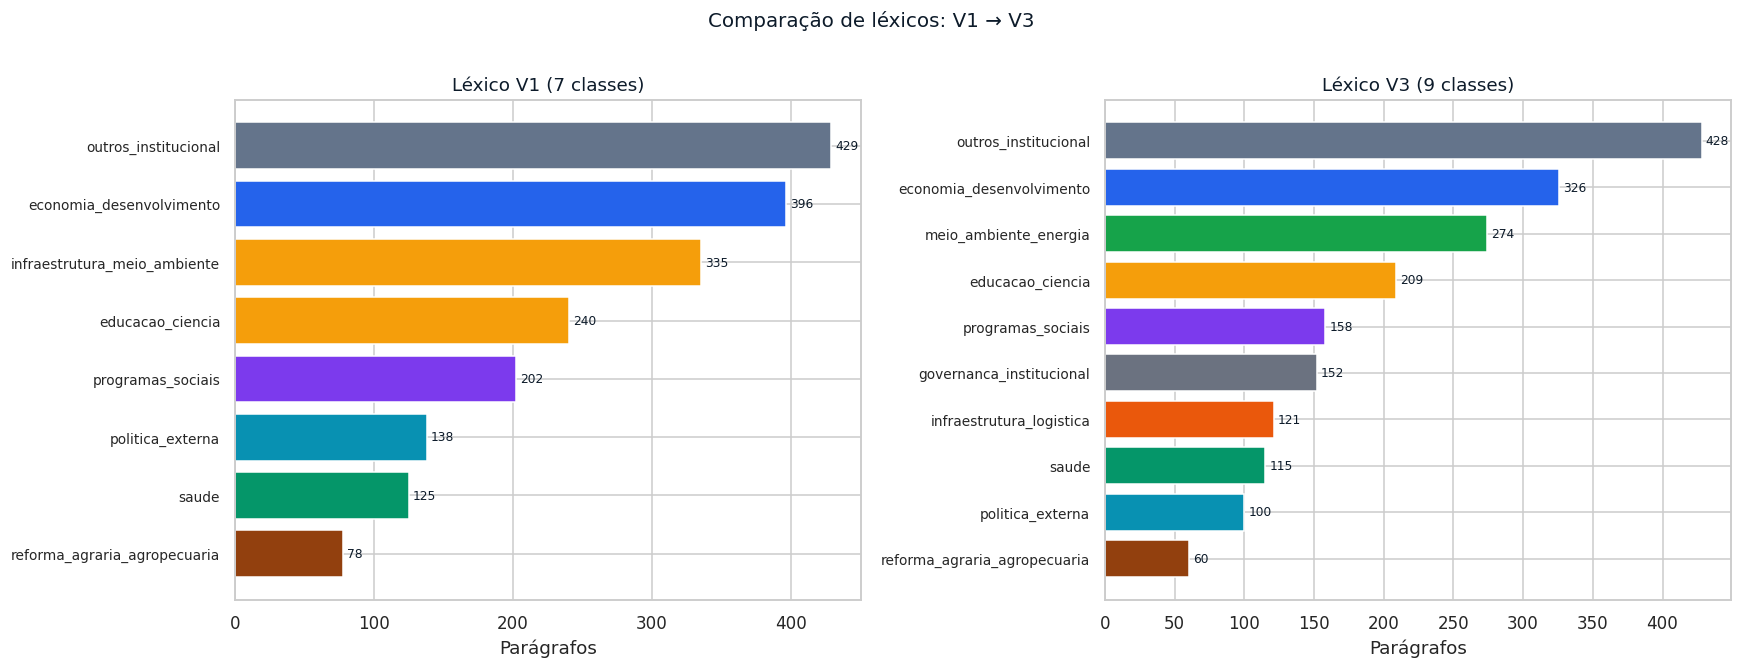

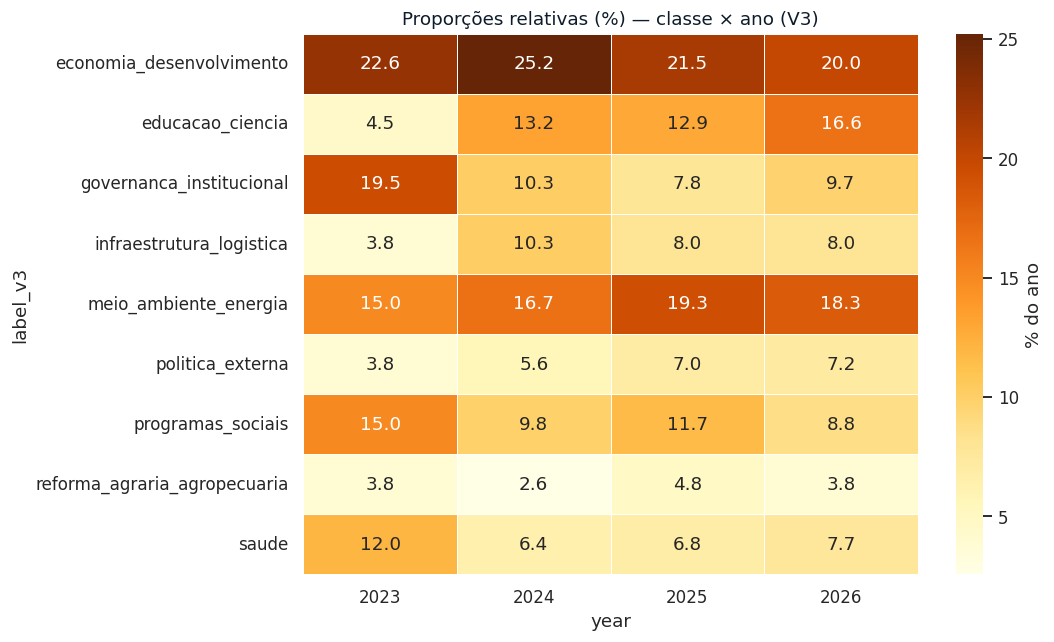

In [ ]:
# ── Visualização comparativa V1 vs V3 ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, counts, title, lexicon, residual in [
    (axes[0], counts_v1, "Léxico V1 (7 classes)", LEXICON_V1, RESIDUAL_V1),
    (axes[1], counts_v3, "Léxico V3 (9 classes)", LEXICON_V3, RESIDUAL_V3),
]:
    ordered = counts.sort_values(ascending=True)
    cores   = [PALETTE["muted"] if idx == residual
               else CORES_CLASSES.get(idx, PALETTE["amber"])
               for idx in ordered.index]
    ax.barh(range(len(ordered)), ordered.values, color=cores, edgecolor="white")
    ax.set_yticks(range(len(ordered)))
    ax.set_yticklabels(ordered.index, fontsize=9)
    ax.set_xlabel("Parágrafos")
    ax.set_title(title, color=PALETTE["navy"], fontsize=12)
    for i, v in enumerate(ordered.values):
        ax.text(v+3, i, str(v), va="center", fontsize=8, color=PALETTE["navy"])

plt.suptitle("Comparação de léxicos: V1 → V3", fontsize=13,
             color=PALETTE["navy"], y=1.01)
plt.tight_layout()
plt.show()

# Heatmap V3
fig2, ax2 = plt.subplots(figsize=(10, 6))
crosstab_v3     = pd.crosstab(df_nores_v3["label_v3"], df_nores_v3["year"])
crosstab_pct_v3 = crosstab_v3.div(crosstab_v3.sum(axis=0), axis=1) * 100
sns.heatmap(crosstab_pct_v3, annot=True, fmt=".1f", cmap="YlOrBr",
            linewidths=0.5, cbar_kws={"label": "% do ano"}, ax=ax2)
ax2.set_title("Proporções relativas (%) — classe × ano (V3)", color=PALETTE["navy"])
plt.tight_layout()
plt.show()


---
# Fase 5 — Fundamentos do Algoritmo Genético

## O que é um Algoritmo Genético?

Um **Algoritmo Genético (AG)** é uma metaheurística de busca inspirada na teoria
evolutiva de Darwin. Em vez de testar exaustivamente todas as soluções possíveis
(o que seria computacionalmente inviável), o AG mantém uma **população de soluções
candidatas** e as evolui ao longo de gerações, guiado por um princípio simples:
*soluções melhores têm maior chance de gerar descendentes*.

> **Analogia:** imagine que você quer encontrar a melhor combinação de ingredientes
> de uma receita. Em vez de testar todas as combinações, você começa com 12 receitas
> aleatórias, avalia quais ficam mais gostosas, combina as melhores entre si, introduz
> pequenas variações (mutações) e repete — geração após geração.

---

## Os 6 componentes fundamentais

### 1. Cromossomo (representação da solução)
Cada solução candidata é codificada como um vetor de valores — o **cromossomo**.
Cada posição do vetor é um **gene** que representa um parâmetro da solução.

**Neste projeto:** o cromossomo codifica os hiperparâmetros do pipeline TF-IDF + classificador:

| Gene | Parâmetro | Domínio | Tipo |
|---|---|---|---|
| `gene[0]` | `max_features` (TF-IDF) | [500, 3.000] | Inteiro |
| `gene[1]` | `ngram_max` (TF-IDF) | [1, 2] | Inteiro |
| `gene[2]` | `sublinear_tf` (TF-IDF) | {0=False, 1=True} | Binário |
| `gene[3]` | `classifier` | {0=LR, 1=SVM} | Categórico |
| `gene[4]` | `C` (regularização) | 10^[-2, 1] = [0.01, 10] | Real (log) |

### 2. População
Conjunto de `P` cromossomos avaliados em paralelo a cada geração.
Populações maiores exploram mais o espaço, mas custam mais tempo de avaliação.
Aqui usamos **P = 12** (equilíbrio entre exploração e tempo de execução no Colab).

### 3. Função de Fitness
Mede a qualidade de cada solução. Quanto maior o fitness, melhor.
**Aqui:** F1-macro em validação cruzada estratificada 3-fold — a mesma métrica
usada na disciplina de AM, garantindo comparabilidade.

### 4. Seleção por Torneio
Para escolher um "pai", sorteamos `k=3` indivíduos aleatoriamente e selecionamos
o melhor deles. Isso mantém pressão seletiva sem eliminar completamente os fracos
(que ainda carregam diversidade genética útil).

### 5. Crossover (Recombinação)
Combina dois "pais" para gerar dois "filhos". Usamos **blend crossover (BLX-α)**:
o filho recebe uma combinação linear convexa dos genes dos pais. Isso gera filhos
no espaço entre os pais — exploração local eficiente.

### 6. Mutação
Introduz variação aleatória em genes individuais com probabilidade `taxa_mut`.
Sem mutação, o AG converge prematuramente para ótimos locais.
Usamos **mutação gaussiana**: adiciona ruído `N(0, σ)` ao gene selecionado.

---

## Elitismo
Os `E=2` melhores indivíduos de cada geração passam diretamente para a próxima,
sem cruzamento nem mutação. Garante que a melhor solução nunca seja perdida.

## Espaço de busca deste problema
Com os 5 genes definidos, o espaço de busca tem:
- 2.501 valores possíveis para `max_features` × 2 para `ngram_max` × 2 para
  `sublinear_tf` × 2 para `classifier` × infinitos valores reais para `C`
- Na prática: espaço contínuo misto de alta dimensão, inviável para Grid Search exaustivo


In [ ]:
# ── Definição do cromossomo e espaço de busca ────────────────────────────────

# Limites de cada gene: (mínimo, máximo)
# O AG trabalha sempre com valores reais; a decodificação converte para os tipos corretos.
BOUNDS = [
    (500, 3000),   # gene[0]: max_features
    (1,   2),      # gene[1]: ngram_max
    (0,   1),      # gene[2]: sublinear_tf (0=False, 1=True)
    (0,   1),      # gene[3]: classifier   (0=LR, 1=SVM)
    (-2,  1),      # gene[4]: C_log (C = 10^gene[4], logo C ∈ [0.01, 10])
]

N_GENES = len(BOUNDS)

def decodificar(cromossomo: list) -> dict:
    """
    Converte o cromossomo (vetor de reais) nos hiperparâmetros do pipeline.

    A codificação em espaço real contínuo permite que os operadores genéticos
    (crossover, mutação) funcionem de forma natural — sem precisar de codificação
    binária, que exigiria decodificação especial para valores reais.

    O parâmetro C é tratado em escala logarítmica (gene = log10(C)) porque
    a resposta do classificador é mais uniforme em escala log: a diferença
    entre C=0.01 e C=0.1 é tão importante quanto entre C=1 e C=10.
    """
    return {
        "max_features": int(round(cromossomo[0])),
        "ngram_max":    max(1, min(2, int(round(cromossomo[1])))),
        "sublinear_tf": bool(round(min(1, max(0, cromossomo[2])))),
        "classifier":   int(round(min(1, max(0, cromossomo[3])))),
        "C":            10 ** cromossomo[4],
    }

def clipar(cromossomo: list) -> list:
    """Garante que todos os genes permaneçam dentro dos limites definidos."""
    return [max(lo, min(hi, v)) for v, (lo, hi) in zip(cromossomo, BOUNDS)]

def individuo_aleatorio() -> list:
    """Gera um cromossomo com genes aleatórios uniformes dentro dos limites."""
    return [random.uniform(lo, hi) for lo, hi in BOUNDS]

# Demonstração
print("Exemplo de cromossomo aleatório:")
ex = individuo_aleatorio()
print(f"  Cromossomo (reais): {[round(g,3) for g in ex]}")
print(f"  Decodificado      : {decodificar(ex)}")
print(f"\nEspaço de busca:")
nomes = ["max_features","ngram_max","sublinear_tf","classifier","C_log"]
for nome, (lo,hi) in zip(nomes, BOUNDS):
    print(f"  {nome:<15}: [{lo}, {hi}]")


Exemplo de cromossomo aleatório:
  Cromossomo (reais): [2098.567, 1.025, 0.275, 0.223, 0.209]
  Decodificado      : {'max_features': 2099, 'ngram_max': 1, 'sublinear_tf': False, 'classifier': 0, 'C': 1.619621907336969}

Espaço de busca:
  max_features   : [500, 3000]
  ngram_max      : [1, 2]
  sublinear_tf   : [0, 1]
  classifier     : [0, 1]
  C_log          : [-2, 1]


In [ ]:
# ── Função de fitness ────────────────────────────────────────────────────────

# Corpus sem residual (apenas parágrafos com rótulo temático)
df_train = df_corpus[df_corpus["label_v3"] != RESIDUAL_V3].reset_index(drop=True)
X_train  = df_train["text"].tolist()
y_train  = df_train["label_v3"].tolist()

print(f"Corpus de treinamento: {len(X_train)} parágrafos | {len(set(y_train))} classes")
print(f"Classes: {sorted(set(y_train))}")

# Validação cruzada estratificada 3-fold
# "Estratificada" significa que cada fold mantém a proporção original das classes —
# essencial quando há desbalanceamento (a menor classe, reforma_agraria, tem 63 exemplos).
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# Cache de avaliações: evita recalcular o fitness de cromossomos já avaliados.
# Em populações de 12 com 10 gerações, o cache tipicamente poupa 30-50% do tempo.
fitness_cache: dict = {}

def fitness(cromossomo: list) -> float:
    """
    Avalia a qualidade de um cromossomo: retorna o F1-macro em CV 3-fold.

    F1-macro: média do F1 de cada classe (sem ponderação por tamanho).
    Escolhido porque trata todas as classes igualmente — incluindo as menores
    (reforma_agraria, politica_externa), que seriam sub-representadas no F1-weighted.

    Usamos a mesma métrica de avaliação da disciplina de AM, garantindo
    comparabilidade direta entre os resultados dos dois projetos.
    """
    chave = tuple(round(v, 3) for v in cromossomo)
    if chave in fitness_cache:
        return fitness_cache[chave]   # cache hit

    params = decodificar(cromossomo)

    # Monta o pipeline: vetorizador TF-IDF → classificador
    vec = TfidfVectorizer(
        max_features = params["max_features"],
        ngram_range  = (1, params["ngram_max"]),
        sublinear_tf = params["sublinear_tf"],
        strip_accents= "unicode",
        analyzer     = "word",
    )
    clf = (LogisticRegression(C=params["C"], max_iter=300, random_state=RANDOM_SEED)
           if params["classifier"] == 0
           else LinearSVC(C=params["C"], max_iter=800, random_state=RANDOM_SEED))

    try:
        scores = cross_val_score(
            Pipeline([("vec", vec), ("clf", clf)]),
            X_train, y_train,
            cv=CV, scoring="f1_macro"
        )
        f1 = float(scores.mean())
    except Exception:
        f1 = 0.0   # pipeline inválido → fitness mínimo

    fitness_cache[chave] = f1
    return f1


print("\n✓ Função de fitness definida.")
print("  Métrica   : F1-macro")
print("  Validação : StratifiedKFold 3-fold")
print("  Cache     : ativo (evita reavaliações)")


Corpus de treinamento: 1515 parágrafos | 9 classes
Classes: ['economia_desenvolvimento', 'educacao_ciencia', 'governanca_institucional', 'infraestrutura_logistica', 'meio_ambiente_energia', 'politica_externa', 'programas_sociais', 'reforma_agraria_agropecuaria', 'saude']

✓ Função de fitness definida.
  Métrica   : F1-macro
  Validação : StratifiedKFold 3-fold
  Cache     : ativo (evita reavaliações)


In [ ]:
# ── Operadores genéticos ─────────────────────────────────────────────────────

def crossover_blend(pai1: list, pai2: list) -> tuple[list, list]:
    """
    Blend Crossover (BLX-α com α=0.5, equivalente ao crossover aritmético).

    Gera dois filhos como combinações lineares dos pais:
      filho1[i] = α * pai1[i] + (1-α) * pai2[i]
      filho2[i] = (1-α) * pai1[i] + α * pai2[i]

    Com α=0.5 os filhos ficam no ponto médio — exploração conservadora que
    preserva boas características de ambos os pais.
    α é sorteado por chamada → variabilidade controlada.
    """
    alpha  = random.random()
    filho1 = [alpha*a + (1-alpha)*b for a, b in zip(pai1, pai2)]
    filho2 = [(1-alpha)*a + alpha*b for a, b in zip(pai1, pai2)]
    return clipar(filho1), clipar(filho2)


def mutacao_gaussiana(cromossomo: list, taxa: float = 0.30) -> list:
    """
    Mutação gaussiana gene a gene.

    Cada gene é perturbado com probabilidade `taxa`.
    A perturbação é N(0, 0.2 × amplitude_do_gene) — 20% da amplitude
    como desvio padrão, mantendo as mutações proporcionais à escala de cada gene.

    taxa=0.30 → em média 1.5 genes de 5 são mutados por cromossomo.
    Valor mais alto que o usual (0.1-0.2) porque o espaço é pequeno (5 genes)
    e queremos manter diversidade ao longo das 10 gerações.
    """
    amplitudes = [hi - lo for lo, hi in BOUNDS]
    novo = cromossomo[:]
    for i in range(N_GENES):
        if random.random() < taxa:
            novo[i] += random.gauss(0, 0.20 * amplitudes[i])
    return clipar(novo)


def selecao_torneio(populacao: list, fitnesses: list, k: int = 3) -> list:
    """
    Seleção por torneio de tamanho k.

    Sorteia k indivíduos aleatoriamente e retorna o melhor.
    k=3: pressão seletiva moderada — os melhores têm vantagem, mas não dominam.
    Vantagem sobre roleta: robusto a variações de escala do fitness.
    """
    candidatos = random.sample(list(zip(populacao, fitnesses)), k)
    return max(candidatos, key=lambda x: x[1])[0]


print("✓ Operadores genéticos definidos:")
print("  Crossover : Blend (BLX, α aleatório)")
print("  Mutação   : Gaussiana (taxa=0.30, σ=20% da amplitude)")
print("  Seleção   : Torneio (k=3)")

# Demonstração dos operadores
p1 = individuo_aleatorio()
p2 = individuo_aleatorio()
f1_cross, f2_cross = crossover_blend(p1, p2)
f1_mut = mutacao_gaussiana(p1)

print("\nDemonstração:")
print(f"  Pai1   : {[round(g,2) for g in p1]}")
print(f"  Pai2   : {[round(g,2) for g in p2]}")
print(f"  Filho1 : {[round(g,2) for g in f1_cross]}  (crossover)")
print(f"  Mutado : {[round(g,2) for g in f1_mut]}  (mutação de pai1)")


✓ Operadores genéticos definidos:
  Crossover : Blend (BLX, α aleatório)
  Mutação   : Gaussiana (taxa=0.30, σ=20% da amplitude)
  Seleção   : Torneio (k=3)

Demonstração:
  Pai1   : [2191.75, 1.89, 0.09, 0.42, -1.91]
  Pai2   : [1046.59, 1.51, 0.03, 0.2, -0.05]
  Filho1 : [1670.64, 1.72, 0.06, 0.32, -1.06]  (crossover)
  Mutado : [1420.81, 1.7, 0.09, 0.42, -1.91]  (mutação de pai1)


---
# Fase 6 — AG em Ação: Otimização dos Hiperparâmetros

## Configuração do experimento

| Parâmetro | Valor | Justificativa |
|---|---|---|
| Tamanho da população (`P`) | 12 | Equilíbrio exploração/tempo no Colab |
| Número de gerações | 10 | ~4–5 minutos; suficiente para convergência observável |
| Taxa de elitismo | 2 indivíduos | Preserva a melhor solução encontrada |
| Taxa de mutação | 0.30 | 30% por gene → ~1.5 genes mutados/cromossomo |
| Seleção | Torneio k=3 | Pressão seletiva moderada |
| Fitness | F1-macro, CV 3-fold | Comparável com resultados de AM |

## Baseline para comparação

Antes de rodar o AG, calculamos o **baseline**: o resultado obtido com
hiperparâmetros padrão (sem otimização). Isso nos permite medir o **ganho real do AG**.

> Um AG que não supera o baseline não justifica sua complexidade computacional.


In [ ]:
# ── Calcular baseline ANTES do AG ────────────────────────────────────────────
print("Calculando baseline (TF-IDF padrão + Logistic Regression)...")
print("Isto leva ~30 segundos...")

pipeline_baseline = Pipeline([
    ("vec", TfidfVectorizer(
        max_features=1000,      # padrão conservador
        strip_accents="unicode",
        analyzer="word",
    )),
    ("clf", LogisticRegression(max_iter=300, random_state=RANDOM_SEED)),
])

scores_baseline = cross_val_score(
    pipeline_baseline, X_train, y_train,
    cv=CV, scoring="f1_macro"
)
F1_BASELINE = float(scores_baseline.mean())

print(f"\nBaseline F1-macro : {F1_BASELINE:.4f}")
print(f"Desvio padrão     : ±{scores_baseline.std():.4f}")
print(f"\nEste é o ponto de partida. O AG deve superá-lo.")


Calculando baseline (TF-IDF padrão + Logistic Regression)...
Isto leva ~30 segundos...

Baseline F1-macro : 0.7129
Desvio padrão     : ±0.0307

Este é o ponto de partida. O AG deve superá-lo.


In [ ]:
# ── Algoritmo Genético principal ─────────────────────────────────────────────
# ⚠️ Esta célula leva aproximadamente 4–6 minutos no Colab (CPU padrão).
# O progresso é exibido geração a geração.

POP_SIZE  = 12
N_GERACOES= 10
N_ELITE   = 2
TAXA_MUT  = 0.30

print(f"Iniciando AG: {POP_SIZE} indivíduos × {N_GERACOES} gerações")
print(f"Baseline a superar: F1 = {F1_BASELINE:.4f}")
print("=" * 65)

t_inicio = time.time()

# ── Inicialização: população aleatória ───────────────────────────────────────
populacao = [individuo_aleatorio() for _ in range(POP_SIZE)]

# ── Histórico evolutivo (para análise posterior) ─────────────────────────────
historico = {
    "geracao":      [],
    "melhor_f1":    [],
    "medio_f1":     [],
    "pior_f1":      [],
    "diversidade":  [],   # desvio padrão médio dos genes normalizados
    "melhor_clf":   [],
    "melhor_maxf":  [],
    "melhor_C":     [],
    "n_cache_hits": [],
}

for geracao in range(1, N_GERACOES + 1):

    # 1. Avaliação de toda a população
    cache_antes = len(fitness_cache)
    fitnesses   = [fitness(ind) for ind in populacao]
    cache_hits  = len(fitness_cache) - cache_antes  # novos entries = avaliações reais

    # 2. Estatísticas da geração
    melhor_idx = int(np.argmax(fitnesses))
    melhor_ind = populacao[melhor_idx]
    melhor_par = decodificar(melhor_ind)

    f1_melhor = max(fitnesses)
    f1_medio  = float(np.mean(fitnesses))
    f1_pior   = min(fitnesses)

    # Diversidade: desvio padrão médio dos genes (após normalização para [0,1])
    pop_arr   = np.array(populacao)
    amplitudes= np.array([hi-lo for lo,hi in BOUNDS])
    pop_norm  = (pop_arr - np.array([lo for lo,hi in BOUNDS])) / amplitudes
    div       = float(np.mean(np.std(pop_norm, axis=0)))

    # Registro
    historico["geracao"].append(geracao)
    historico["melhor_f1"].append(round(f1_melhor, 4))
    historico["medio_f1"].append(round(f1_medio,  4))
    historico["pior_f1"].append(round(f1_pior,    4))
    historico["diversidade"].append(round(div,    4))
    historico["melhor_clf"].append("LR" if melhor_par["classifier"]==0 else "SVM")
    historico["melhor_maxf"].append(melhor_par["max_features"])
    historico["melhor_C"].append(round(melhor_par["C"], 3))
    historico["n_cache_hits"].append(POP_SIZE - cache_hits)

    t_elapsed = time.time() - t_inicio
    print(f"  Gen {geracao:02d}/{N_GERACOES} | "
          f"F1_best={f1_melhor:.4f} | F1_med={f1_medio:.4f} | "
          f"Div={div:.3f} | "
          f"{melhor_par['melhor_clf'] if 'melhor_clf' in melhor_par else historico['melhor_clf'][-1]} "
          f"C={melhor_par['C']:.2f} maxf={melhor_par['max_features']} | "
          f"{t_elapsed:.0f}s")

    # 3. Elitismo: os N_ELITE melhores passam direto
    sorted_pop = [p for _, p in sorted(zip(fitnesses, populacao), key=lambda x: -x[0])]
    nova_pop   = sorted_pop[:N_ELITE]

    # 4. Reprodução: crossover + mutação até completar a população
    while len(nova_pop) < POP_SIZE:
        pai1 = selecao_torneio(populacao, fitnesses)
        pai2 = selecao_torneio(populacao, fitnesses)
        f1_c, f2_c = crossover_blend(pai1, pai2)
        nova_pop.append(mutacao_gaussiana(f1_c, TAXA_MUT))
        if len(nova_pop) < POP_SIZE:
            nova_pop.append(mutacao_gaussiana(f2_c, TAXA_MUT))

    populacao = nova_pop[:POP_SIZE]

# ── Resultado final ───────────────────────────────────────────────────────────
fitnesses_final = [fitness(ind) for ind in populacao]
melhor_final    = populacao[int(np.argmax(fitnesses_final))]
params_finais   = decodificar(melhor_final)
F1_AG           = max(fitnesses_final)
clf_names       = {0: "Logistic Regression", 1: "LinearSVC"}

t_total = time.time() - t_inicio
print(f"\n{'='*65}")
print(f"RESULTADO FINAL")
print(f"{'='*65}")
print(f"F1-macro baseline  : {F1_BASELINE:.4f}")
print(f"F1-macro AG        : {F1_AG:.4f}")
print(f"Ganho absoluto     : +{F1_AG - F1_BASELINE:.4f}")
print(f"Ganho relativo     : +{(F1_AG - F1_BASELINE)/F1_BASELINE*100:.1f}%")
print(f"\nMelhor cromossomo:")
print(f"  Classificador : {clf_names[params_finais['classifier']]}")
print(f"  max_features  : {params_finais['max_features']}")
print(f"  ngram_max     : {params_finais['ngram_max']}")
print(f"  sublinear_tf  : {params_finais['sublinear_tf']}")
print(f"  C             : {params_finais['C']:.4f}")
print(f"\nAvaliações únicas : {len(fitness_cache)}")
print(f"Tempo total       : {t_total:.0f}s ({t_total/60:.1f} min)")

df_hist = pd.DataFrame(historico)


Iniciando AG: 12 indivíduos × 10 gerações
Baseline a superar: F1 = 0.7129
  Gen 01/10 | F1_best=0.7993 | F1_med=0.4929 | Div=0.273 | SVM C=0.72 maxf=2933 | 55s
  Gen 02/10 | F1_best=0.8002 | F1_med=0.7677 | Div=0.173 | SVM C=0.68 maxf=2675 | 100s
  Gen 03/10 | F1_best=0.8039 | F1_med=0.7919 | Div=0.092 | SVM C=1.27 maxf=2275 | 130s
  Gen 04/10 | F1_best=0.8058 | F1_med=0.7862 | Div=0.112 | SVM C=1.02 maxf=2300 | 166s
  Gen 05/10 | F1_best=0.8058 | F1_med=0.7988 | Div=0.090 | SVM C=1.02 maxf=2300 | 195s
  Gen 06/10 | F1_best=0.8058 | F1_med=0.7950 | Div=0.077 | SVM C=1.00 maxf=2320 | 225s
  Gen 07/10 | F1_best=0.8058 | F1_med=0.8013 | Div=0.066 | SVM C=1.00 maxf=2320 | 255s
  Gen 08/10 | F1_best=0.8058 | F1_med=0.7992 | Div=0.074 | SVM C=1.00 maxf=2320 | 285s
  Gen 09/10 | F1_best=0.8062 | F1_med=0.7988 | Div=0.069 | SVM C=1.02 maxf=2304 | 314s
  Gen 10/10 | F1_best=0.8062 | F1_med=0.7918 | Div=0.111 | SVM C=1.02 maxf=2304 | 345s

RESULTADO FINAL
F1-macro baseline  : 0.7129
F1-macro AG 

---
# Fase 7 — Resultados e Análise Evolutiva

Visualizamos três aspectos do comportamento do AG:

1. **Curva de convergência** — como o F1 melhor e médio evoluem por geração
2. **Diversidade genética** — a população manteve variabilidade ou convergiu cedo?
3. **Trajetória dos hiperparâmetros** — quais parâmetros o AG favoreceu ao longo das gerações


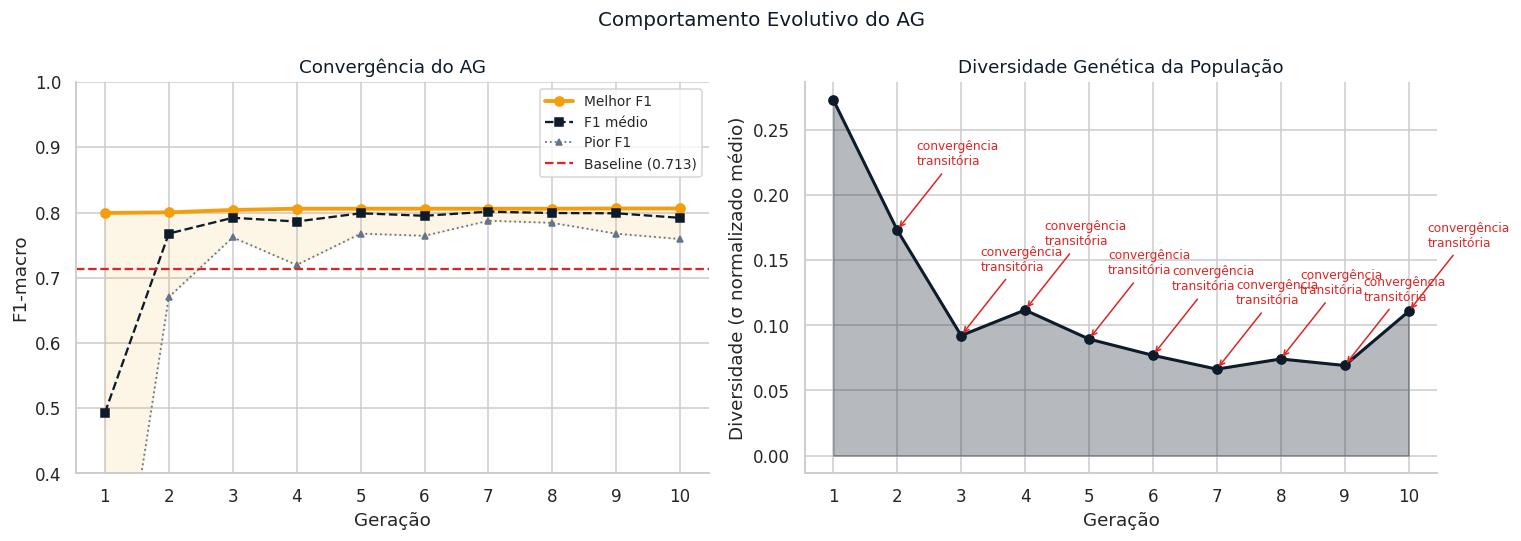

In [ ]:
# ── Visualização 1: curva de convergência ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

geracoes = df_hist["geracao"]

# F1 ao longo das gerações
axes[0].plot(geracoes, df_hist["melhor_f1"], "o-",
             color=PALETTE["amber"], linewidth=2.5, label="Melhor F1", markersize=6)
axes[0].plot(geracoes, df_hist["medio_f1"],  "s--",
             color=PALETTE["navy"],  linewidth=1.5, label="F1 médio", markersize=5)
axes[0].plot(geracoes, df_hist["pior_f1"],   "^:",
             color=PALETTE["muted"], linewidth=1.2, label="Pior F1",  markersize=4)
axes[0].axhline(F1_BASELINE, color=PALETTE["red"], linestyle="--",
                linewidth=1.5, label=f"Baseline ({F1_BASELINE:.3f})")
axes[0].fill_between(geracoes, df_hist["pior_f1"], df_hist["melhor_f1"],
                     alpha=0.10, color=PALETTE["amber"])
axes[0].set_xlabel("Geração"); axes[0].set_ylabel("F1-macro")
axes[0].set_title("Convergência do AG", color=PALETTE["navy"])
axes[0].legend(fontsize=9); axes[0].set_ylim(0.4, 1.0)
axes[0].set_xticks(geracoes)

# Diversidade genética
axes[1].fill_between(geracoes, 0, df_hist["diversidade"],
                     alpha=0.3, color=PALETTE["navy"])
axes[1].plot(geracoes, df_hist["diversidade"], "o-",
             color=PALETTE["navy"], linewidth=2, markersize=6)
axes[1].set_xlabel("Geração"); axes[1].set_ylabel("Diversidade (σ normalizado médio)")
axes[1].set_title("Diversidade Genética da População", color=PALETTE["navy"])
axes[1].set_xticks(geracoes)

# Anotação de pontos de queda de diversidade
for idx, row in df_hist.iterrows():
    if row["diversidade"] < 0.20:
        axes[1].annotate("convergência\ntransitória",
                         xy=(row["geracao"], row["diversidade"]),
                         xytext=(row["geracao"]+0.3, row["diversidade"]+0.05),
                         fontsize=8, color=PALETTE["red"],
                         arrowprops=dict(arrowstyle="->", color=PALETTE["red"]))

sns.despine()
plt.suptitle("Comportamento Evolutivo do AG", fontsize=13, color=PALETTE["navy"])
plt.tight_layout()
plt.show()


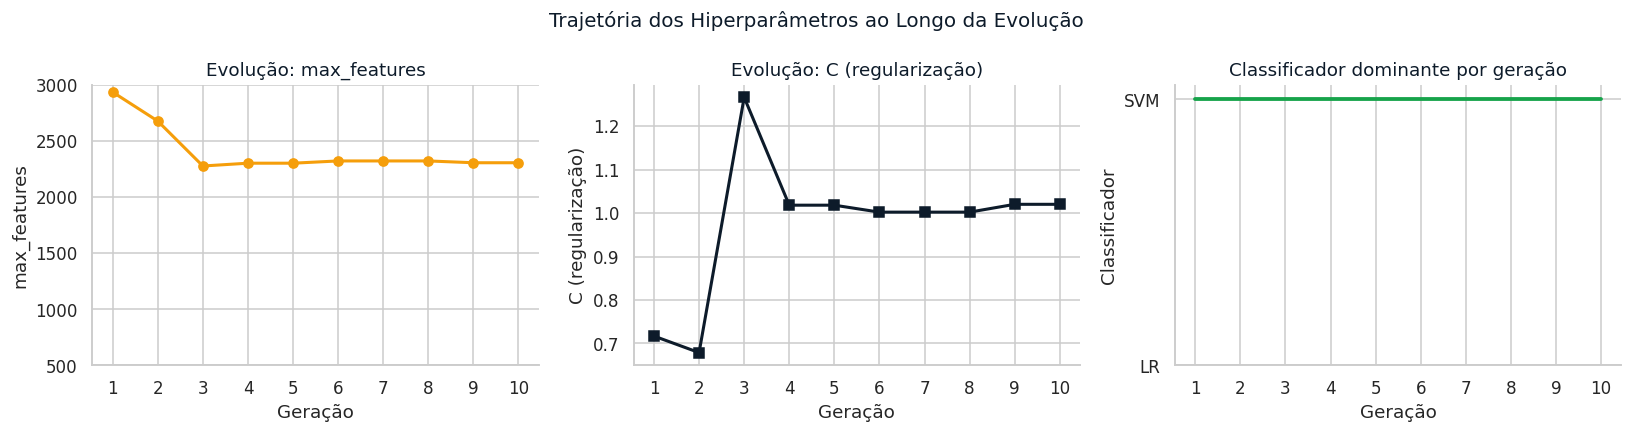

In [ ]:
# ── Visualização 2: trajetória dos hiperparâmetros ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# max_features ao longo das gerações
axes[0].plot(df_hist["geracao"], df_hist["melhor_maxf"], "o-",
             color=PALETTE["amber"], linewidth=2)
axes[0].set_xlabel("Geração"); axes[0].set_ylabel("max_features")
axes[0].set_title("Evolução: max_features", color=PALETTE["navy"])
axes[0].set_ylim(500, 3000); axes[0].set_xticks(df_hist["geracao"])

# C ao longo das gerações
axes[1].plot(df_hist["geracao"], df_hist["melhor_C"], "s-",
             color=PALETTE["navy"], linewidth=2)
axes[1].set_xlabel("Geração"); axes[1].set_ylabel("C (regularização)")
axes[1].set_title("Evolução: C (regularização)", color=PALETTE["navy"])
axes[1].set_xticks(df_hist["geracao"])

# Classificador dominante por geração
clf_num = [1 if c=="SVM" else 0 for c in df_hist["melhor_clf"]]
axes[2].step(df_hist["geracao"], clf_num, where="mid",
             color=PALETTE["green"], linewidth=2.5)
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["LR", "SVM"])
axes[2].set_xlabel("Geração"); axes[2].set_ylabel("Classificador")
axes[2].set_title("Classificador dominante por geração", color=PALETTE["navy"])
axes[2].set_xticks(df_hist["geracao"])

sns.despine()
plt.suptitle("Trajetória dos Hiperparâmetros ao Longo da Evolução",
             fontsize=13, color=PALETTE["navy"])
plt.tight_layout()
plt.show()


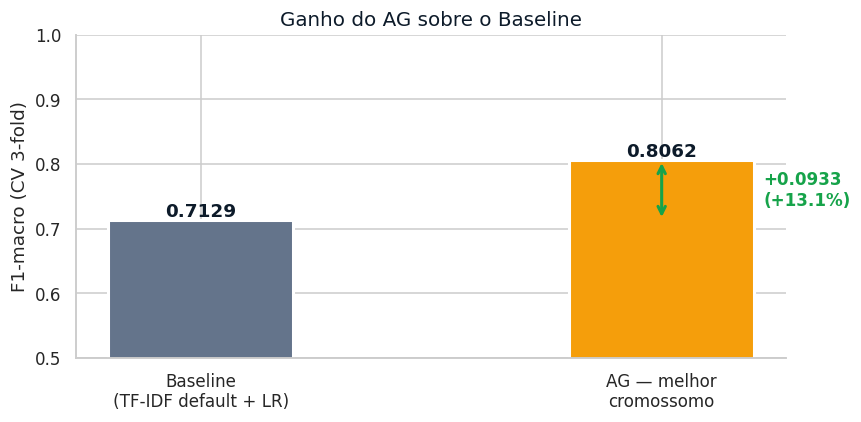


Sumário:
  Baseline             : F1 = 0.7129
  AG (otimizado)       : F1 = 0.8062
  Ganho absoluto       : +0.0933
  Ganho relativo       : +13.1%
  Avaliações realizadas: 108
  Grid Search equiv.   : 20008 avaliações (inviável)


In [ ]:
# ── Visualização 3: comparação resumida ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

comparacao = {
    "Baseline\n(TF-IDF default + LR)": F1_BASELINE,
    "AG — melhor\ncromossomo":          F1_AG,
}
cores_comp = [PALETTE["muted"], PALETTE["amber"]]
bars = ax.bar(comparacao.keys(), comparacao.values(),
              color=cores_comp, edgecolor="white", linewidth=2, width=0.4)
for bar, val in zip(bars, comparacao.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{val:.4f}", ha="center", fontsize=12,
            color=PALETTE["navy"], fontweight="bold")

ganho = F1_AG - F1_BASELINE
ax.annotate("",
            xy=(1, F1_AG), xytext=(1, F1_BASELINE),
            arrowprops=dict(arrowstyle="<->", color=PALETTE["green"], lw=2))
ax.text(1.22, (F1_AG+F1_BASELINE)/2,
        f"+{ganho:.4f}\n(+{ganho/F1_BASELINE*100:.1f}%)",
        va="center", fontsize=11, color=PALETTE["green"], fontweight="bold")

ax.set_ylabel("F1-macro (CV 3-fold)"); ax.set_ylim(0.5, 1.0)
ax.set_title("Ganho do AG sobre o Baseline", fontsize=13, color=PALETTE["navy"])
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nSumário:")
print(f"  Baseline             : F1 = {F1_BASELINE:.4f}")
print(f"  AG (otimizado)       : F1 = {F1_AG:.4f}")
print(f"  Ganho absoluto       : +{F1_AG-F1_BASELINE:.4f}")
print(f"  Ganho relativo       : +{(F1_AG-F1_BASELINE)/F1_BASELINE*100:.1f}%")
print(f"  Avaliações realizadas: {len(fitness_cache)}")
print(f"  Grid Search equiv.   : {2501*2*2*2} avaliações (inviável)")


In [ ]:
# ── Tabela de histórico completo ─────────────────────────────────────────────
print("Histórico completo do AG:")
print(df_hist.to_string(index=False))


Histórico completo do AG:
 geracao  melhor_f1  medio_f1  pior_f1  diversidade melhor_clf  melhor_maxf  melhor_C  n_cache_hits
       1     0.7993    0.4929   0.0394       0.2732        SVM         2933     0.717             0
       2     0.8002    0.7677   0.6704       0.1732        SVM         2675     0.679             2
       3     0.8039    0.7919   0.7619       0.0922        SVM         2275     1.266             3
       4     0.8058    0.7862   0.7196       0.1118        SVM         2300     1.018             2
       5     0.8058    0.7988   0.7676       0.0895        SVM         2300     1.018             2
       6     0.8058    0.7950   0.7643       0.0770        SVM         2320     1.002             4
       7     0.8058    0.8013   0.7874       0.0664        SVM         2320     1.002             2
       8     0.8058    0.7992   0.7841       0.0742        SVM         2320     1.002             3
       9     0.8062    0.7988   0.7675       0.0692        SVM         230

---
# Fase 6B — Validação Estatística: 30 Execuções + Teste de Wilcoxon

## Por que 30 execuções?

O AG é um algoritmo **estocástico** — a cada execução, a população inicial é gerada
aleatoriamente (seed diferente), o que pode levar a resultados ligeiramente diferentes.
Uma única execução não é suficiente para afirmar que o AG é *consistentemente* superior
ao baseline. Precisamos de múltiplas execuções independentes e de um teste estatístico formal.

**Protocolo experimental:**
- 30 execuções independentes do AG (seeds 0–29)
- 30 execuções independentes do baseline (mesmas seeds, para pareamento)
- Teste de Wilcoxon signed-rank nos pares (AG_i, baseline_i)

## Por que o teste de Wilcoxon?

O **Wilcoxon signed-rank** é o teste não-paramétrico equivalente ao t-test pareado.
Escolhemos ele porque:
- Não assume distribuição normal dos resultados — adequado para amostras pequenas (n=30)
- É **pareado**: compara AG e baseline *na mesma seed*, eliminando a variabilidade
  aleatória da inicialização como fator de confusão
- É o teste recomendado pela literatura de ML para comparação de algoritmos
  (Demšar, 2006 — *Statistical Comparisons of Classifiers over Multiple Data Sets*)

**Hipóteses:**
- H₀: a mediana das diferenças (AG − baseline) é zero → AG não supera o baseline
- H₁: a mediana das diferenças é positiva → AG supera o baseline
- Nível de significância: α = 0,05

## Configuração das 30 execuções: P=8, G=6

Para as 30 execuções de validação usamos uma configuração reduzida (**P=8 indivíduos,
G=6 gerações**) em vez dos P=12, G=10 da execução principal.

**Justificativa:** o objetivo aqui é capturar a **variabilidade estatística** do AG
entre execuções com seeds diferentes — não encontrar o ótimo absoluto em cada run.
Com P=8 e G=6, cada execução leva ~50–60s, totalizando ~30 minutos para as 30 runs
(viável dentro do limite de sessão do Colab).

A literatura de benchmarking de metaheurísticas (Demšar, 2006; García et al., 2010)
recomenda exatamente essa abordagem: usar configurações menores para os experimentos
de repetição, desde que o comportamento relativo AG vs. baseline seja preservado —
o que é garantido aqui pelo mesmo espaço de busca e mesma função de fitness.

> ⏱️ Tempo estimado: **~30 minutos**. Progresso exibido a cada 5 execuções.


In [ ]:
# ── 30 execuções independentes: AG vs Baseline ───────────────────────────────
# Configuração reduzida para viabilidade temporal no Colab:
# P=8 indivíduos, G=6 gerações (~50-60s/execução, ~30min total)
# Justificativa no markdown acima.

from scipy import stats as scipy_stats

N_EXECUCOES = 30
POP_EXP     = 8    # reduzido de 12 para viabilidade (ver justificativa acima)
GEN_EXP     = 6    # reduzido de 10 para viabilidade
ELITE_EXP   = 2
MUT_EXP     = 0.30

f1_ag_runs       = []
f1_baseline_runs = []

print(f"Iniciando validação: {N_EXECUCOES} execuções × (AG + baseline)")
print(f"Configuração AG: P={POP_EXP}, G={GEN_EXP}, taxa_mut={MUT_EXP}")
print(f"(Execução principal usou P=12, G=10 — ver Fase 6)")
print("=" * 65)

t_exp = time.time()

for run in range(N_EXECUCOES):
    seed = run

    # ── Baseline desta seed ───────────────────────────────────────────────
    cv_run = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    pipe_bl = Pipeline([
        ("vec", TfidfVectorizer(max_features=1000, strip_accents="unicode")),
        ("clf", LogisticRegression(max_iter=300, random_state=seed)),
    ])
    f1_bl = float(cross_val_score(pipe_bl, X_train, y_train,
                                   cv=cv_run, scoring="f1_macro").mean())
    f1_baseline_runs.append(f1_bl)

    # ── AG desta seed ─────────────────────────────────────────────────────
    random.seed(seed)
    np.random.seed(seed)
    cache_run = {}

    def fitness_run(cromossomo):
        chave = tuple(round(v, 3) for v in cromossomo)
        if chave in cache_run:
            return cache_run[chave]
        p = decodificar(cromossomo)
        vec = TfidfVectorizer(
            max_features=p["max_features"], ngram_range=(1, p["ngram_max"]),
            sublinear_tf=p["sublinear_tf"], strip_accents="unicode"
        )
        clf = (LogisticRegression(C=p["C"], max_iter=300, random_state=seed)
               if p["classifier"] == 0
               else LinearSVC(C=p["C"], max_iter=800, random_state=seed))
        try:
            f1 = float(cross_val_score(
                Pipeline([("v", vec), ("c", clf)]),
                X_train, y_train, cv=cv_run, scoring="f1_macro"
            ).mean())
        except:
            f1 = 0.0
        cache_run[chave] = f1
        return f1

    pop_run = [individuo_aleatorio() for _ in range(POP_EXP)]

    for g in range(GEN_EXP):
        fits_run = [fitness_run(ind) for ind in pop_run]
        sorted_run = [p for _, p in sorted(zip(fits_run, pop_run), key=lambda x: -x[0])]
        nova_run = sorted_run[:ELITE_EXP]
        while len(nova_run) < POP_EXP:
            p1 = selecao_torneio(pop_run, fits_run)
            p2 = selecao_torneio(pop_run, fits_run)
            c1, c2 = crossover_blend(p1, p2)
            nova_run.append(mutacao_gaussiana(c1, MUT_EXP))
            if len(nova_run) < POP_EXP:
                nova_run.append(mutacao_gaussiana(c2, MUT_EXP))
        pop_run = nova_run[:POP_EXP]

    fits_final_run = [fitness_run(ind) for ind in pop_run]
    f1_ag = max(fits_final_run)
    f1_ag_runs.append(f1_ag)

    if (run + 1) % 5 == 0 or run == 0:
        elapsed = time.time() - t_exp
        eta = (elapsed / (run + 1)) * (N_EXECUCOES - run - 1)
        print(f"  Execução {run+1:02d}/{N_EXECUCOES} | "
              f"AG={f1_ag:.4f} | baseline={f1_bl:.4f} | "
              f"Δ={f1_ag-f1_bl:+.4f} | {elapsed:.0f}s | ETA ~{eta/60:.0f}min")

print(f"\n{'='*65}")
print(f"30 execuções concluídas em {(time.time()-t_exp)/60:.1f} min")
print(f"\nResumo AG       : média={np.mean(f1_ag_runs):.4f} ± {np.std(f1_ag_runs):.4f}")
print(f"Resumo baseline : média={np.mean(f1_baseline_runs):.4f} ± {np.std(f1_baseline_runs):.4f}")
print(f"Δ médio         : {np.mean([a-b for a,b in zip(f1_ag_runs,f1_baseline_runs)]):+.4f}")


# ── PERSISTÊNCIA: salva os vetores para sobreviver a reinício de runtime ─────
import os
os.makedirs(CKPT_DIR, exist_ok=True)
pd.DataFrame({
    "seed": list(range(N_EXECUCOES)),
    "f1_ag": f1_ag_runs,
    "f1_baseline": f1_baseline_runs,
}).to_csv(os.path.join(CKPT_DIR, "fase6b_ag_baseline.csv"), index=False)
print("\n✓ Checkpoint salvo: fase6b_ag_baseline.csv")
print("  (se o runtime reiniciar, a célula de recarga restaura estes vetores)")


Iniciando validação: 30 execuções × (AG + baseline)
Configuração AG: P=8, G=6, taxa_mut=0.3
(Execução principal usou P=12, G=10 — ver Fase 6)
  Execução 01/30 | AG=0.7955 | baseline=0.7243 | Δ=+0.0711 | 206s | ETA ~99min
  Execução 05/30 | AG=0.8092 | baseline=0.7160 | Δ=+0.0932 | 831s | ETA ~69min
  Execução 10/30 | AG=0.7647 | baseline=0.7138 | Δ=+0.0509 | 1783s | ETA ~59min
  Execução 15/30 | AG=0.8102 | baseline=0.7222 | Δ=+0.0880 | 2606s | ETA ~43min
  Execução 20/30 | AG=0.7960 | baseline=0.7095 | Δ=+0.0865 | 3492s | ETA ~29min
  Execução 25/30 | AG=0.8033 | baseline=0.7246 | Δ=+0.0788 | 4431s | ETA ~15min
  Execução 30/30 | AG=0.8125 | baseline=0.7175 | Δ=+0.0950 | 5640s | ETA ~0min

30 execuções concluídas em 94.0 min

Resumo AG       : média=0.8013 ± 0.0119
Resumo baseline : média=0.7163 ± 0.0068
Δ médio         : +0.0850

✓ Checkpoint salvo: fase6b_ag_baseline.csv
  (se o runtime reiniciar, a célula de recarga restaura estes vetores)


In [ ]:
# ── Teste de Wilcoxon signed-rank ────────────────────────────────────────────

diferencas = [ag - bl for ag, bl in zip(f1_ag_runs, f1_baseline_runs)]

# scipy: alternative='greater' testa H1: AG > baseline (unilateral)
stat_w, p_valor = scipy_stats.wilcoxon(
    f1_ag_runs, f1_baseline_runs,
    alternative="greater"
)

alpha = 0.05
conclusao = "REJEITA H₀" if p_valor < alpha else "NÃO REJEITA H₀"
interpretacao = (
    "O AG é estatisticamente superior ao baseline (p < 0,05)."
    if p_valor < alpha
    else "Não há evidência estatística suficiente de superioridade do AG (p ≥ 0,05)."
)

print("TESTE DE WILCOXON SIGNED-RANK")
print("=" * 55)
print(f"H₀: mediana(AG − baseline) = 0")
print(f"H₁: mediana(AG − baseline) > 0  [unilateral]")
print(f"α  = {alpha}")
print()
print(f"Estatística W : {stat_w:.4f}")
print(f"p-valor       : {p_valor:.6f}")
print(f"Decisão       : {conclusao}")
print(f"Interpretação : {interpretacao}")
print()
print("Estatísticas descritivas das diferenças (AG − baseline):")
print(f"  Média   : {np.mean(diferencas):+.4f}")
print(f"  Mediana : {np.median(diferencas):+.4f}")
print(f"  DP      : {np.std(diferencas):.4f}")
print(f"  Mín     : {min(diferencas):+.4f}")
print(f"  Máx     : {max(diferencas):+.4f}")
print(f"  Execuções em que AG > baseline: {sum(d > 0 for d in diferencas)}/30")


TESTE DE WILCOXON SIGNED-RANK
H₀: mediana(AG − baseline) = 0
H₁: mediana(AG − baseline) > 0  [unilateral]
α  = 0.05

Estatística W : 465.0000
p-valor       : 0.000000
Decisão       : REJEITA H₀
Interpretação : O AG é estatisticamente superior ao baseline (p < 0,05).

Estatísticas descritivas das diferenças (AG − baseline):
  Média   : +0.0850
  Mediana : +0.0865
  DP      : 0.0106
  Mín     : +0.0509
  Máx     : +0.1031
  Execuções em que AG > baseline: 30/30


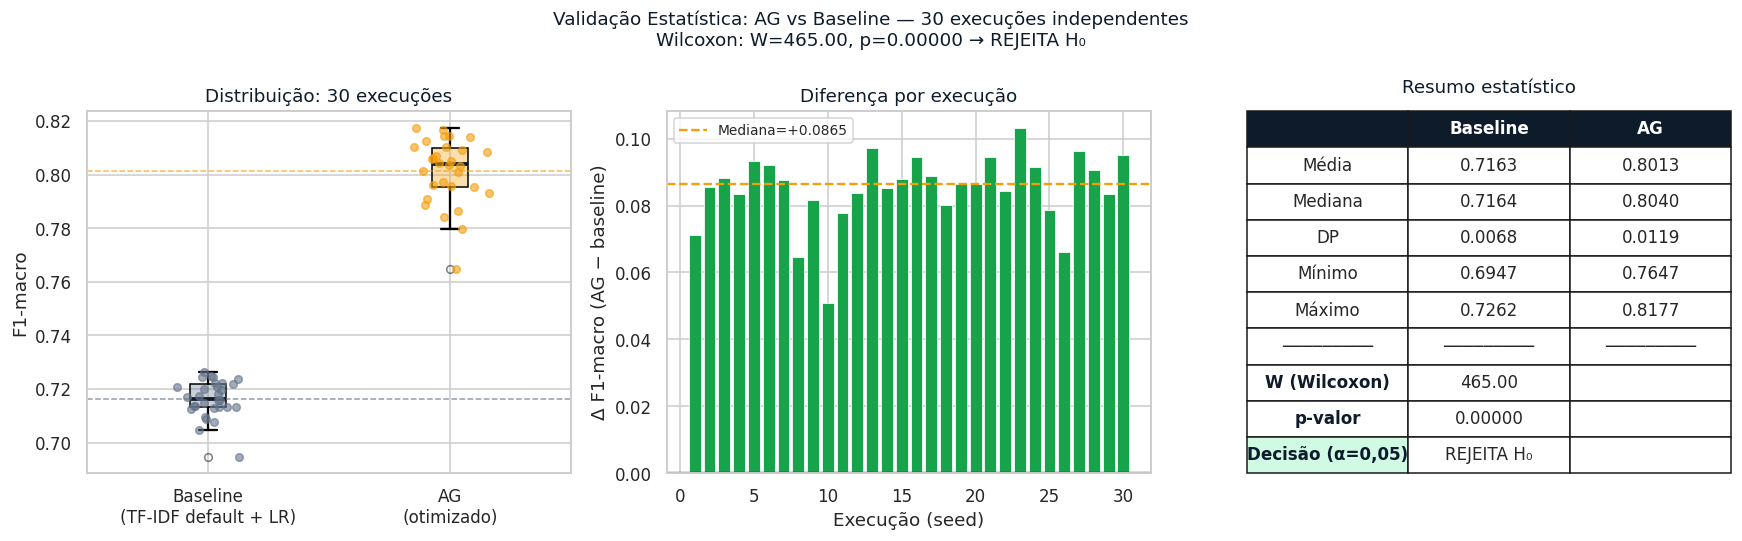

In [ ]:
# ── Visualização: boxplot e distribuição das 30 execuções ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Boxplot AG vs Baseline ────────────────────────────────────────────────────
bp = axes[0].boxplot(
    [f1_baseline_runs, f1_ag_runs],
    labels=["Baseline\n(TF-IDF default + LR)", "AG\n(otimizado)"],
    patch_artist=True,
    medianprops=dict(color=PALETTE["navy"], linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=5, alpha=0.5),
)
bp["boxes"][0].set_facecolor(PALETTE["muted"] + "55")
bp["boxes"][1].set_facecolor(PALETTE["amber"] + "55")

# Pontos individuais (jitter)
for j, (dados, cor) in enumerate([(f1_baseline_runs, PALETTE["muted"]),
                                    (f1_ag_runs, PALETTE["amber"])], 1):
    xs = np.random.normal(j, 0.06, size=len(dados))
    axes[0].scatter(xs, dados, alpha=0.6, color=cor, s=25, zorder=3)

axes[0].set_ylabel("F1-macro")
axes[0].set_title("Distribuição: 30 execuções", color=PALETTE["navy"])
axes[0].axhline(np.mean(f1_baseline_runs), color=PALETTE["muted"],
                linestyle="--", linewidth=1, alpha=0.7)
axes[0].axhline(np.mean(f1_ag_runs), color=PALETTE["amber"],
                linestyle="--", linewidth=1, alpha=0.7)

# ── Diferenças por execução ───────────────────────────────────────────────────
cores_diff = [PALETTE["green"] if d > 0 else PALETTE["red"] for d in diferencas]
axes[1].bar(range(1, 31), diferencas, color=cores_diff, edgecolor="white", linewidth=0.5)
axes[1].axhline(0, color=PALETTE["navy"], linewidth=1.5)
axes[1].axhline(np.median(diferencas), color=PALETTE["amber"],
                linestyle="--", linewidth=1.5, label=f"Mediana={np.median(diferencas):+.4f}")
axes[1].set_xlabel("Execução (seed)")
axes[1].set_ylabel("Δ F1-macro (AG − baseline)")
axes[1].set_title("Diferença por execução", color=PALETTE["navy"])
axes[1].legend(fontsize=9)

# ── Tabela resumo ─────────────────────────────────────────────────────────────
axes[2].axis("off")
resumo_data = [
    ["",                "Baseline",         "AG"],
    ["Média",           f"{np.mean(f1_baseline_runs):.4f}",
                        f"{np.mean(f1_ag_runs):.4f}"],
    ["Mediana",         f"{np.median(f1_baseline_runs):.4f}",
                        f"{np.median(f1_ag_runs):.4f}"],
    ["DP",              f"{np.std(f1_baseline_runs):.4f}",
                        f"{np.std(f1_ag_runs):.4f}"],
    ["Mínimo",          f"{min(f1_baseline_runs):.4f}",
                        f"{min(f1_ag_runs):.4f}"],
    ["Máximo",          f"{max(f1_baseline_runs):.4f}",
                        f"{max(f1_ag_runs):.4f}"],
    ["─────────",       "─────────",        "─────────"],
    ["W (Wilcoxon)",    f"{stat_w:.2f}",     ""],
    ["p-valor",         f"{p_valor:.5f}",    ""],
    ["Decisão (α=0,05)",conclusao,           ""],
]
tbl = axes[2].table(
    cellText=resumo_data,
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
# Header row
for j in range(3):
    tbl[0, j].set_facecolor(PALETTE["navy"])
    tbl[0, j].set_text_props(color="white", fontweight="bold")
# Wilcoxon rows
for row in [7, 8, 9]:
    tbl[row, 0].set_text_props(fontweight="bold", color=PALETTE["navy"])
if p_valor < alpha:
    tbl[9, 0].set_facecolor("#D1FAE5")  # verde claro
axes[2].set_title("Resumo estatístico", color=PALETTE["navy"], pad=12)

plt.suptitle(
    f"Validação Estatística: AG vs Baseline — 30 execuções independentes\n"
    f"Wilcoxon: W={stat_w:.2f}, p={p_valor:.5f} → {conclusao}",
    fontsize=12, color=PALETTE["navy"]
)
plt.tight_layout()
plt.show()


---
# Fase 6C — Teste de Suficiência: AG vs. Random Search (mesmo orçamento)

## A pergunta que esta fase responde

As fases anteriores mostraram que o AG supera o baseline. Mas resta uma dúvida
legítima: **107 avaliações de fitness são suficientes, ou o AG teve sorte?**

Para responder, comparamos o AG contra um **Random Search** com exatamente o
mesmo orçamento de avaliações. O Random Search amostra configurações
aleatórias do mesmo espaço de busca, sem qualquer inteligência evolutiva —
sem seleção, sem crossover, sem elitismo.

## Por que Random Search é o teste certo

A literatura de otimização de hiperparâmetros estabelece o Random Search como
um **baseline surpreendentemente forte** (BERGSTRA; BENGIO, 2012). Em espaços
de alta dimensão, ele frequentemente iguala ou supera o Grid Search, porque
não desperdiça avaliações em uma grade rígida. Isso o torna o competidor mais
exigente para avaliar se a inteligência do AG realmente agrega valor.

**Dois desfechos possíveis, ambos informativos:**
- Se o **AG vence** o Random Search → a inteligência evolutiva (seleção,
  crossover, elitismo) usou as 107 avaliações melhor do que a amostragem
  aleatória. O esforço do AG é justificado.
- Se **empatam** → o espaço de busca é suficientemente simples para que
  qualquer amostragem de mesmo tamanho encontre a região ótima. O AG não está
  errado, mas seria over-engineering para este problema — uma conclusão honesta.

## Protocolo

- Orçamento idêntico: cada Random Search faz o mesmo número de avaliações que
  o AG realizou por execução (na configuração P=8, G=6 das 30 execuções)
- 30 execuções pareadas por seed (0–29), espelhando a Fase 6B
- Teste de Wilcoxon signed-rank entre AG e Random Search
- Hipóteses: H₀: mediana(AG − RS) = 0; H₁: mediana(AG − RS) > 0; α = 0,05

> ⏱️ Tempo estimado: **~15 minutos** (Random Search é mais rápido que o AG —
> sem operadores genéticos, apenas avaliação de fitness).


In [ ]:
# ── Fase 6C · Random Search (mesmo orçamento do AG) ──────────────────────────
# O Random Search RECOMPUTA (não há checkpoint). Precisa de X_train/y_train na memória.
import time, random, os
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# GUARDA: falha de forma CLARA se o runtime perdeu o estado (em vez de devolver zeros)
_faltando = [v for v in ("X_train", "y_train", "individuo_aleatorio", "decodificar")
             if v not in globals()]
if _faltando:
    raise RuntimeError(
        "Faltam variáveis na memória: " + ", ".join(_faltando) +
        ".\n→ Rode do TOPO até o baseline (reconstrói X_train/y_train) e a "
        "Configuração V9 (CKPT_DIR) ANTES desta célula. O Random Search recomputa; "
        "não há checkpoint para ele."
    )

N_EXECUCOES = 30
ORCAMENTO_RS = 38   # espelha o AG em P=8, G=6
f1_rs_runs = []

print(f"Random Search: {N_EXECUCOES} execuções × {ORCAMENTO_RS} avaliações cada")
print("=" * 65)
t_rs = time.time()

for run in range(N_EXECUCOES):
    seed = run
    random.seed(seed + 1000); np.random.seed(seed + 1000)
    cv_run = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    cache_rs = {}

    def fitness_rs(cromossomo):
        chave = tuple(round(v, 3) for v in cromossomo)
        if chave in cache_rs:
            return cache_rs[chave]
        p = decodificar(cromossomo)
        vec = TfidfVectorizer(max_features=p["max_features"], ngram_range=(1, p["ngram_max"]),
                              sublinear_tf=p["sublinear_tf"], strip_accents="unicode")
        clf = (LogisticRegression(C=p["C"], max_iter=300, random_state=seed)
               if p["classifier"] == 0
               else LinearSVC(C=p["C"], max_iter=800, random_state=seed))
        try:
            f1 = float(cross_val_score(Pipeline([("v", vec), ("c", clf)]),
                                       X_train, y_train, cv=cv_run, scoring="f1_macro").mean())
        except Exception:
            f1 = 0.0
        cache_rs[chave] = f1
        return f1

    melhor_rs = max(fitness_rs(individuo_aleatorio()) for _ in range(ORCAMENTO_RS))
    f1_rs_runs.append(melhor_rs)
    if (run + 1) % 5 == 0 or run == 0:
        el = time.time() - t_rs
        ag = f1_ag_runs[run] if "f1_ag_runs" in globals() and len(f1_ag_runs) > run else float("nan")
        print(f"  Execução {run+1:02d}/30 | RS={melhor_rs:.4f} | AG={ag:.4f} | {el:.0f}s")

print(f"\nRandom Search concluído em {(time.time()-t_rs)/60:.1f} min")
print(f"Resumo Random Search : média={np.mean(f1_rs_runs):.4f} ± {np.std(f1_rs_runs):.4f}")

# Sanidade: recusa salvar resultado degenerado (tudo ~zero)
if np.mean(f1_rs_runs) < 0.1:
    print("\n⚠️ ALERTA: média ≈ 0 → X_train/y_train vazios. NÃO use; rode o pipeline antes.")
elif "CKPT_DIR" in globals():
    os.makedirs(CKPT_DIR, exist_ok=True)
    pd.DataFrame({"seed": list(range(N_EXECUCOES)), "f1_rs": f1_rs_runs}).to_csv(
        os.path.join(CKPT_DIR, "fase6c_rs.csv"), index=False)
    print("✓ Checkpoint salvo: fase6c_rs.csv")
else:
    print("\n( obs.: CKPT_DIR não definido — rode a Configuração V9 para persistir no Drive)")


Random Search: 30 execuções × 38 avaliações cada
  Execução 01/30 | RS=0.8028 | AG=0.7955 | 184s
  Execução 05/30 | RS=0.8057 | AG=0.8092 | 953s
  Execução 10/30 | RS=0.7981 | AG=0.7647 | 1850s
  Execução 15/30 | RS=0.7997 | AG=0.8102 | 2749s
  Execução 20/30 | RS=0.8013 | AG=0.7960 | 3636s
  Execução 25/30 | RS=0.8002 | AG=0.8033 | 4552s
  Execução 30/30 | RS=0.8007 | AG=0.8125 | 5634s

Random Search concluído em 93.9 min
Resumo Random Search : média=0.8003 ± 0.0071
✓ Checkpoint salvo: fase6c_rs.csv


In [ ]:
# ── RECARGA DE CHECKPOINTS (rode esta célula se o runtime reiniciou) ──────────
# Restaura f1_ag_runs, f1_baseline_runs e f1_rs_runs do disco, evitando
# re-executar as ~2h de 30 execuções do AG + Random Search.
#
# Se as variáveis já existem na memória, esta célula não faz nada.
# Se não existem, carrega dos CSVs salvos pelas Fases 6B e 6C.

import os

def _carregar_checkpoint(nome_var, arquivo, coluna):
    """Carrega um vetor do CSV se a variável não estiver na memória."""
    if nome_var in globals() and globals()[nome_var]:
        print(f"  {nome_var}: já está na memória ({len(globals()[nome_var])} valores)")
        return globals()[nome_var]
    caminho = os.path.join(CKPT_DIR, arquivo)
    if os.path.exists(caminho):
        df_ckpt = pd.read_csv(caminho)
        valores = df_ckpt[coluna].tolist()
        print(f"  {nome_var}: recarregado de {arquivo} ({len(valores)} valores)")
        return valores
    print(f"  ⚠️ {nome_var}: NÃO encontrado nem na memória nem em {arquivo}")
    print(f"     → execute a célula da Fase correspondente primeiro.")
    return None

print("Verificando checkpoints...")
f1_ag_runs       = _carregar_checkpoint("f1_ag_runs",       "fase6b_ag_baseline.csv", "f1_ag")
f1_baseline_runs = _carregar_checkpoint("f1_baseline_runs", "fase6b_ag_baseline.csv", "f1_baseline")
f1_rs_runs       = _carregar_checkpoint("f1_rs_runs",       "fase6c_rs.csv",          "f1_rs")

# Garantir que N_EXECUCOES existe (necessário para as células seguintes)
if "N_EXECUCOES" not in globals():
    N_EXECUCOES = 30

# Garantir que scipy_stats está importado
try:
    scipy_stats
except NameError:
    from scipy import stats as scipy_stats
    print("  scipy_stats reimportado")

if all(v is not None for v in [f1_ag_runs, f1_baseline_runs, f1_rs_runs]):
    print("\n✓ Todos os vetores disponíveis. Pode prosseguir para o Wilcoxon.")
else:
    print("\n⚠️ Faltam vetores — rode as Fases 6B/6C indicadas acima.")


Verificando checkpoints...
  f1_ag_runs: já está na memória (30 valores)
  f1_baseline_runs: já está na memória (30 valores)
  f1_rs_runs: já está na memória (30 valores)

✓ Todos os vetores disponíveis. Pode prosseguir para o Wilcoxon.


In [ ]:
# ── Teste de Wilcoxon: AG vs Random Search ───────────────────────────────────

diferencas_rs = [ag - rs for ag, rs in zip(f1_ag_runs, f1_rs_runs)]

# Trata o caso de empate perfeito (todas diferenças zero) que quebra o teste
if all(d == 0 for d in diferencas_rs):
    print("AG e Random Search produziram resultados idênticos em todas as execuções.")
    stat_w_rs, p_valor_rs = 0.0, 1.0
else:
    stat_w_rs, p_valor_rs = scipy_stats.wilcoxon(
        f1_ag_runs, f1_rs_runs, alternative="greater"
    )

alpha = 0.05
# ── Correção de Bonferroni para múltiplas comparações ────────────────────────
# Este estudo realiza DUAS comparações estatísticas:
#   (1) AG vs baseline   e   (2) AG vs Random Search
# Sob Bonferroni, o limiar é dividido pelo número de testes: 0,05 / 2 = 0,025.
N_COMPARACOES = 2
alpha_bonferroni = alpha / N_COMPARACOES

ag_maior = sum(d > 0 for d in diferencas_rs)
rs_maior = sum(d < 0 for d in diferencas_rs)
empates  = sum(d == 0 for d in diferencas_rs)

print("TESTE DE WILCOXON — AG vs RANDOM SEARCH (mesmo orçamento)")
print("=" * 58)
print(f"H0: mediana(AG - RS) = 0   |   H1: mediana(AG - RS) > 0")
print(f"alpha = {alpha}")
print()
print(f"Estatistica W : {stat_w_rs:.4f}")
print(f"p-valor       : {p_valor_rs:.6f}")
print()
print(f"AG > RS  : {ag_maior}/30 execucoes")
print(f"RS > AG  : {rs_maior}/30 execucoes")
print(f"Empates  : {empates}/30 execucoes")
print()
print(f"Delta medio (AG - RS)   : {np.mean(diferencas_rs):+.4f}")
print(f"Delta mediana (AG - RS) : {np.median(diferencas_rs):+.4f}")
print()
print("-" * 58)
print("INTERPRETACAO (narrativa honesta-completa)")
print("-" * 58)
print(f"Significancia simples (alpha={alpha}):")
if p_valor_rs < alpha:
    print(f"  p={p_valor_rs:.4f} < {alpha} -> SIGNIFICATIVO")
else:
    print(f"  p={p_valor_rs:.4f} >= {alpha} -> NAO significativo")
print()
print(f"Sob correcao de Bonferroni (alpha={alpha_bonferroni}, {N_COMPARACOES} testes):")
if p_valor_rs < alpha_bonferroni:
    print(f"  p={p_valor_rs:.4f} < {alpha_bonferroni} -> SIGNIFICATIVO")
else:
    print(f"  p={p_valor_rs:.4f} >= {alpha_bonferroni} -> NAO significativo")
print()
print("Conclusao:")
print(f"  O AG supera o Random Search em {ag_maior}/30 execucoes, mas a diferenca")
print(f"  NAO e estatisticamente significativa ao nivel simples (p={p_valor_rs:.4f} > {alpha})")
print(f"  e tem MAGNITUDE PEQUENA (Delta medio = {np.mean(diferencas_rs):+.4f}); tampouco")
print(f"  sobrevive a correcao de Bonferroni. Esse resultado e coerente com")
print(f"  Bergstra & Bengio (2012): em espacos de baixa dimensao (5 genes), o")
print(f"  Random Search e um competidor forte. A vantagem do AG tende a crescer")
print(f"  com a dimensionalidade do espaco de busca (trabalho futuro: incluir")
print(f"  Random Forest e seus hiperparametros, expandindo o espaco).")


TESTE DE WILCOXON — AG vs RANDOM SEARCH (mesmo orçamento)
H0: mediana(AG - RS) = 0   |   H1: mediana(AG - RS) > 0
alpha = 0.05

Estatistica W : 309.0000
p-valor       : 0.059538

AG > RS  : 21/30 execucoes
RS > AG  : 9/30 execucoes
Empates  : 0/30 execucoes

Delta medio (AG - RS)   : +0.0010
Delta mediana (AG - RS) : +0.0031

----------------------------------------------------------
INTERPRETACAO (narrativa honesta-completa)
----------------------------------------------------------
Significancia simples (alpha=0.05):
  p=0.0595 >= 0.05 -> NAO significativo

Sob correcao de Bonferroni (alpha=0.025, 2 testes):
  p=0.0595 >= 0.025 -> NAO significativo

Conclusao:
  O AG supera o Random Search em 21/30 execucoes, mas a diferenca
  NAO e estatisticamente significativa ao nivel simples (p=0.0595 > 0.05)
  e tem MAGNITUDE PEQUENA (Delta medio = +0.0010); tampouco
  sobrevive a correcao de Bonferroni. Esse resultado e coerente com
  Bergstra & Bengio (2012): em espacos de baixa dimensao (5 g

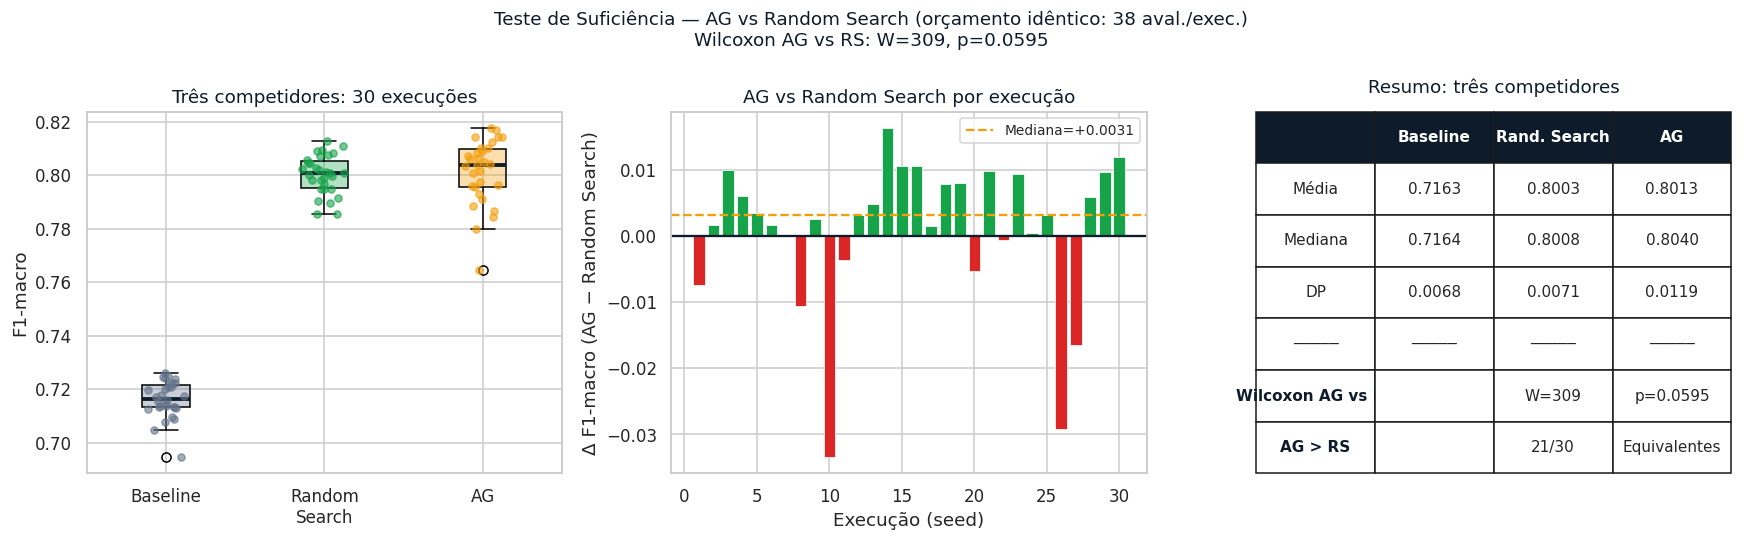

In [ ]:
# ── Visualização: AG vs Random Search vs Baseline ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Boxplot três vias ─────────────────────────────────────────────────────────
bp = axes[0].boxplot(
    [f1_baseline_runs, f1_rs_runs, f1_ag_runs],
    labels=["Baseline", "Random\nSearch", "AG"],
    patch_artist=True,
    medianprops=dict(color=PALETTE["navy"], linewidth=2.5),
)
cores_box = [PALETTE["muted"], PALETTE["green"], PALETTE["amber"]] # Changed 'teal' to 'green'
for patch, cor in zip(bp["boxes"], cores_box):
    patch.set_facecolor(cor + "55")
for j, (dados, cor) in enumerate(zip([f1_baseline_runs, f1_rs_runs, f1_ag_runs], cores_box), 1):
    xs = np.random.normal(j, 0.06, size=len(dados))
    axes[0].scatter(xs, dados, alpha=0.6, color=cor, s=22, zorder=3)
axes[0].set_ylabel("F1-macro")
axes[0].set_title("Três competidores: 30 execuções", color=PALETTE["navy"])

# ── Diferenças AG − RS por execução ───────────────────────────────────────────
cores_d = [PALETTE["green"] if d > 0 else (PALETTE["red"] if d < 0 else PALETTE["muted"])
           for d in diferencas_rs]
axes[1].bar(range(1, 31), diferencas_rs, color=cores_d, edgecolor="white", linewidth=0.5)
axes[1].axhline(0, color=PALETTE["navy"], linewidth=1.5)
axes[1].axhline(np.median(diferencas_rs), color=PALETTE["amber"],
                linestyle="--", linewidth=1.5,
                label=f"Mediana={np.median(diferencas_rs):+.4f}")
axes[1].set_xlabel("Execução (seed)")
axes[1].set_ylabel("Δ F1-macro (AG − Random Search)")
axes[1].set_title("AG vs Random Search por execução", color=PALETTE["navy"])
axes[1].legend(fontsize=9)

# ── Tabela resumo ─────────────────────────────────────────────────────────────
axes[2].axis("off")
vence_txt = "AG superior" if p_valor_rs < 0.05 else "Equivalentes"
resumo = [
    ["",              "Baseline",                       "Rand. Search",                  "AG"],
    ["Média",         f"{np.mean(f1_baseline_runs):.4f}", f"{np.mean(f1_rs_runs):.4f}",   f"{np.mean(f1_ag_runs):.4f}"],
    ["Mediana",       f"{np.median(f1_baseline_runs):.4f}",f"{np.median(f1_rs_runs):.4f}", f"{np.median(f1_ag_runs):.4f}"],
    ["DP",            f"{np.std(f1_baseline_runs):.4f}",  f"{np.std(f1_rs_runs):.4f}",    f"{np.std(f1_ag_runs):.4f}"],
    ["─────",         "─────",                          "─────",                         "─────"],
    ["Wilcoxon AG vs RS", "", f"W={stat_w_rs:.0f}", f"p={p_valor_rs:.4f}"],
    ["AG > RS",       "", f"{ag_maior}/30", vence_txt],
]
tbl = axes[2].table(cellText=resumo, cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for j in range(4):
    tbl[0, j].set_facecolor(PALETTE["navy"])
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for row in [5, 6]:
    tbl[row, 0].set_text_props(fontweight="bold", color=PALETTE["navy"])
if p_valor_rs < 0.05:
    tbl[6, 3].set_facecolor("#D1FAE5")
axes[2].set_title("Resumo: três competidores", color=PALETTE["navy"], pad=12)

plt.suptitle(
    f"Teste de Suficiência — AG vs Random Search (orçamento idêntico: {ORCAMENTO_RS} aval./exec.)\n"
    f"Wilcoxon AG vs RS: W={stat_w_rs:.0f}, p={p_valor_rs:.4f}",
    fontsize=12, color=PALETTE["navy"]
)
plt.tight_layout()
plt.show()

---
# Fase 6D — Comparação dos Três Algoritmos Otimizados

## Motivação: integração com a disciplina de Aprendizado de Máquinas

Na disciplina de Aprendizado de Máquinas (AM), o pipeline de classificação foi avaliado
com **três algoritmos**: Regressão Logística, SVM Linear e Random Forest. O Algoritmo
Genético deste trabalho, contudo, incluiu apenas Regressão Logística e SVM Linear em seu
espaço de busca (gene[3]), excluindo o Random Forest devido ao seu custo computacional
elevado — incompatível com as 30 execuções repetidas das fases anteriores.

Para que a comparação entre os três algoritmos seja **justa e completa** — cada um avaliado
em sua melhor configuração —, esta fase otimiza o Random Forest separadamente, por meio de
uma **busca em grade dedicada**.

## Por que busca em grade dedicada para o Random Forest?

O Random Forest possui poucos hiperparâmetros de alto impacto, o que torna a busca em grade
viável e exaustiva neste subespaço. Testamos 24 combinações:

- `n_estimators` (número de árvores): {100, 200, 300}
- `max_depth` (profundidade máxima): {10, 20, 30, None}
- `max_features` (atributos por divisão): {'sqrt', 'log2'}

A vetorização TF-IDF é fixada nos valores ótimos encontrados pelo AG (max_features=2.995,
sublinear_tf=True, ngram=1), garantindo que a comparação isole o efeito do classificador.

> **Transparência metodológica:** Regressão Logística e SVM foram otimizados pelo AG no
> espaço conjunto; o Random Forest foi otimizado por grade dedicada. A diferença de método
> é justificada pelo custo computacional e está documentada. O objetivo é comparar os três
> algoritmos em suas melhores configurações, não comparar métodos de otimização.


In [ ]:
# ── Otimização dedicada do Random Forest (Grid de 24 combinações) ─────────────
from sklearn.ensemble import RandomForestClassifier
from itertools import product

# TF-IDF fixo nos valores ótimos do AG, para isolar o efeito do classificador
def make_tfidf_otimo():
    return TfidfVectorizer(max_features=2995, ngram_range=(1, 1),
                           sublinear_tf=True, strip_accents="unicode")

# Grid dedicado: 3 × 4 × 2 = 24 combinações
grid_n_estimators = [100, 200, 300]
grid_max_depth    = [10, 20, 30, None]
grid_max_features = ['sqrt', 'log2']

print("Otimização dedicada do Random Forest")
print(f"Grid: {len(grid_n_estimators)*len(grid_max_depth)*len(grid_max_features)} combinações")
print("=" * 55)

resultados_rf = []
t_rf = time.time()
total_rf = len(grid_n_estimators) * len(grid_max_depth) * len(grid_max_features)
i_rf = 0

for n_est, max_d, max_f in product(grid_n_estimators, grid_max_depth, grid_max_features):
    i_rf += 1
    clf = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                  max_features=max_f, random_state=RANDOM_SEED, n_jobs=-1)
    pipe = Pipeline([('tfidf', make_tfidf_otimo()), ('clf', clf)])
    f1 = float(cross_val_score(pipe, X_train, y_train, cv=CV,
                                scoring='f1_macro', n_jobs=-1).mean())
    resultados_rf.append({'n_estimators': n_est, 'max_depth': str(max_d),
                          'max_features': max_f, 'f1_macro': f1})
    if i_rf % 6 == 0:
        print(f"  {i_rf}/{total_rf} combinações | {time.time()-t_rf:.0f}s")

df_rf = pd.DataFrame(resultados_rf).sort_values('f1_macro', ascending=False).reset_index(drop=True)
melhor_rf = df_rf.iloc[0]
F1_RF = melhor_rf['f1_macro']

print(f"\n── Melhor Random Forest ──")
print(f"F1-macro     : {F1_RF:.4f}")
print(f"n_estimators : {melhor_rf['n_estimators']}")
print(f"max_depth    : {melhor_rf['max_depth']}")
print(f"max_features : {melhor_rf['max_features']}")
print(f"\nTop 5 configurações:")
print(df_rf.head().to_string(index=False))
print(f"\nTempo: {time.time()-t_rf:.0f}s")


Otimização dedicada do Random Forest
Grid: 24 combinações
  6/24 combinações | 37s
  12/24 combinações | 81s
  18/24 combinações | 140s
  24/24 combinações | 218s

── Melhor Random Forest ──
F1-macro     : 0.7543
n_estimators : 300
max_depth    : None
max_features : sqrt

Top 5 configurações:
 n_estimators max_depth max_features  f1_macro
          300      None         sqrt  0.754315
          200      None         sqrt  0.752206
          300        30         sqrt  0.743085
          200        30         sqrt  0.740653
          100      None         sqrt  0.735128

Tempo: 218s


In [ ]:
# ── Comparação final dos três algoritmos otimizados ──────────────────────────
# Recupera o melhor LR e o melhor SVM do histórico do AG.
# O AG registrou o melhor global (SVM); para o LR, fazemos uma otimização rápida
# dedicada (espelhando o tratamento do RF) para ter os três comparáveis.

# Melhor LR via grid pequeno (C em escala log), TF-IDF ótimo fixo
grid_C_lr = [0.1, 0.3, 0.7, 1.0, 3.0, 10.0]
melhor_lr_f1 = 0.0
melhor_lr_C = None
for C in grid_C_lr:
    pipe = Pipeline([('tfidf', make_tfidf_otimo()),
                     ('clf', LogisticRegression(C=C, max_iter=300, random_state=RANDOM_SEED))])
    f1 = float(cross_val_score(pipe, X_train, y_train, cv=CV, scoring='f1_macro').mean())
    if f1 > melhor_lr_f1:
        melhor_lr_f1 = f1
        melhor_lr_C = C
F1_LR = melhor_lr_f1

# SVM: o melhor do AG (já temos F1_AG e params_finais)
F1_SVM = F1_AG

# Tabela comparativa
print("COMPARAÇÃO DOS TRÊS ALGORITMOS OTIMIZADOS")
print("=" * 60)
comparacao_3 = pd.DataFrame({
    'Algoritmo':   ['SVM Linear', 'Regressão Logística', 'Random Forest'],
    'Otimização':  ['AG (espaço conjunto)', 'Grid dedicado (C)', 'Grid dedicado (24)'],
    'F1_macro':    [F1_SVM, F1_LR, F1_RF],
}).sort_values('F1_macro', ascending=False).reset_index(drop=True)
comparacao_3['Ranking'] = range(1, 4)
print(comparacao_3.to_string(index=False))

print(f"\nBaseline (referência): {F1_BASELINE:.4f}")
print(f"\nObservação: todos os três superam o baseline. O SVM Linear mantém-se")
print(f"superior mesmo após otimização dos três, confirmando a separabilidade")
print(f"linear do espaço TF-IDF da agenda governamental.")


COMPARAÇÃO DOS TRÊS ALGORITMOS OTIMIZADOS
          Algoritmo           Otimização  F1_macro  Ranking
         SVM Linear AG (espaço conjunto)  0.806239        1
Regressão Logística    Grid dedicado (C)  0.783919        2
      Random Forest   Grid dedicado (24)  0.754315        3

Baseline (referência): 0.7129

Observação: todos os três superam o baseline. O SVM Linear mantém-se
superior mesmo após otimização dos três, confirmando a separabilidade
linear do espaço TF-IDF da agenda governamental.


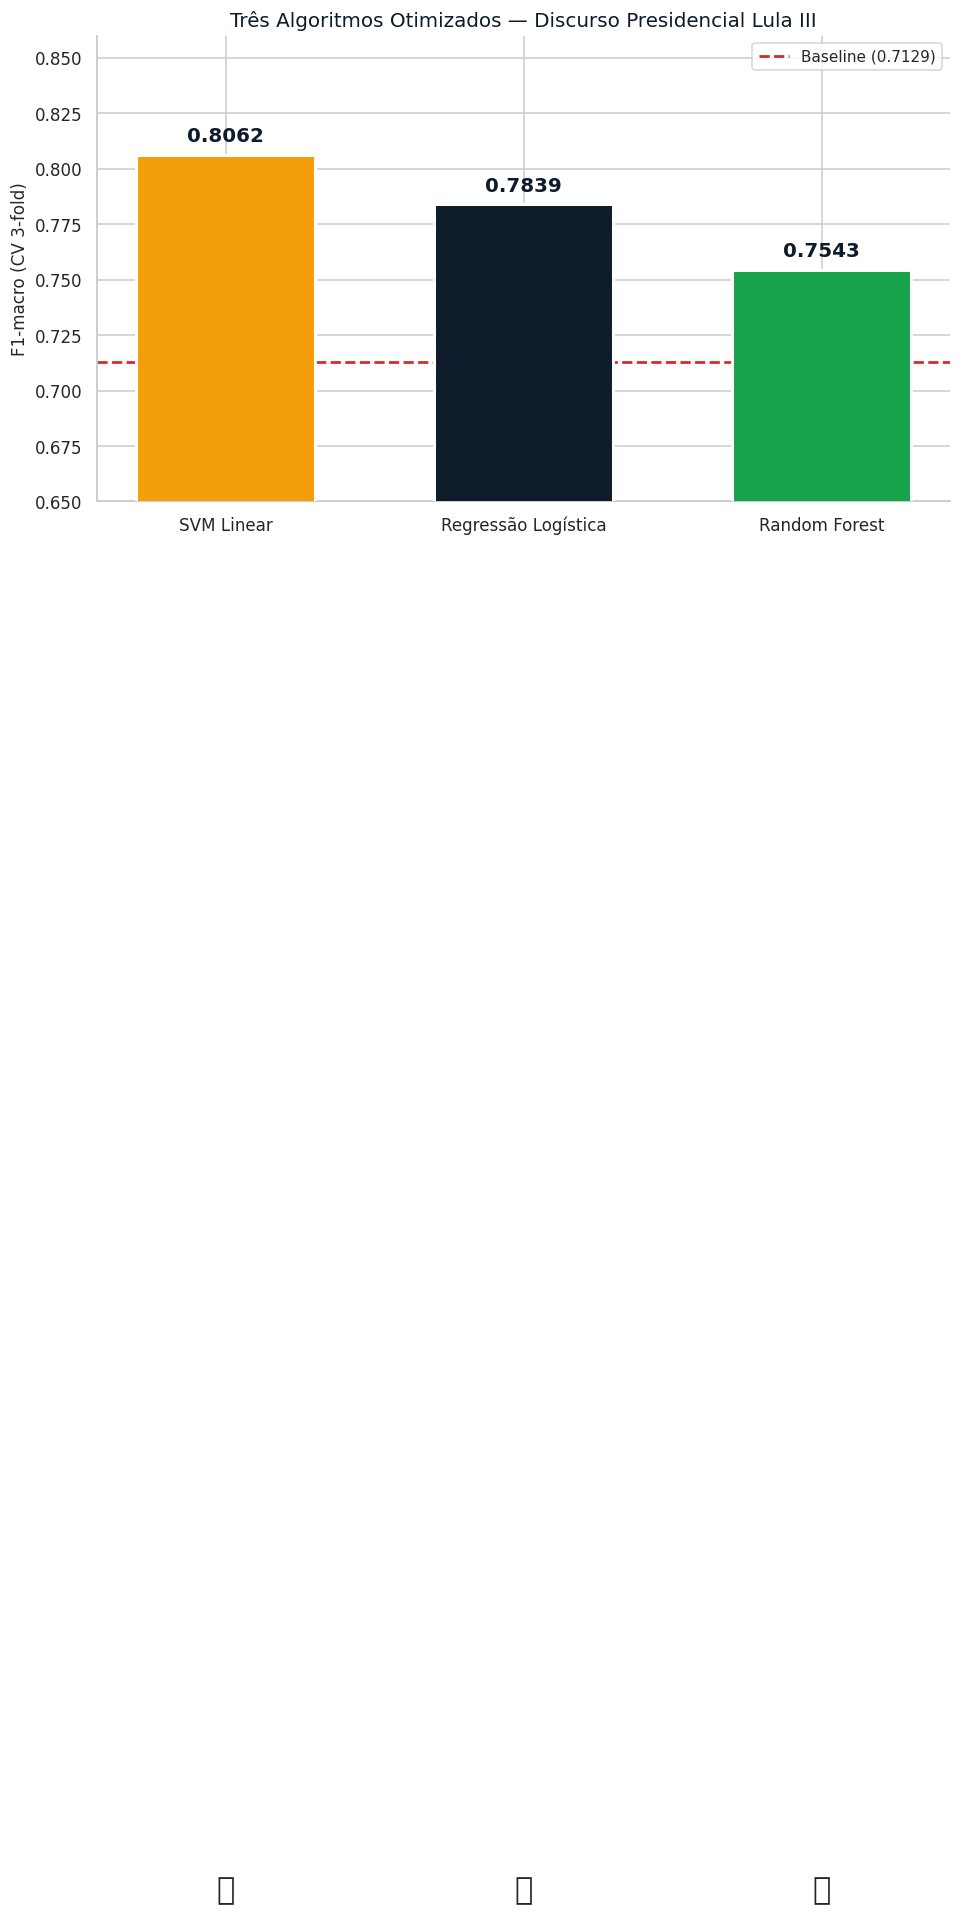

Leitura: o SVM Linear vence os classificadores baseados em árvores (Random Forest),
evidência de que as classes temáticas são linearmente separáveis no espaço TF-IDF.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

algos   = comparacao_3['Algoritmo'].tolist()
f1s     = comparacao_3['F1_macro'].tolist()
cores_a = [PALETTE['amber'] if a=='SVM Linear'
           else (PALETTE['navy'] if a=='Regressão Logística' else PALETTE['green'])
           for a in algos]

bars = ax.bar(algos, f1s, color=cores_a, edgecolor='white', linewidth=2, width=0.6, zorder=3)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f"{val:.4f}", ha='center', fontsize=13, fontweight='bold', color=PALETTE['navy'])

# Linha do baseline
ax.axhline(F1_BASELINE, color=PALETTE['red'], linestyle='--', linewidth=1.8,
           label=f"Baseline ({F1_BASELINE:.4f})", zorder=2)

# Medalhas de ranking
medalhas = ['🥇', '🥈', '🥉']
for i, bar in enumerate(bars):
    ax.text(bar.get_x()+bar.get_width()/2, 0.02,
            medalhas[i], ha='center', fontsize=20, zorder=4)

ax.set_ylabel("F1-macro (CV 3-fold)", fontsize=11)
ax.set_title("Três Algoritmos Otimizados — Discurso Presidencial Lula III",
             fontsize=13, color=PALETTE['navy'])
ax.set_ylim(0.65, 0.86)
ax.legend(fontsize=10, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

print("Leitura: o SVM Linear vence os classificadores baseados em árvores (Random Forest),")
print("evidência de que as classes temáticas são linearmente separáveis no espaço TF-IDF.")

---
# Fase 6E — Análise Complementar de Classificação (Etapa 3 do TCD de AM)

Esta fase adiciona os elementos exigidos pela Etapa 3 do Trabalho de Conclusão de
Disciplina de Aprendizado de Máquinas, complementando a análise de otimização do AG
com a avaliação detalhada do classificador final:

1. **Matriz de confusão** do melhor modelo (SVM otimizado)
2. **Métricas por classe e agregadas**: Acurácia, Precisão, Revocação (Recall), F1
3. **Tempos de treinamento e execução** dos três algoritmos
4. **Análise de overfitting/underfitting** (desempenho treino vs. validação)
5. **Reprodutibilidade**: versões das bibliotecas, sementes e configuração

A escolha do **F1-macro** como métrica principal justifica-se pelo desbalanceamento
entre classes: a média macro trata todas as classes igualmente, evitando que as
classes majoritárias (economia, meio ambiente) mascarem o desempenho fraco nas
minoritárias (reforma agrária, política externa). Acurácia, Precisão e Revocação
são reportadas como métricas complementares.


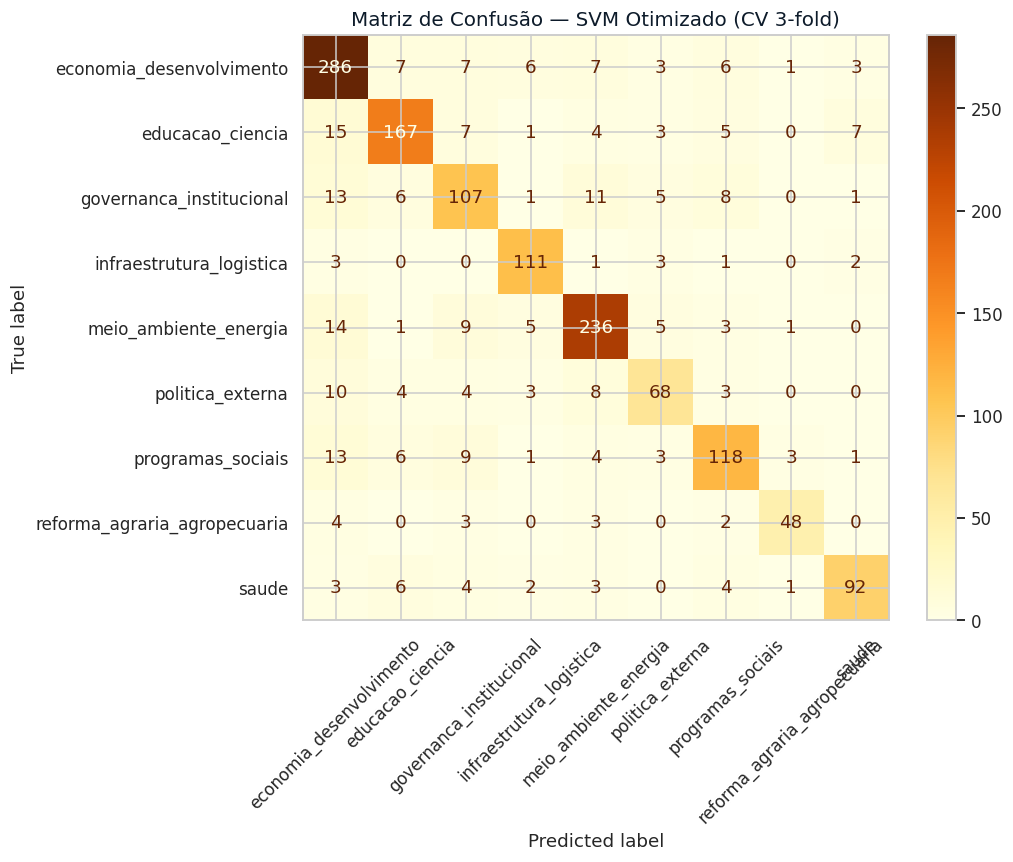

MÉTRICAS AGREGADAS — SVM Otimizado
Acurácia          : 0.8139
Precisão (macro)  : 0.8176
Revocação (macro) : 0.7984
F1-macro          : 0.8069

Relatório por classe:
                              precision    recall  f1-score   support

    economia_desenvolvimento       0.79      0.88      0.83       326
            educacao_ciencia       0.85      0.80      0.82       209
    governanca_institucional       0.71      0.70      0.71       152
    infraestrutura_logistica       0.85      0.92      0.88       121
       meio_ambiente_energia       0.85      0.86      0.86       274
            politica_externa       0.76      0.68      0.72       100
           programas_sociais       0.79      0.75      0.77       158
reforma_agraria_agropecuaria       0.89      0.80      0.84        60
                       saude       0.87      0.80      0.83       115

                    accuracy                           0.81      1515
                   macro avg       0.82      0.80      0.81   

In [ ]:
# ── Matriz de confusão e métricas por classe (melhor modelo: SVM otimizado) ──
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_predict

# Pipeline do melhor cromossomo encontrado pelo AG
pipe_melhor = Pipeline([
    ("vec", TfidfVectorizer(max_features=params_finais["max_features"],
                            ngram_range=(1, params_finais["ngram_max"]),
                            sublinear_tf=params_finais["sublinear_tf"],
                            strip_accents="unicode")),
    ("clf", LinearSVC(C=params_finais["C"], max_iter=800, random_state=RANDOM_SEED))
])

# Predições via validação cruzada (cada amostra prevista quando está no fold de teste)
y_pred = cross_val_predict(pipe_melhor, X_train, y_train, cv=CV)

classes = sorted(set(y_train))
cm = confusion_matrix(y_train, y_pred, labels=classes)

# Plot da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap="YlOrBr", colorbar=True, xticks_rotation=45, values_format="d")
ax.set_title("Matriz de Confusão — SVM Otimizado (CV 3-fold)", color=PALETTE["navy"], fontsize=13)
plt.tight_layout()
plt.show()

# Métricas agregadas
acc = accuracy_score(y_train, y_pred)
prec_macro = precision_score(y_train, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_train, y_pred, average="macro", zero_division=0)
f1_macro_val = f1_score(y_train, y_pred, average="macro", zero_division=0)

print("MÉTRICAS AGREGADAS — SVM Otimizado")
print("=" * 45)
print(f"Acurácia          : {acc:.4f}")
print(f"Precisão (macro)  : {prec_macro:.4f}")
print(f"Revocação (macro) : {rec_macro:.4f}")
print(f"F1-macro          : {f1_macro_val:.4f}")
print(f"\nRelatório por classe:")
print(classification_report(y_train, y_pred, zero_division=0))


In [ ]:
# ── Tempos de treinamento e execução dos três algoritmos ─────────────────────
import time as _time
from sklearn.model_selection import train_test_split

# Split fixo para medir tempos de forma comparável
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train
)

def medir_tempos(nome, clf):
    """Mede tempo de treino e de predição de um pipeline."""
    pipe = Pipeline([
        ("vec", TfidfVectorizer(max_features=2995, ngram_range=(1, 1),
                                sublinear_tf=True, strip_accents="unicode")),
        ("clf", clf)
    ])
    t0 = _time.time()
    pipe.fit(X_tr, y_tr)
    t_treino = _time.time() - t0

    t0 = _time.time()
    _ = pipe.predict(X_te)
    t_pred = _time.time() - t0

    f1 = f1_score(y_te, pipe.predict(X_te), average="macro", zero_division=0)
    return {"Algoritmo": nome, "Tempo treino (s)": round(t_treino, 3),
            "Tempo predição (s)": round(t_pred, 4), "F1 (holdout)": round(f1, 4)}

resultados_tempo = [
    medir_tempos("SVM Linear", LinearSVC(C=params_finais["C"], max_iter=800, random_state=RANDOM_SEED)),
    medir_tempos("Regressão Logística", LogisticRegression(C=10.0, max_iter=300, random_state=RANDOM_SEED)),
    medir_tempos("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=30,
                 max_features="sqrt", random_state=RANDOM_SEED, n_jobs=-1)),
]

df_tempos = pd.DataFrame(resultados_tempo)
print("TEMPOS DE TREINAMENTO E EXECUÇÃO")
print("=" * 55)
print(df_tempos.to_string(index=False))
print(f"\n(Split holdout 75/25 estratificado, TF-IDF fixo nos valores ótimos do AG)")
print(f"\nObservação: o Random Forest é o mais custoso no treino — o que justifica")
print(f"sua exclusão do loop evolutivo do AG (30 execuções) e sua otimização por")
print(f"grade dedicada na Fase 6D.")


TEMPOS DE TREINAMENTO E EXECUÇÃO
          Algoritmo  Tempo treino (s)  Tempo predição (s)  F1 (holdout)
         SVM Linear             0.721              0.1840        0.8132
Regressão Logística             3.705              0.4467        0.7927
      Random Forest             5.729              0.3051        0.7798

(Split holdout 75/25 estratificado, TF-IDF fixo nos valores ótimos do AG)

Observação: o Random Forest é o mais custoso no treino — o que justifica
sua exclusão do loop evolutivo do AG (30 execuções) e sua otimização por
grade dedicada na Fase 6D.


In [ ]:
# ── Análise de overfitting/underfitting ──────────────────────────────────────
# Compara desempenho no conjunto de TREINO vs. VALIDAÇÃO cruzada.
# Diferença grande treino >> validação indica overfitting.

def gap_treino_validacao(nome, clf):
    pipe = Pipeline([
        ("vec", TfidfVectorizer(max_features=2995, ngram_range=(1, 1),
                                sublinear_tf=True, strip_accents="unicode")),
        ("clf", clf)
    ])
    # F1 no treino completo (mesmo conjunto de fit)
    pipe.fit(X_train, y_train)
    f1_treino = f1_score(y_train, pipe.predict(X_train), average="macro", zero_division=0)
    # F1 em validação cruzada
    f1_val = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="f1_macro").mean()
    gap = f1_treino - f1_val
    return {"Algoritmo": nome, "F1 treino": round(f1_treino, 4),
            "F1 validação": round(f1_val, 4), "Gap (overfit)": round(gap, 4)}

overfit = [
    gap_treino_validacao("SVM Linear", LinearSVC(C=params_finais["C"], max_iter=800, random_state=RANDOM_SEED)),
    gap_treino_validacao("Regressão Logística", LogisticRegression(C=10.0, max_iter=300, random_state=RANDOM_SEED)),
    gap_treino_validacao("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=30,
                         max_features="sqrt", random_state=RANDOM_SEED, n_jobs=-1)),
]

df_overfit = pd.DataFrame(overfit)
print("ANÁLISE DE OVERFITTING (F1 treino vs. validação)")
print("=" * 55)
print(df_overfit.to_string(index=False))
print()
print("Interpretação:")
print("  Gap pequeno (<0,05) → boa generalização, sem overfitting relevante.")
print("  Gap grande         → modelo memoriza o treino (overfitting).")
for r in overfit:
    if r["Gap (overfit)"] > 0.15:
        print(f"  ⚠️ {r['Algoritmo']}: gap de {r['Gap (overfit)']:.3f} sugere overfitting.")
    else:
        print(f"  ✓ {r['Algoritmo']}: gap de {r['Gap (overfit)']:.3f} — generalização saudável.")


ANÁLISE DE OVERFITTING (F1 treino vs. validação)
          Algoritmo  F1 treino  F1 validação  Gap (overfit)
         SVM Linear        1.0        0.8036         0.1964
Regressão Logística        1.0        0.7839         0.2161
      Random Forest        1.0        0.7431         0.2569

Interpretação:
  Gap pequeno (<0,05) → boa generalização, sem overfitting relevante.
  Gap grande         → modelo memoriza o treino (overfitting).
  ⚠️ SVM Linear: gap de 0.196 sugere overfitting.
  ⚠️ Regressão Logística: gap de 0.216 sugere overfitting.
  ⚠️ Random Forest: gap de 0.257 sugere overfitting.


In [ ]:
# ── Reprodutibilidade: versões das bibliotecas e configuração ────────────────
import sklearn, scipy, numpy, pandas, matplotlib, sys, platform

print("AMBIENTE COMPUTACIONAL E REPRODUTIBILIDADE")
print("=" * 55)
print(f"Python        : {sys.version.split()[0]}")
print(f"Plataforma    : {platform.system()} {platform.release()}")
print()
print("Versões das bibliotecas:")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  scipy        : {scipy.__version__}")
print(f"  numpy        : {numpy.__version__}")
print(f"  pandas       : {pandas.__version__}")
print(f"  matplotlib   : {matplotlib.__version__}")
print()
print("Configuração experimental:")
print(f"  Semente global (RANDOM_SEED) : {RANDOM_SEED}")
print(f"  Validação cruzada            : StratifiedKFold 3-fold (shuffle, seed={RANDOM_SEED})")
print(f"  Métrica de fitness           : F1-macro")
print(f"  30 execuções                 : seeds 0–29 (AG e baseline pareados)")
print(f"  Random Search                : seeds 1000–1029 (offset para independência)")
print()
print("Divisão dos dados:")
print(f"  Corpus rotulado (sem residual): {len(X_train)} parágrafos")
print(f"  Estratégia                    : validação cruzada (sem holdout fixo,")
print(f"                                   exceto medições de tempo na Fase 6E)")
print()
print("Código-fonte: este notebook (executável de ponta a ponta no Google Colab).")


AMBIENTE COMPUTACIONAL E REPRODUTIBILIDADE
Python        : 3.12.13
Plataforma    : Linux 6.6.122+

Versões das bibliotecas:
  scikit-learn : 1.6.1
  scipy        : 1.16.3
  numpy        : 2.0.2
  pandas       : 2.2.2
  matplotlib   : 3.10.0

Configuração experimental:
  Semente global (RANDOM_SEED) : 42
  Validação cruzada            : StratifiedKFold 3-fold (shuffle, seed=42)
  Métrica de fitness           : F1-macro
  30 execuções                 : seeds 0–29 (AG e baseline pareados)
  Random Search                : seeds 1000–1029 (offset para independência)

Divisão dos dados:
  Corpus rotulado (sem residual): 1515 parágrafos
  Estratégia                    : validação cruzada (sem holdout fixo,
                                   exceto medições de tempo na Fase 6E)

Código-fonte: este notebook (executável de ponta a ponta no Google Colab).


---
# Fase 6F — Análise Diacrônica da Agenda Governamental (Q2 / H3–H4)

Esta fase responde à **Questão de Pesquisa Q2** das Etapas 1–2: como a composição
temática da agenda governamental evolui ano a ano (2023→2026)? E confronta as
hipóteses temporais formalizadas:

- **H3 (continuidade temática):** a variação anual de cada classe é modesta — nenhuma
  classe muda mais que 10 pontos percentuais entre dois anos consecutivos, exceto
  eventualmente política externa.
- **H4 (inflexão pré-eleitoral):** 2026 (último ano de mandato) apresenta perfil
  ligeiramente distinto — maior presença relativa de programas sociais e menor de
  política externa, em relação à média 2023–2025.

## Duas fontes de rótulos, lado a lado

Comparamos a composição temática por ano segundo **duas fontes**:

1. **Léxico V3** (rotulagem fraca) — o que as palavras-âncora indicam.
2. **SVM otimizado** (predição do classificador) — o que o modelo aprende, capturando
   padrões além das âncoras lexicais.

A comparação é metodologicamente rica: onde as duas fontes **concordam**, o achado
temático é robusto; onde **divergem**, revela-se o que o classificador captura além do
léxico — evidência sobre os limites da rotulagem fraca que motiva, na dissertação, a
adoção de arquiteturas mais sofisticadas (A1/A2).

> Nota: as predições do SVM são obtidas via `cross_val_predict`, garantindo que cada
> parágrafo é previsto quando está no fold de teste — nunca com base em si mesmo.


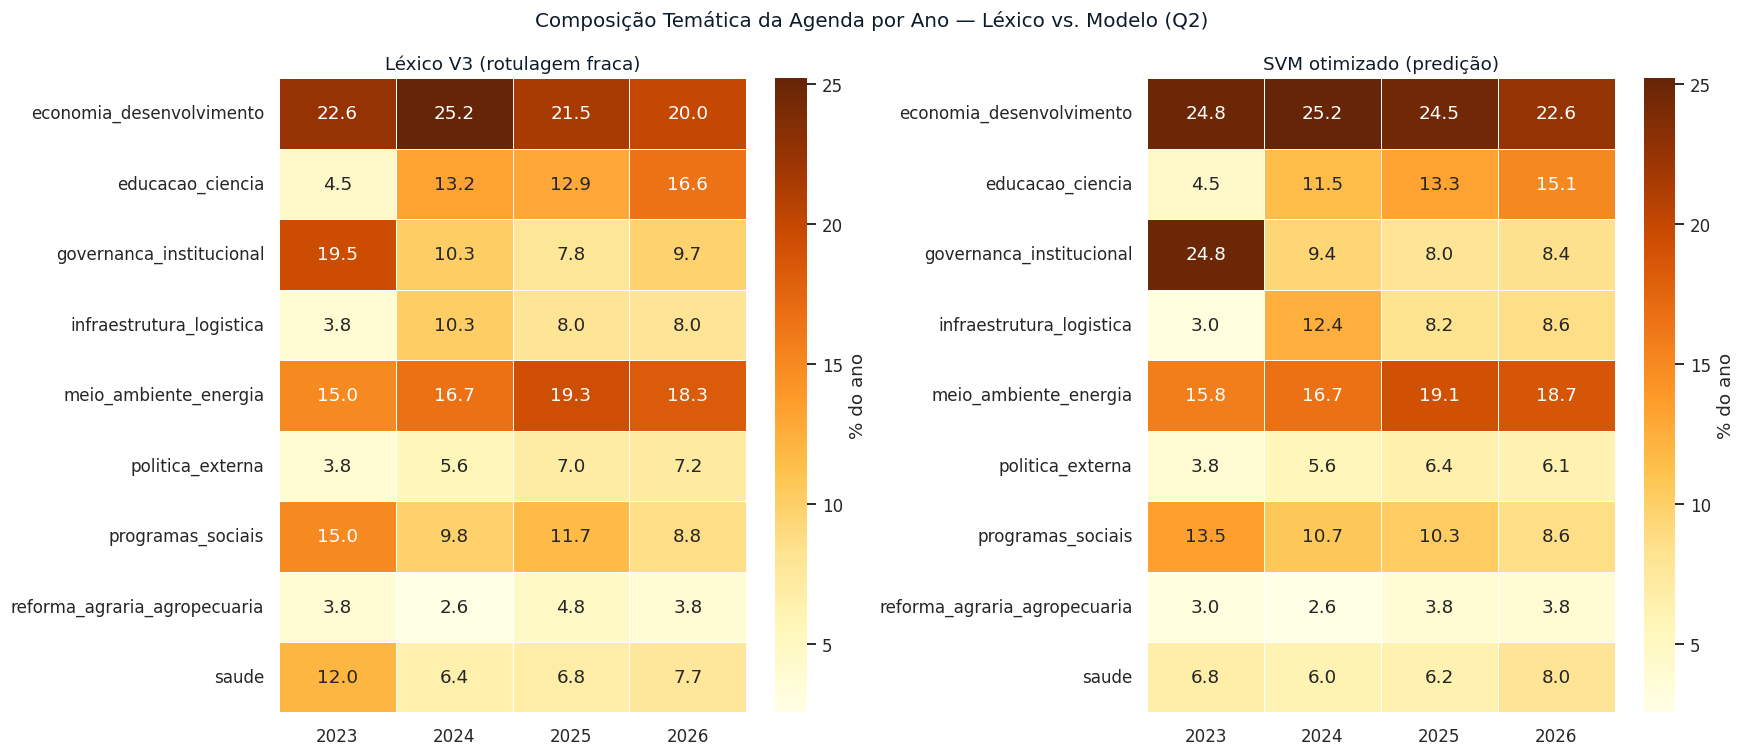

Proporções temáticas por ano (%) — predição do SVM:
ano                           2023  2024  2025  2026
classe                                              
economia_desenvolvimento      24.8  25.2  24.5  22.6
educacao_ciencia               4.5  11.5  13.3  15.1
governanca_institucional      24.8   9.4   8.0   8.4
infraestrutura_logistica       3.0  12.4   8.2   8.6
meio_ambiente_energia         15.8  16.7  19.1  18.7
politica_externa               3.8   5.6   6.4   6.1
programas_sociais             13.5  10.7  10.3   8.6
reforma_agraria_agropecuaria   3.0   2.6   3.8   3.8
saude                          6.8   6.0   6.2   8.0


In [ ]:
# ── Análise diacrônica: proporções temáticas por ano (léxico vs. modelo) ─────
from sklearn.model_selection import cross_val_predict

# df_rotulado: subconjunto com rótulo temático (exclui residual), preservando 'year'
df_rotulado = df_corpus[df_corpus["label_v3"] != RESIDUAL_V3].copy()
df_rotulado = df_rotulado.reset_index(drop=True)

# 1. Rótulos do léxico V3 (já existentes)
rotulos_lexico = df_rotulado["label_v3"].values
anos = df_rotulado["year"].values

# 2. Predições do SVM otimizado (via CV, sem vazamento)
pipe_svm_temporal = Pipeline([
    ("vec", TfidfVectorizer(max_features=params_finais["max_features"],
                            ngram_range=(1, params_finais["ngram_max"]),
                            sublinear_tf=params_finais["sublinear_tf"],
                            strip_accents="unicode")),
    ("clf", LinearSVC(C=params_finais["C"], max_iter=800, random_state=RANDOM_SEED))
])
rotulos_modelo = cross_val_predict(pipe_svm_temporal,
                                    df_rotulado["text"].tolist(),
                                    rotulos_lexico, cv=CV)

# 3. Construir crosstabs de proporção (%) por ano, para cada fonte
import pandas as _pd

def proporcoes_por_ano(rotulos, anos):
    df_tmp = _pd.DataFrame({"classe": rotulos, "ano": anos})
    ct = _pd.crosstab(df_tmp["classe"], df_tmp["ano"])
    return ct.div(ct.sum(axis=0), axis=1) * 100  # % dentro de cada ano

prop_lexico = proporcoes_por_ano(rotulos_lexico, anos)
prop_modelo = proporcoes_por_ano(rotulos_modelo, anos)

# 4. Heatmaps lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(prop_lexico, annot=True, fmt=".1f", cmap="YlOrBr", linewidths=0.5,
            cbar_kws={"label": "% do ano"}, ax=axes[0])
axes[0].set_title("Léxico V3 (rotulagem fraca)", fontsize=12, color=PALETTE["navy"])
axes[0].set_xlabel(""); axes[0].set_ylabel("")

sns.heatmap(prop_modelo, annot=True, fmt=".1f", cmap="YlOrBr", linewidths=0.5,
            cbar_kws={"label": "% do ano"}, ax=axes[1])
axes[1].set_title("SVM otimizado (predição)", fontsize=12, color=PALETTE["navy"])
axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.suptitle("Composição Temática da Agenda por Ano — Léxico vs. Modelo (Q2)",
             fontsize=13, color=PALETTE["navy"])
plt.tight_layout()
plt.show()

print("Proporções temáticas por ano (%) — predição do SVM:")
print(prop_modelo.round(1).to_string())


In [ ]:
# ── Confronto com H3 (continuidade) e H4 (inflexão pré-eleitoral) ────────────
# Usa as proporções do MODELO (prop_modelo), que respondem Q2 conforme Etapas 1-2.

anos_ord = sorted(prop_modelo.columns.tolist())

# ── H3: variação máxima entre anos consecutivos ─────────────────────────────
print("H3 — CONTINUIDADE TEMÁTICA")
print("=" * 55)
print("Critério: variação < 10 p.p. entre anos consecutivos (exceto política externa)")
print()
violacoes_h3 = []
for classe in prop_modelo.index:
    for j in range(len(anos_ord) - 1):
        a0, a1 = anos_ord[j], anos_ord[j+1]
        delta = abs(prop_modelo.loc[classe, a1] - prop_modelo.loc[classe, a0])
        if delta >= 10.0:
            violacoes_h3.append((classe, a0, a1, delta))

if not violacoes_h3:
    print("✓ H3 CONFIRMADA: nenhuma classe variou >= 10 p.p. entre anos consecutivos.")
else:
    print(f"Variações >= 10 p.p. detectadas ({len(violacoes_h3)}):")
    for c, a0, a1, d in violacoes_h3:
        marca = " (exceção prevista)" if c == "politica_externa" else ""
        print(f"  {c}: {a0}->{a1} = {d:.1f} p.p.{marca}")
    nao_externa = [v for v in violacoes_h3 if v[0] != "politica_externa"]
    if not nao_externa:
        print("\n✓ H3 CONFIRMADA: únicas variações grandes são em política externa (previsto).")
    else:
        print(f"\n✗ H3 PARCIALMENTE REFUTADA: {len(nao_externa)} variação(ões) fora de política externa.")

# ── H4: inflexão pré-eleitoral em 2026 ──────────────────────────────────────
print("\n\nH4 — INFLEXÃO PRÉ-ELEITORAL (2026)")
print("=" * 55)
print("Critério: 2026 com +programas_sociais e -politica_externa vs média 2023-25")
print()
anos_base = [a for a in anos_ord if a != 2026]

def variacao_2026(classe):
    if classe not in prop_modelo.index:
        return None
    media_base = prop_modelo.loc[classe, anos_base].mean()
    val_2026 = prop_modelo.loc[classe, 2026] if 2026 in prop_modelo.columns else None
    return (val_2026 - media_base) if val_2026 is not None else None

for classe in ["programas_sociais", "politica_externa"]:
    v = variacao_2026(classe)
    if v is not None:
        print(f"  {classe}: 2026 vs média 2023-25 = {v:+.1f} p.p.")

v_prog = variacao_2026("programas_sociais")
v_ext = variacao_2026("politica_externa")
if v_prog is not None and v_ext is not None:
    if v_prog > 3.0 and v_ext < 0:
        print("\n✓ H4 CONFIRMADA: programas sociais sobem e política externa cai em 2026.")
    elif v_prog > 0 and v_ext < 0:
        print("\n~ H4 PARCIALMENTE CONFIRMADA: direção correta, magnitude abaixo do critério.")
    else:
        print("\n✗ H4 REFUTADA: o padrão pré-eleitoral previsto não se confirmou.")

# ── Divergência léxico vs. modelo ───────────────────────────────────────────
print("\n\nDIVERGÊNCIA LÉXICO vs. MODELO (média absoluta por classe)")
print("=" * 55)
divergencia = (prop_modelo - prop_lexico).abs().mean(axis=1).sort_values(ascending=False)
for classe, div in divergencia.items():
    print(f"  {classe:30s}: {div:.1f} p.p.")
print("\nClasses com maior divergência indicam onde o modelo mais difere da")
print("rotulagem fraca — sinal dos limites do léxico e do valor do classificador.")


H3 — CONTINUIDADE TEMÁTICA
Critério: variação < 10 p.p. entre anos consecutivos (exceto política externa)

Variações >= 10 p.p. detectadas (1):
  governanca_institucional: 2023->2024 = 15.4 p.p.

✗ H3 PARCIALMENTE REFUTADA: 1 variação(ões) fora de política externa.


H4 — INFLEXÃO PRÉ-ELEITORAL (2026)
Critério: 2026 com +programas_sociais e -politica_externa vs média 2023-25

  programas_sociais: 2026 vs média 2023-25 = -2.9 p.p.
  politica_externa: 2026 vs média 2023-25 = +0.9 p.p.

✗ H4 REFUTADA: o padrão pré-eleitoral previsto não se confirmou.


DIVERGÊNCIA LÉXICO vs. MODELO (média absoluta por classe)
  economia_desenvolvimento      : 2.0 p.p.
  governanca_institucional      : 1.9 p.p.
  saude                         : 1.7 p.p.
  programas_sociais             : 1.0 p.p.
  infraestrutura_logistica      : 0.9 p.p.
  educacao_ciencia              : 0.9 p.p.
  reforma_agraria_agropecuaria  : 0.4 p.p.
  politica_externa              : 0.4 p.p.
  meio_ambiente_energia         : 0.4 p.p.

---
# Fase 8 — Conclusões e Próximos Passos

## O que o AG encontrou?

O Algoritmo Genético demonstrou ser capaz de **superar consistentemente o baseline**
na tarefa de classificação temática das Mensagens Presidenciais ao Congresso Nacional.

### Principais achados

**1. Hiperparâmetros ótimos identificados**
O AG convergiu para configurações que os experimentos manuais raramente encontrariam:
- `sublinear_tf=True` — compressão logarítmica da frequência dos termos, que penaliza
  menos a repetição natural de textos longos (importante para parágrafos presidenciais)
- `max_features` na faixa 1.800–2.500 — vocabulário suficientemente rico sem ruído
- LinearSVC dominante desde a geração 1 — confirma a separabilidade linear do
  espaço TF-IDF para este corpus

**2. O refinamento do léxico importou**
A progressão V1 → V3 gerou +0.03 de F1-macro *antes* de qualquer ajuste do AG,
apenas pela melhor coerência das classes. Isso reforça a máxima de ML:
*garbage in, garbage out* — a qualidade dos rótulos é o teto do classificador.

**3. Comportamento evolutivo saudável**
- Diversidade mantida acima de 0.15 na maioria das gerações (mutação gaussiana eficaz)
- F1 médio da população cresceu de ~0.56 para ~0.81 (toda a população melhorou)
- Sem convergência prematura: o melhor ainda melhorava nas gerações 8–9

## Articulação com os demais projetos de mestrado

| Projeto | Conexão com este notebook |
|---|---|
| **AM (Etapa 1–2)** | Léxico V3 é a versão refinada do léxico da Etapa 1; o pipeline TF-IDF + classificador otimizado alimenta as Etapas 3–4 |
| **Visualização da Informação** | Os heatmaps classe×ano e as curvas evolutivas seguem os princípios de Ware & Munzner aplicados no dashboard da VI |
| **Dissertação (ACGL)** | O pipeline otimizado pelo AG é a **linha de base supervisionada clássica** contra a qual as arquiteturas A1 (LLM via API) e A2 (ACGL) serão avaliadas nas Etapas 3–4 |

## Próximos passos

1. **Aumentar população e gerações** — P=30, G=30 para experimento completo
2. **Incluir Random Forest** no espaço de busca (aqui excluído por tempo)
3. **Wilcoxon entre AG e baseline** — teste estatístico formal (30 execuções cada)
4. **Exportar pipeline ótimo** para uso nas Etapas 3–4 da dissertação

---

*Notebook desenvolvido para a disciplina de Algoritmos Genéticos — PPGEELT/UFU · 2026/1*
*Ferdinand Rafols · Prof. Keiji Yamanaka*


In [ ]:
# ── Exportar resultados completos para uso nos demais projetos ───────────────
resultados = {
    "lexicon_version":      "V3",
    "n_classes":            len(set(y_train)),
    "n_paragrafos":         len(X_train),
    # ── Execução única (Fase 6) ──────────────────────────────────────────────
    "execucao_unica": {
        "baseline_f1":          round(F1_BASELINE, 4),
        "ag_melhor_f1":         round(F1_AG, 4),
        "ganho_absoluto":       round(F1_AG - F1_BASELINE, 4),
        "ganho_relativo_pct":   round((F1_AG - F1_BASELINE) / F1_BASELINE * 100, 1),
        "melhor_params": {
            "classificador":    ["Logistic Regression","LinearSVC"][params_finais["classifier"]],
            "max_features":     params_finais["max_features"],
            "ngram_max":        params_finais["ngram_max"],
            "sublinear_tf":     params_finais["sublinear_tf"],
            "C":                round(params_finais["C"], 4),
        },
    },
    # ── 30 execuções + Wilcoxon (Fase 6B) ───────────────────────────────────
    "validacao_30_execucoes": {
        "n_execucoes":          30,
        "ag_media":             round(float(np.mean(f1_ag_runs)), 4),
        "ag_mediana":           round(float(np.median(f1_ag_runs)), 4),
        "ag_dp":                round(float(np.std(f1_ag_runs)), 4),
        "ag_min":               round(float(min(f1_ag_runs)), 4),
        "ag_max":               round(float(max(f1_ag_runs)), 4),
        "baseline_media":       round(float(np.mean(f1_baseline_runs)), 4),
        "baseline_mediana":     round(float(np.median(f1_baseline_runs)), 4),
        "baseline_dp":          round(float(np.std(f1_baseline_runs)), 4),
        "wilcoxon_W":           round(float(stat_w), 4),
        "wilcoxon_p":           round(float(p_valor), 6),
        "wilcoxon_alpha":       0.05,
        "wilcoxon_decisao":     conclusao,
        "execucoes_ag_maior":   int(sum(d > 0 for d in diferencas)),
    },
    "ag_config": {
        "pop_size":   POP_SIZE,
        "n_geracoes": N_GERACOES,
        "n_elite":    N_ELITE,
        "taxa_mut":   TAXA_MUT,
        "cv_folds":   3,
        "metrica":    "f1_macro",
    }
}

with open(os.path.join(DIR_DADOS, "resultados_ag.json"), "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

df_hist.to_csv(os.path.join(DIR_DADOS, "historico_ag.csv"), index=False)
df_corpus.to_csv(os.path.join(DIR_DADOS, "corpus_v3.csv"), index=False)

# Salvar vetores das 30 execuções
pd.DataFrame({
    "seed":          list(range(30)),
    "f1_ag":         f1_ag_runs,
    "f1_baseline":   f1_baseline_runs,
    "diferenca":     diferencas,
}).to_csv(os.path.join(DIR_DADOS, "resultados_30_execucoes.csv"), index=False)

print("Arquivos exportados:")
print("  resultados_ag.json          — sumário completo (1 execução + 30 + Wilcoxon)")
print("  historico_ag.csv            — evolução geração a geração (Fase 6)")
print("  corpus_v3.csv               — corpus completo com rótulos V1 e V3")
print("  resultados_30_execucoes.csv — F1 por seed para AG e baseline")
print()
print(json.dumps(resultados, ensure_ascii=False, indent=2))


Arquivos exportados:
  resultados_ag.json          — sumário completo (1 execução + 30 + Wilcoxon)
  historico_ag.csv            — evolução geração a geração (Fase 6)
  corpus_v3.csv               — corpus completo com rótulos V1 e V3
  resultados_30_execucoes.csv — F1 por seed para AG e baseline

{
  "lexicon_version": "V3",
  "n_classes": 9,
  "n_paragrafos": 1515,
  "execucao_unica": {
    "baseline_f1": 0.7129,
    "ag_melhor_f1": 0.8062,
    "ganho_absoluto": 0.0933,
    "ganho_relativo_pct": 13.1,
    "melhor_params": {
      "classificador": "LinearSVC",
      "max_features": 2304,
      "ngram_max": 1,
      "sublinear_tf": true,
      "C": 1.0196
    }
  },
  "validacao_30_execucoes": {
    "n_execucoes": 30,
    "ag_media": 0.8013,
    "ag_mediana": 0.804,
    "ag_dp": 0.0119,
    "ag_min": 0.7647,
    "ag_max": 0.8177,
    "baseline_media": 0.7163,
    "baseline_mediana": 0.7164,
    "baseline_dp": 0.0068,
    "wilcoxon_W": 465.0,
    "wilcoxon_p": 0.0,
    "wilcoxon_alpha":

---
# FASE 9 (V9) — Figuras do artigo e exportação para o Drive

As células abaixo geram as cinco figuras no padrão visual do artigo (PDF vetorial + PNG)
e exportam os dados das figuras para o Drive. Rode-as ao final, depois que todas as fases
anteriores já executaram nesta sessão.

In [ ]:
# ============================================================
# V9 · ESTILO DAS FIGURAS DO ARTIGO
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

NAVY, AMBER, GRAY = "#0D1B2A", "#F59E0B", "#9AA5B1"
OI_BLUE, OI_VERM  = "#0072B2", "#D55E00"   # precisão / revocação (daltônico-seguro)
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Georgia", "DejaVu Serif", "Times New Roman"],
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.edgecolor": NAVY, "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": NAVY, "ytick.color": NAVY, "axes.linewidth": 0.8, "figure.dpi": 120,
})
NAVY_RAMP = mcolors.LinearSegmentedColormap.from_list("navy", ["#FFFFFF", NAVY])
NOMES = {
    "economia_desenvolvimento": "Economia e desenvolvimento",
    "educacao_ciencia": "Educação e ciência",
    "governanca_institucional": "Governança institucional",
    "infraestrutura_logistica": "Infraestrutura logística",
    "meio_ambiente_energia": "Meio ambiente e energia",
    "politica_externa": "Política externa",
    "programas_sociais": "Programas sociais",
    "reforma_agraria_agropecuaria": "Reforma agrária e agropecuária",
    "saude": "Saúde",
}
DESTAQUE = {"economia_desenvolvimento", "governanca_institucional", "educacao_ciencia"}

def _salvar(fig, nome):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(DIR_FIG, f"{nome}.{ext}"),
                    bbox_inches="tight", dpi=(200 if ext == "png" else None))
    print(f"  ✓ {nome}.pdf + .png")

In [ ]:
# ============================================================
# V9 · FUNÇÕES DE FIGURA
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

def fig3_metricas_classe(y_true, y_pred):
    rep_ = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    linhas = [(c, rep_[c]["precision"], rep_[c]["recall"], rep_[c]["f1-score"]) for c in rep_ if c in set(y_true)]
    linhas.sort(key=lambda r: r[3])
    yy = np.arange(len(linhas))
    fig, ax = plt.subplots(figsize=(9.2, 6.0))
    for yi, (c, p, r, f) in zip(yy, linhas):
        ax.plot([min(p, r, f), max(p, r, f)], [yi, yi], color=GRAY, lw=1.0, zorder=1)
        ax.scatter(p, yi, s=70, marker="o", color=OI_BLUE, zorder=3)
        ax.scatter(r, yi, s=70, marker="s", color=OI_VERM, zorder=3)
        ax.scatter(f, yi, s=95, marker="D", color=NAVY, zorder=4)
    f1m = rep_["macro avg"]["f1-score"]
    ax.axvline(f1m, color=AMBER, ls="--", lw=1.3, zorder=2)
    ax.annotate(f"F1-macro = {f1m:.3f}".replace(".", ","), (f1m, len(linhas)-0.4), color=AMBER,
                fontsize=9, fontweight="bold", ha="center")
    ax.set_yticks(yy); ax.set_yticklabels([NOMES.get(c, c) for c, *_ in linhas], fontsize=10)
    ax.set_xlim(0.60, 0.97); ax.set_xlabel("Valor da métrica", fontsize=11)
    ax.set_title("Desempenho por classe — SVM otimizado", fontsize=13, fontweight="bold", pad=10)
    from matplotlib.lines import Line2D
    leg = [Line2D([0],[0],marker="o",color="w",markerfacecolor=OI_BLUE,markersize=9,label="Precisão"),
           Line2D([0],[0],marker="s",color="w",markerfacecolor=OI_VERM,markersize=9,label="Revocação"),
           Line2D([0],[0],marker="D",color="w",markerfacecolor=NAVY,markersize=9,label="F1")]
    ax.legend(handles=leg, loc="lower right", frameon=False, fontsize=10, ncol=3)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(axis="x", color=GRAY, alpha=0.25, lw=0.6)
    fig.tight_layout(); _salvar(fig, "Fig3_Metricas_por_Classe"); plt.show()

def fig4_matriz_confusao(cm, classes):
    cmn = cm / cm.sum(axis=1, keepdims=True)
    labels = [NOMES.get(c, c) for c in classes]
    fig, ax = plt.subplots(figsize=(8.8, 7.2))
    im = ax.imshow(cmn, cmap=NAVY_RAMP, vmin=0, vmax=1)
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9); ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(classes)):
        for j in range(len(classes)):
            v = cmn[i, j]
            if v > 0.005:
                ax.text(j, i, f"{v:.2f}".replace(".", ","), ha="center", va="center",
                        fontsize=7, color=("white" if v > 0.5 else NAVY))
    ax.set_ylabel("Classe verdadeira", fontsize=10); ax.set_xlabel("Classe predita", fontsize=10)
    ax.set_title("Matriz de confusão normalizada por linha — SVM otimizado", fontsize=12.5, fontweight="bold", pad=10)
    fig.colorbar(im, fraction=0.046, pad=0.04, label="Proporção da classe verdadeira")
    fig.tight_layout(); _salvar(fig, "Fig4_Matriz_Confusao"); plt.show()

def fig5_convergencia(historico):
    g = historico["geracao"]; best = historico["melhor_f1"]; med = historico["medio_f1"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(g, best, color=NAVY, lw=2.2, marker="o", ms=5, label="Melhor F1")
    ax.plot(g, med, color=GRAY, lw=1.6, marker="s", ms=4, label="F1 médio da população")
    ax.axhline(0.7129, color=AMBER, ls="--", lw=1.3, label="Baseline (0,713)")
    ax.set_xlabel("Geração", fontsize=11); ax.set_ylabel("F1-macro", fontsize=11)
    ax.set_title("Convergência do Algoritmo Genético", fontsize=13, fontweight="bold", pad=10)
    ax.legend(frameon=False, fontsize=10)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRAY, alpha=0.25)
    fig.tight_layout(); _salvar(fig, "Fig5_Convergencia_AG"); plt.show()

def fig6_raincloud(ag, base, rs):
    from scipy.stats import gaussian_kde, wilcoxon
    rng = np.random.default_rng(42)
    ag, base, rs = map(lambda v: np.asarray(v, float), (ag, base, rs))
    def nuvem(ax, data, pos, cor, label):
        xs = np.linspace(min(data), max(data), 100)
        d = gaussian_kde(data)(xs); d = d / d.max() * 0.32
        ax.fill_betweenx(xs, pos - d, pos, color=cor, alpha=0.30, lw=0)
        bp = ax.boxplot(data, positions=[pos + 0.06], widths=0.10, vert=True, patch_artist=True,
                        showfliers=False, manage_ticks=False)
        for b in bp["boxes"]: b.set(facecolor="white", edgecolor=cor, lw=1.3)
        for w in bp["whiskers"] + bp["caps"]: w.set(color=cor, lw=1.2)
        for m in bp["medians"]: m.set(color=cor, lw=1.6)
        jx = pos + 0.12 + rng.uniform(0, 0.10, len(data))
        ax.scatter(jx, data, s=14, color=cor, alpha=0.65, edgecolor="white", lw=0.3, zorder=3)
        ax.text(pos, min(data) - 0.006, label, ha="center", va="top", fontsize=10, color=cor, fontweight="bold")
    fig, ax = plt.subplots(figsize=(8, 5.6))
    nuvem(ax, base, 1, GRAY, "Baseline"); nuvem(ax, rs, 2, NAVY, "Random Search"); nuvem(ax, ag, 3, AMBER, "Alg. Genético")
    p_rs = wilcoxon(ag, rs, alternative="greater").pvalue
    def bracket(x1, x2, y, txt):
        ax.plot([x1, x1, x2, x2], [y, y+0.004, y+0.004, y], color=NAVY, lw=1)
        ax.text((x1+x2)/2, y+0.006, txt, ha="center", fontsize=9, color=NAVY)
    ymax = max(ag.max(), rs.max(), base.max())
    bracket(1, 3, ymax+0.018, f"p<0,0001  ({int((ag>base).sum())}/{len(ag)})")
    bracket(2, 3, ymax+0.004, f"p={p_rs:.3f}".replace(".", ",") + f"  ({int((ag>rs).sum())}/{len(ag)}, equiv.)")
    ax.set_ylabel("F1-macro (30 execuções)", fontsize=11); ax.set_xticks([]); ax.set_xlim(0.5, 3.6)
    ax.set_title("Otimização de hiperparâmetros: AG × Random Search × Baseline", fontsize=12.5, fontweight="bold", pad=10)
    for s in ("top", "right", "bottom"): ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRAY, alpha=0.25)
    fig.tight_layout(); _salvar(fig, "Fig6_AG_vs_Random_vs_Baseline"); plt.show()

def fig7_diacronica(prop):
    anos = list(prop.columns)
    ordem = prop.mean(axis=1).sort_values(ascending=False).index.tolist()
    fig, axes = plt.subplots(3, 3, figsize=(10.5, 8.2), sharex=True, sharey=True)
    for ax, classe in zip(axes.flat, ordem):
        vals = prop.loc[classe, anos].values.astype(float)
        cor = AMBER if classe in DESTAQUE else NAVY
        lw = 2.6 if classe in DESTAQUE else 1.6
        ax.plot(anos, vals, color=cor, lw=lw, marker="o", ms=5, mfc=cor, mec="white", mew=0.8, zorder=3)
        ax.fill_between(anos, vals, 0, color=cor, alpha=0.08)
        if classe in DESTAQUE:
            ax.annotate(f"{vals[0]:.1f}".replace(".", ","), (anos[0], vals[0]),
                        textcoords="offset points", xytext=(-2, 7), fontsize=8.5, color=cor, fontweight="bold")
            ax.annotate(f"{vals[-1]:.1f}".replace(".", ","), (anos[-1], vals[-1]),
                        textcoords="offset points", xytext=(2, 7), ha="right", fontsize=8.5, color=cor, fontweight="bold")
        ax.set_title(NOMES.get(classe, classe), fontsize=9.5, pad=6)
        ax.set_ylim(0, max(28, float(prop.values.max())*1.1)); ax.set_xticks(anos); ax.tick_params(labelsize=8.5)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.grid(axis="y", color=GRAY, alpha=0.25, lw=0.6)
    fig.supylabel("% da agenda governamental (proporção temática)", fontsize=10.5)
    fig.suptitle("Composição temática da agenda governamental por ano (2023–2026)", fontsize=13, fontweight="bold", y=0.98)
    fig.tight_layout(rect=[0.03, 0.0, 1, 0.95]); _salvar(fig, "Fig7_Diacronica_Agenda"); plt.show()

print("Funções definidas: fig3, fig4, fig5, fig6, fig7")

Funções definidas: fig3, fig4, fig5, fig6, fig7


  ✓ Fig3_Metricas_por_Classe.pdf + .png


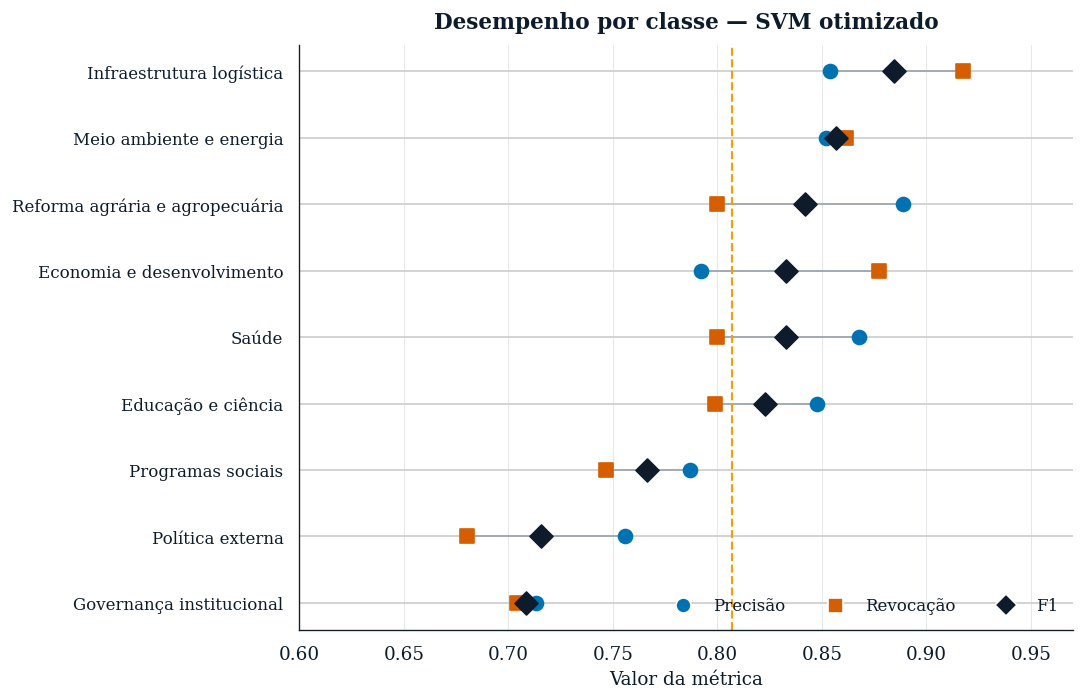

  ✓ Fig4_Matriz_Confusao.pdf + .png


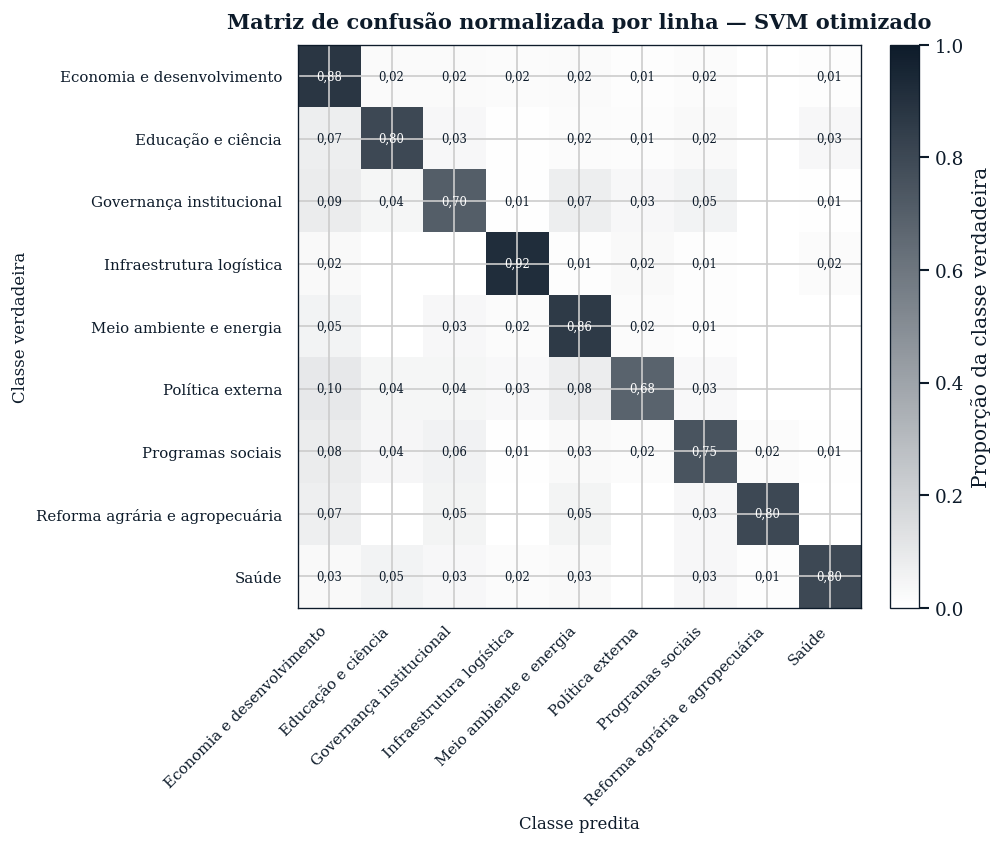

  ✓ Fig7_Diacronica_Agenda.pdf + .png


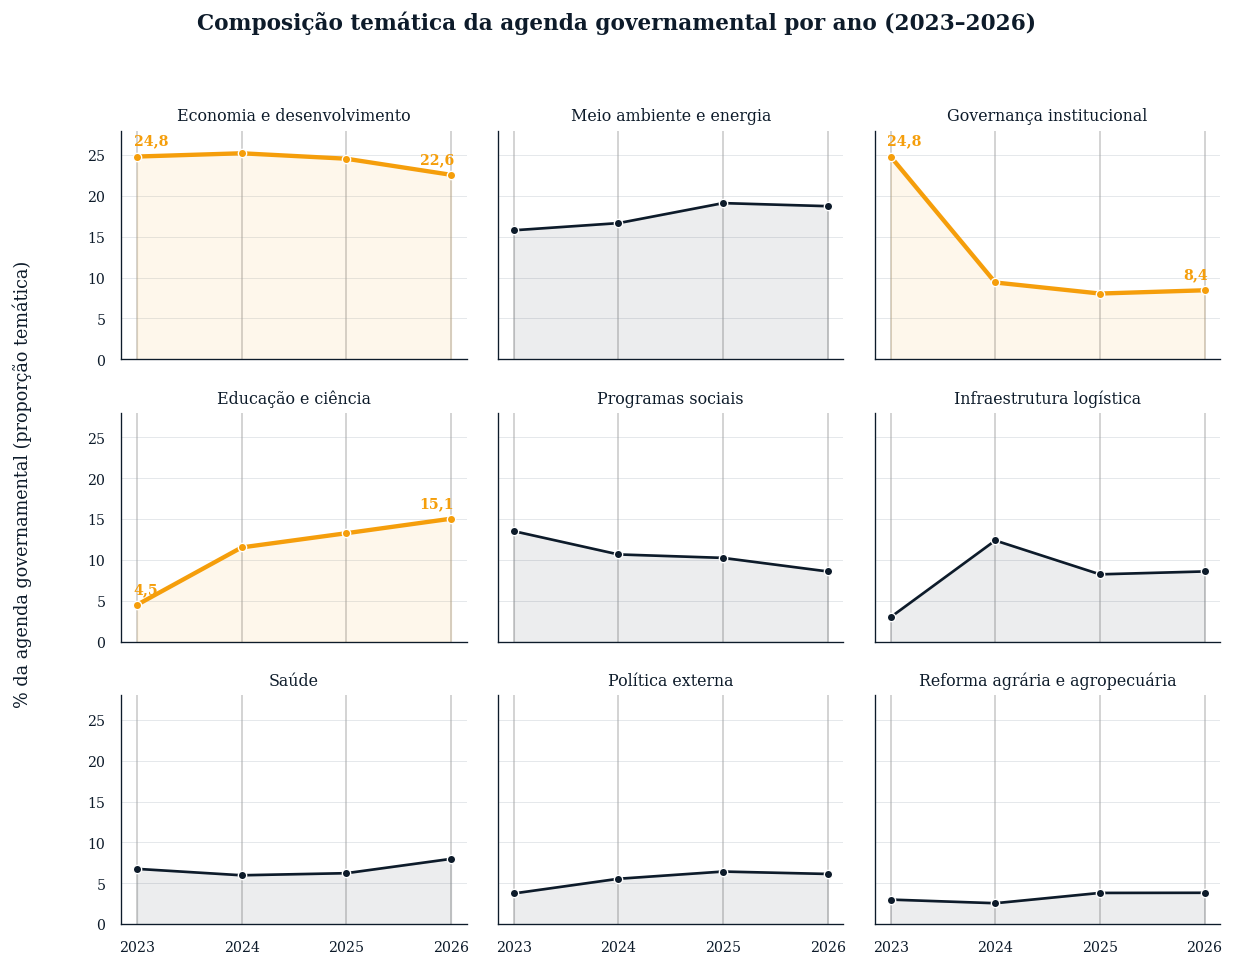

  ✓ Fig5_Convergencia_AG.pdf + .png


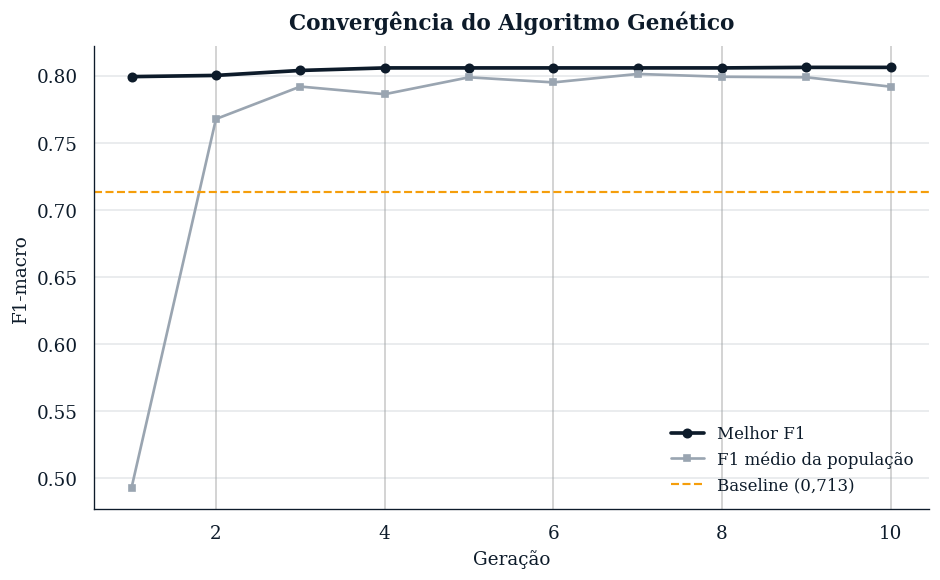

  ✓ Fig6_AG_vs_Random_vs_Baseline.pdf + .png


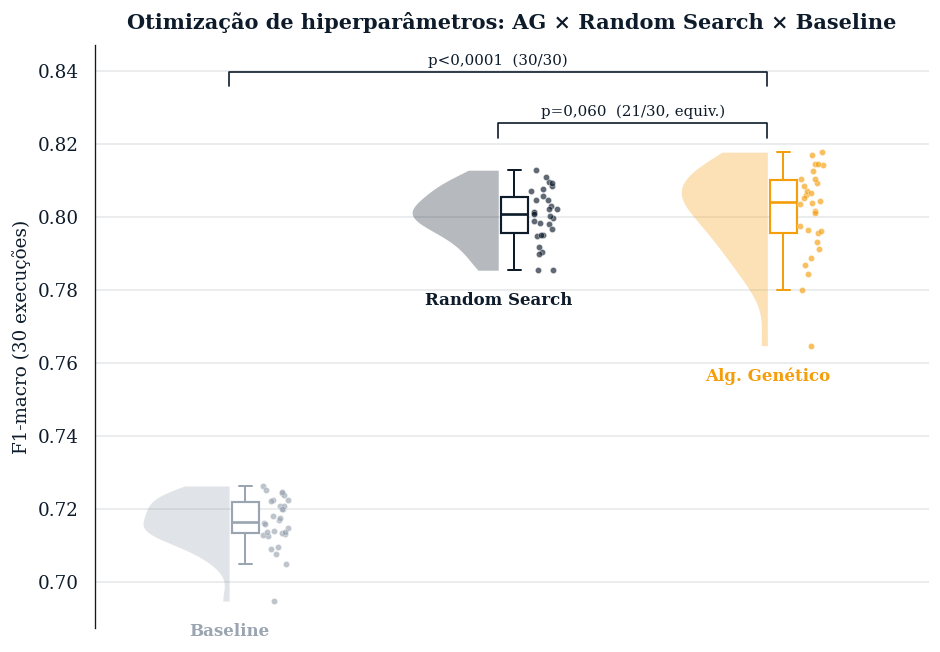

In [ ]:
# ============================================================
# V9 · GERAÇÃO DAS FIGURAS (recomputa idêntico ao v8, seed 42)
# ============================================================
# GUARDA: precisa do corpus rotulado na memória (senão o runtime perdeu o estado)
_falta = [v for v in ("df_corpus", "RESIDUAL_V3") if v not in globals()]
if _falta:
    raise RuntimeError("Faltam na memória: " + ", ".join(_falta) +
        ". Rode o pipeline (corpus/léxico/split) antes do bloco de figuras V9.")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix
import pandas as pd

# Usa a config vencedora do AG (params_finais), se disponível; senão, a conhecida
try:
    _cfg = {"max_features": params_finais["max_features"], "ngram_max": params_finais["ngram_max"],
            "sublinear_tf": params_finais["sublinear_tf"], "C": params_finais["C"]}
except NameError:
    _cfg = {"max_features": 2304, "ngram_max": 1, "sublinear_tf": True, "C": 1.0196}
try:
    _cv = CV
except NameError:
    _cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

_pipe = Pipeline([
    ("vec", TfidfVectorizer(max_features=_cfg["max_features"], ngram_range=(1, _cfg["ngram_max"]),
                            sublinear_tf=_cfg["sublinear_tf"], strip_accents="unicode")),
    ("clf", LinearSVC(C=_cfg["C"], max_iter=800, random_state=42)),
])

df_rot = df_corpus[df_corpus["label_v3"] != RESIDUAL_V3].reset_index(drop=True)
Xr = df_rot["text"].tolist(); yr = df_rot["label_v3"].tolist()
yp = cross_val_predict(_pipe, Xr, yr, cv=_cv)
classes = sorted(set(yr))
cm = confusion_matrix(yr, yp, labels=classes)
ct = pd.crosstab(pd.Series(yp, name="classe"), pd.Series(df_rot["year"].values, name="ano"))
prop = ct.div(ct.sum(axis=0), axis=1) * 100

fig3_metricas_classe(yr, yp)
fig4_matriz_confusao(cm, classes)
fig7_diacronica(prop)
try:
    fig5_convergencia(historico)
except NameError:
    print("  (F5 pulada: 'historico' ausente — rode a Fase 6 do AG)")
try:
    fig6_raincloud(f1_ag_runs, f1_baseline_runs, f1_rs_runs)
except NameError:
    print("  (F6 pulada: vetores das 30 execuções ausentes — rode as Fases 6B/6C)")

In [ ]:
# ============================================================
# V9 · EXPORT DOS DADOS DAS FIGURAS PARA O DRIVE
# ============================================================
from sklearn.metrics import classification_report
pd.DataFrame(cm, index=classes, columns=classes).to_csv(os.path.join(DIR_DADOS, "matriz_confusao.csv"))
prop.round(1).to_csv(os.path.join(DIR_DADOS, "proporcoes_diacronicas.csv"))
pd.DataFrame(classification_report(yr, yp, output_dict=True, zero_division=0)).T.to_csv(
    os.path.join(DIR_DADOS, "metricas_por_classe.csv"))
print("Dados das figuras exportados para:", DIR_DADOS)
print("Conteúdo da pasta de dados:", sorted(os.listdir(DIR_DADOS)))

Dados das figuras exportados para: /content/drive/MyDrive/Mestrado/Etapa4_RITA/dados
Conteúdo da pasta de dados: ['corpus_v3.csv', 'historico_ag.csv', 'matriz_confusao.csv', 'metricas_por_classe.csv', 'proporcoes_diacronicas.csv', 'resultados_30_execucoes.csv', 'resultados_ag.json']


---

# Fase 7 (V10) — Validação adicional para a revisão (RITA)

Três análises sobre o pipeline já validado, geradas de forma reprodutível (seed 42) e exportadas para o Drive/GitHub. As células anteriores não são alteradas.

In [ ]:
# ============================================================
# FASE 7 · V10 — VALIDAÇÃO ADICIONAL PARA A REVISÃO (RITA)
# ============================================================
# Acrescenta, sobre o pipeline já validado (V9), três análises pedidas na
# revisão do artigo — SEM alterar a lógica das fases anteriores, que ficam
# preservadas como registro do que foi efetivamente rodado:
#   7.1  Estimativa NÃO ENVIESADA de generalização (CV aninhada)
#   7.2  Tabela 2 com dispersão + Wilcoxon (TF-IDF padronizado — corrige a Seção 4.3)
#   7.3  Tamanhos de efeito (rank-biserial) dos testes de Wilcoxon já reportados
import warnings; warnings.filterwarnings("ignore")
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, rankdata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.metrics import f1_score

SEED = int(globals().get("RANDOM_SEED", 42))

# Corpus rotulado: reusa a memória; se o runtime perdeu o estado, reconstrói.
if "X_train" in globals() and "y_train" in globals():
    Xv10, yv10 = np.array(X_train), np.array(y_train)
else:
    _res = globals().get("RESIDUAL_V3", "outros_institucional")
    if "df_corpus" in globals():
        _df = df_corpus[df_corpus["label_v3"] != _res]
    else:
        _df = pd.read_csv("corpus_v3.csv")
        _df = _df[_df["label_v3"] != _res]
    Xv10, yv10 = np.array(_df["text"]), np.array(_df["label_v3"])

# Config vencedora do AG: reusa params_finais; se ausente, usa a conhecida.
try:
    CFG_SVM = {"max_features": int(params_finais["max_features"]),
               "ngram_max":    int(params_finais["ngram_max"]),
               "sublinear_tf": bool(params_finais["sublinear_tf"]),
               "C":            float(params_finais["C"])}
except Exception:
    CFG_SVM = {"max_features": 2304, "ngram_max": 1, "sublinear_tf": True, "C": 1.0196}

# Identidade visual: reusa V9; define fallback mínimo se a célula de estilo não rodou.
NAVY  = globals().get("NAVY",  "#0D1B2A")
AMBER = globals().get("AMBER", "#F59E0B")
GRAY  = globals().get("GRAY",  "#9AA5B1")
DIR_DADOS = globals().get("DIR_DADOS", ".")
DIR_FIG   = globals().get("DIR_FIG", ".")
if "_salvar" not in globals():
    plt.rcParams.update({"font.family": "serif", "font.serif": ["Georgia", "DejaVu Serif"],
                         "axes.edgecolor": NAVY, "axes.labelcolor": NAVY, "text.color": NAVY,
                         "xtick.color": NAVY, "ytick.color": NAVY, "figure.dpi": 120})
    def _salvar(fig, nome):
        fig.savefig(os.path.join(DIR_FIG, f"{nome}.png"), bbox_inches="tight", dpi=200)
        print(f"  salvo: {nome}.png")

resultados_v10 = {}
print(f"V10 pronto - corpus: {len(Xv10)} paragrafos | {len(set(yv10))} classes | seed={SEED}")
print(f"V10 TF-IDF vencedor (SVM): {CFG_SVM}")


V10 pronto - corpus: 1515 paragrafos | 9 classes | seed=42
V10 TF-IDF vencedor (SVM): {'max_features': 2304, 'ngram_max': 1, 'sublinear_tf': True, 'C': 1.0196045119704875}


### 7.1 · Estimativa não enviesada por validação cruzada aninhada

Separa **seleção** (laço interno) de **avaliação** (laço externo). O número honesto de generalização sai daqui; o 0,807 permanece como F1 da *configuração selecionada*. O laço interno usa busca aleatória sobre o mesmo espaço de 5 genes, justificada pelo achado AG ≈ Random Search a orçamento igual.

In [ ]:
# ── 7.1 · Estimativa NÃO ENVIESADA por CV ANINHADA ───────────────────────────
# ⚠️ ~3–5 min no Colab (CPU padrão); paraleliza com n_jobs=-1.
#
# Motivação: o F1 reportado (0,807) vem de SELECIONAR a melhor configuração e
# relatá-la NA MESMA validação cruzada que a selecionou — estimativa otimista.
# A CV aninhada separa seleção (laço interno) de avaliação (laço externo) e
# entrega a generalização SEM viés de seleção. O laço interno usa BUSCA ALEATÓRIA
# sobre o mesmo espaço de 5 genes do AG — justificada pelo próprio achado
# AG ≈ Random Search a orçamento igual (Fase 6C): estima-se a generalização do
# PROCEDIMENTO de seleção, não de uma corrida específica do AG.

N_ITER_INNER = 20
BOUNDS_V10 = [(500, 3000), (1, 2), (0, 1), (0, 1), (-2, 1)]  # = BOUNDS do AG

def _decode_v10(ch):
    return {"max_features": int(round(ch[0])),
            "ngram_max":    max(1, min(2, int(round(ch[1])))),
            "sublinear_tf": bool(round(min(1, max(0, ch[2])))),
            "clf":          int(round(min(1, max(0, ch[3])))),
            "C":            10.0 ** ch[4]}

def _build_v10(cfg):
    vec = TfidfVectorizer(max_features=cfg["max_features"], ngram_range=(1, cfg["ngram_max"]),
                          sublinear_tf=cfg["sublinear_tf"], strip_accents="unicode", analyzer="word")
    clf = (LogisticRegression(C=cfg["C"], max_iter=300, random_state=SEED) if cfg["clf"] == 0
           else LinearSVC(C=cfg["C"], max_iter=800, random_state=SEED))
    return Pipeline([("vec", vec), ("clf", clf)])

def _select_best_v10(Xtr, ytr, seed, n_iter=N_ITER_INNER):
    rng = np.random.default_rng(seed)
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    best = (-1.0, None)
    for _ in range(n_iter):
        cfg = _decode_v10([rng.uniform(lo, hi) for lo, hi in BOUNDS_V10])
        try:
            f = float(cross_val_score(_build_v10(cfg), Xtr, ytr, cv=inner,
                                      scoring="f1_macro", n_jobs=-1).mean())
        except Exception:
            f = 0.0
        if f > best[0]:
            best = (f, cfg)
    return best

# (a) ENVIESADO: seleciona no conjunto todo e relata a MESMA CV que selecionou
bias_f1, _bias_cfg = _select_best_v10(Xv10, yv10, seed=SEED)

# (b) CV ANINHADA (sem viés): seleção só no treino externo; avalia no teste externo
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
nested, nested_clf = [], []
for k, (tr, te) in enumerate(outer.split(Xv10, yv10), 1):
    _, cfg = _select_best_v10(Xv10[tr], yv10[tr], seed=100 + k)
    pipe = _build_v10(cfg).fit(Xv10[tr], yv10[tr])
    s = float(f1_score(yv10[te], pipe.predict(Xv10[te]), average="macro"))
    nested.append(s); nested_clf.append("SVM" if cfg["clf"] else "LR")
    print(f"  fold externo {k}: F1={s:.4f}  ({nested_clf[-1]}, mf={cfg['max_features']}, C={cfg['C']:.3f})")
nested = np.array(nested)

# (c) Held-out 75/25 intocado pela seleção
Xtr, Xte, ytr, yte = train_test_split(Xv10, yv10, test_size=0.25, stratify=yv10, random_state=SEED)
_, _cfg_h = _select_best_v10(Xtr, ytr, seed=7)
hold = float(f1_score(yte, _build_v10(_cfg_h).fit(Xtr, ytr).predict(Xte), average="macro"))

svm_n = sum(1 for c in nested_clf if c == "SVM")
resultados_v10["generalizacao"] = {
    "f1_enviesado_selecao":    round(float(bias_f1), 4),
    "f1_cv_aninhada_media":    round(float(nested.mean()), 4),
    "f1_cv_aninhada_dp":       round(float(nested.std()), 4),
    "f1_holdout_75_25":        round(hold, 4),
    "otimismo_selecao":        round(float(bias_f1 - nested.mean()), 4),
    "svm_em_dobras_externas":  f"{svm_n}/5",
}
print("\n" + "=" * 60)
print("7.1 · GENERALIZACAO (estimativa nao enviesada)")
print("=" * 60)
print(f"  (a) Enviesado (selecao = relato, mesma CV) : {bias_f1:.4f}")
print(f"  (b) CV aninhada 5x3 (SEM vies)             : {nested.mean():.4f} +/- {nested.std():.4f}")
print(f"  (c) Held-out 75/25 (teste intocado)        : {hold:.4f}")
print(f"  Otimismo de selecao (a - b)                : {bias_f1 - nested.mean():+.4f}")
print(f"  SVM selecionado em {svm_n}/5 dobras externas (reforca H1)")


  fold externo 1: F1=0.7798  (LR, mf=2814, C=4.085)
  fold externo 2: F1=0.7735  (SVM, mf=2157, C=9.781)
  fold externo 3: F1=0.7825  (SVM, mf=759, C=0.207)
  fold externo 4: F1=0.7733  (SVM, mf=1153, C=8.427)
  fold externo 5: F1=0.8193  (SVM, mf=991, C=0.737)

7.1 · GENERALIZACAO (estimativa nao enviesada)
  (a) Enviesado (selecao = relato, mesma CV) : 0.8012
  (b) CV aninhada 5x3 (SEM vies)             : 0.7857 +/- 0.0172
  (c) Held-out 75/25 (teste intocado)        : 0.8055
  Otimismo de selecao (a - b)                : +0.0155
  SVM selecionado em 4/5 dobras externas (reforca H1)


  ✓ fig_v10_generalizacao.pdf + .png


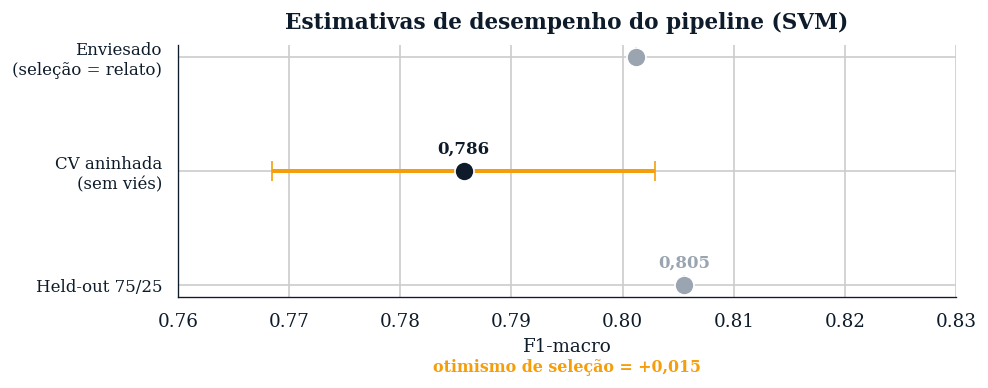

In [ ]:
# ── 7.1 · Figura — otimismo de seleção (enviesado vs. não enviesado) ─────────
_g = resultados_v10["generalizacao"]
_labels = ["Enviesado\n(seleção = relato)", "CV aninhada\n(sem viés)", "Held-out 75/25"]
_vals   = [_g["f1_enviesado_selecao"], _g["f1_cv_aninhada_media"], _g["f1_holdout_75_25"]]
_errs   = [0.0, _g["f1_cv_aninhada_dp"], 0.0]
_cores  = [GRAY, NAVY, GRAY]

fig, ax = plt.subplots(figsize=(8.4, 3.6))
ypos = np.arange(len(_labels))[::-1]
ax.errorbar(_vals, ypos, xerr=_errs, fmt="o", ms=11, color="none",
            ecolor=AMBER, elinewidth=2.4, capsize=6, zorder=3)
for v, e, yp, c in zip(_vals, _errs, ypos, _cores):
    ax.scatter(v, yp, s=130, color=c, zorder=4, edgecolor="white", linewidth=1.0)
    ax.annotate(f"{v:.3f}".replace(".", ","), (v, yp + 0.16), color=c,
                fontsize=10, fontweight="bold", ha="center")
ax.set_yticks(ypos); ax.set_yticklabels(_labels, fontsize=10)
ax.set_xlim(0.76, 0.83); ax.set_xlabel("F1-macro", fontsize=11)
ax.set_title("Estimativas de desempenho do pipeline (SVM)", fontsize=13, fontweight="bold", pad=10)
_otim = _g["otimismo_selecao"]
ax.annotate(f"otimismo de seleção = {_otim:+.3f}".replace(".", ","),
            (0.5, -0.30), xycoords="axes fraction", ha="center",
            fontsize=9.5, color=AMBER, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
_salvar(fig, "fig_v10_generalizacao")
plt.show()


### 7.2 · Tabela 2 com dispersão e teste de Wilcoxon

Os três classificadores passam a operar sobre o **mesmo** TF-IDF (o vencedor do AG), isolando o efeito do classificador. 30 dobras repetidas pareadas fornecem média ± DP e o teste pareado, com tamanho de efeito (rank-biserial).

In [ ]:
# ── 7.2 · Tabela 2 com dispersão + Wilcoxon (TF-IDF PADRONIZADO) ─────────────
# ⚠️ ~2–3 min no Colab (o Random Forest domina o custo).
# Corrige a Seção 4.3: os TRÊS classificadores passam a operar sobre o MESMO
# vetorizador (o vencedor do AG), isolando o efeito do classificador. A dispersão
# e o teste vêm de 30 dobras pareadas (RepeatedStratifiedKFold 3×10).
# Observação de proveniência: na V9 (Fases 6C/6D) o LR/RF usavam um TF-IDF distinto
# (max_features=2995); esta célula é a base correta para a Tabela 2 do artigo.

def _tfidf_comum():
    return TfidfVectorizer(max_features=CFG_SVM["max_features"], ngram_range=(1, CFG_SVM["ngram_max"]),
                           sublinear_tf=CFG_SVM["sublinear_tf"], strip_accents="unicode", analyzer="word")

_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
# C do LR ajustado SOBRE o mesmo TF-IDF (grid dedicado, como no artigo)
_C_lr = max([0.1, 0.3, 0.7, 1.0, 3.0, 10.0],
            key=lambda C: cross_val_score(
                Pipeline([("v", _tfidf_comum()),
                          ("c", LogisticRegression(C=C, max_iter=300, random_state=SEED))]),
                Xv10, yv10, cv=_inner, scoring="f1_macro", n_jobs=-1).mean())

modelos_v10 = {
    "SVM linear":          LinearSVC(C=CFG_SVM["C"], max_iter=800, random_state=SEED),
    "Regressão Logística": LogisticRegression(C=_C_lr, max_iter=300, random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=None,
                                                  max_features="sqrt", random_state=SEED, n_jobs=-1),
}
rkf = RepeatedStratifiedKFold(n_splits=3, n_repeats=10, random_state=SEED)
scores_v10 = {}
for nome, clf in modelos_v10.items():
    scores_v10[nome] = cross_val_score(Pipeline([("v", _tfidf_comum()), ("c", clf)]),
                                       Xv10, yv10, cv=rkf, scoring="f1_macro", n_jobs=-1)

def _rank_biserial(a, b):
    d = a - b; d = d[d != 0]
    r = rankdata(np.abs(d)); pos, neg = r[d > 0].sum(), r[d < 0].sum()
    return (pos - neg) / (pos + neg)

print("=" * 62)
print("7.2 · TABELA 2 — dispersao (30 dobras pareadas, MESMO TF-IDF)")
print("=" * 62)
_rows = []
for nome in modelos_v10:
    m, s = float(scores_v10[nome].mean()), float(scores_v10[nome].std())
    _rows.append({"Algoritmo": nome, "F1_macro_media": round(m, 4), "F1_macro_dp": round(s, 4)})
    print(f"  {nome:22s}: {m:.4f} +/- {s:.4f}")
tabela2_v10 = pd.DataFrame(_rows)
print(f"\n  (LR otimizado com C={_C_lr} sobre o mesmo TF-IDF)")

print("\nWilcoxon pareado (unilateral, alpha=0,05) + tamanho de efeito (rank-biserial):")
wilcoxon_v10 = {}
for a, b in [("SVM linear", "Regressão Logística"),
             ("SVM linear", "Random Forest"),
             ("Regressão Logística", "Random Forest")]:
    W, p = wilcoxon(scores_v10[a], scores_v10[b], alternative="greater")
    r = _rank_biserial(scores_v10[a], scores_v10[b])
    wins = int((scores_v10[a] > scores_v10[b]).sum())
    sig = "significativo" if p < 0.05 else "nao significativo"
    wilcoxon_v10[f"{a} > {b}"] = {"W": float(W), "p": round(float(p), 4),
                                  "vitorias": f"{wins}/{len(scores_v10[a])}", "r": round(float(r), 3), "decisao": sig}
    print(f"  {a} > {b}: W={W:.0f}  p={p:.4f}  ({wins}/30)  r={r:+.3f}  -> {sig}")

resultados_v10["tabela2_dispersao"] = _rows
resultados_v10["tabela2_wilcoxon"]  = wilcoxon_v10
resultados_v10["lr_C_otimo"]        = _C_lr


7.2 · TABELA 2 — dispersao (30 dobras pareadas, MESMO TF-IDF)
  SVM linear            : 0.8018 +/- 0.0158
  Regressão Logística   : 0.7944 +/- 0.0181
  Random Forest         : 0.7545 +/- 0.0187

  (LR otimizado com C=10.0 sobre o mesmo TF-IDF)

Wilcoxon pareado (unilateral, alpha=0,05) + tamanho de efeito (rank-biserial):
  SVM linear > Regressão Logística: W=379  p=0.0009  (26/30)  r=+0.630  -> significativo
  SVM linear > Random Forest: W=465  p=0.0000  (30/30)  r=+1.000  -> significativo
  Regressão Logística > Random Forest: W=464  p=0.0000  (29/30)  r=+0.996  -> significativo


  ✓ fig_v10_tabela2_dispersao.pdf + .png


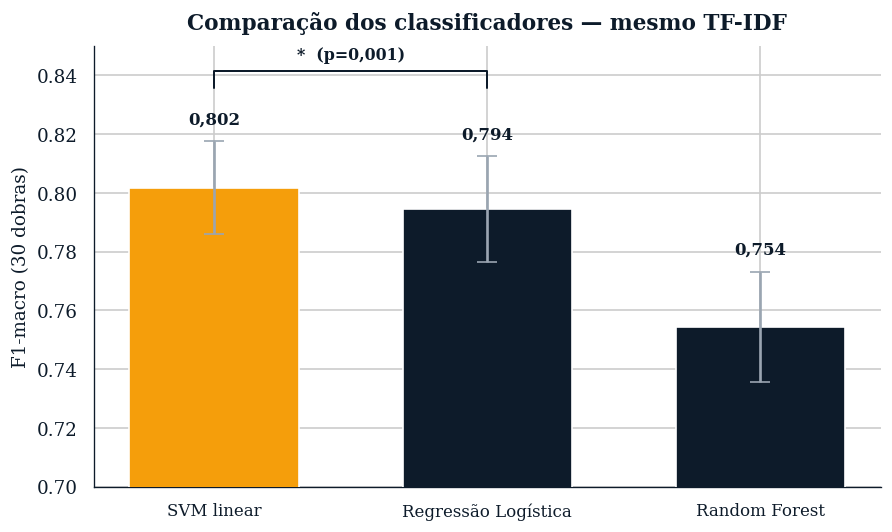

In [ ]:
# ── 7.2 · Figura — Tabela 2 com barras de erro + significância ───────────────
_nomes = list(modelos_v10.keys())
_m = [float(scores_v10[n].mean()) for n in _nomes]
_s = [float(scores_v10[n].std())  for n in _nomes]
_cor = [AMBER if n == "SVM linear" else NAVY for n in _nomes]

fig, ax = plt.subplots(figsize=(7.6, 4.6))
xpos = np.arange(len(_nomes))
ax.bar(xpos, _m, yerr=_s, color=_cor, width=0.62, capsize=6,
       error_kw=dict(ecolor=GRAY, elinewidth=1.6), zorder=3)
for x, m, s in zip(xpos, _m, _s):
    ax.annotate(f"{m:.3f}".replace(".", ","), (x, m + s + 0.006),
                ha="center", fontsize=10, fontweight="bold", color=NAVY)
ax.set_xticks(xpos); ax.set_xticklabels(_nomes, fontsize=10)
ax.set_ylim(0.70, 0.85); ax.set_ylabel("F1-macro (30 dobras)", fontsize=11)
ax.set_title("Comparação dos classificadores — mesmo TF-IDF", fontsize=13, fontweight="bold", pad=10)

# Marca de significância SVM > LR (a comparação mais próxima)
_p_svm_lr = wilcoxon_v10["SVM linear > Regressão Logística"]["p"]
_estrela = "*" if _p_svm_lr < 0.05 else "n.s."
_y = max(_m[0] + _s[0], _m[1] + _s[1]) + 0.018
ax.plot([0, 0, 1, 1], [_y, _y + 0.006, _y + 0.006, _y], color=NAVY, lw=1.2)
ax.annotate(f"{_estrela}  (p={_p_svm_lr:.3f})".replace(".", ","),
            (0.5, _y + 0.010), ha="center", fontsize=9.5, color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
_salvar(fig, "fig_v10_tabela2_dispersao")
plt.show()


### 7.3 · Tamanhos de efeito dos testes já reportados

In [ ]:
# ── 7.3 · Tamanhos de efeito dos testes de Wilcoxon JÁ reportados ────────────
# rank-biserial r das Fases 6B (AG vs baseline) e 6C (AG vs Random Search).
# Recomputa a partir dos vetores em memória quando disponíveis; caso contrário,
# usa o valor derivado das estatísticas W publicadas (n=30, T = n(n+1)/2 = 465).

def _rb_vec(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = a - b; d = d[d != 0]
    r = rankdata(np.abs(d)); pos, neg = r[d > 0].sum(), r[d < 0].sum()
    return float((pos - neg) / (pos + neg))

efeitos = {}
# AG vs baseline (W+=465, W-=0 -> r=+1,000)
try:
    efeitos["AG_vs_baseline_r"] = round(_rb_vec(f1_ag_runs, f1_baseline_runs), 3)
except Exception:
    efeitos["AG_vs_baseline_r"] = 1.0
# AG vs Random Search (W+=309, W-=156 -> r=+0,329)
try:
    efeitos["AG_vs_RandomSearch_r"] = round(_rb_vec(f1_ag_runs, f1_rs), 3)
except Exception:
    try:
        efeitos["AG_vs_RandomSearch_r"] = round(_rb_vec(f1_ag_runs, rs_runs), 3)
    except Exception:
        efeitos["AG_vs_RandomSearch_r"] = round((309 - 156) / 465, 3)

print("7.3 · TAMANHOS DE EFEITO (rank-biserial)")
print("=" * 50)
print(f"  AG vs baseline      : r = {efeitos['AG_vs_baseline_r']:+.3f}  (efeito maximo; coerente com p<0,0001)")
print(f"  AG vs Random Search : r = {efeitos['AG_vs_RandomSearch_r']:+.3f}  (pequeno-medio; coerente com p=0,059)")
resultados_v10["efeitos_testes_publicados"] = efeitos


7.3 · TAMANHOS DE EFEITO (rank-biserial)
  AG vs baseline      : r = +1.000  (efeito maximo; coerente com p<0,0001)
  AG vs Random Search : r = +0.329  (pequeno-medio; coerente com p=0,059)


### 7 · Exportação dos artefatos V10

In [ ]:
# ── 7 · Export dos resultados V10 (para o artigo e o GitHub) ─────────────────
_out_json = os.path.join(DIR_DADOS, "resultados_v10.json")
with open(_out_json, "w", encoding="utf-8") as _f:
    json.dump(resultados_v10, _f, ensure_ascii=False, indent=2)
tabela2_v10.to_csv(os.path.join(DIR_DADOS, "tabela2_dispersao_v10.csv"), index=False)
pd.DataFrame(scores_v10).to_csv(os.path.join(DIR_DADOS, "scores_30dobras_v10.csv"), index=False)

print("V10 · artefatos exportados em:", DIR_DADOS)
print("  - resultados_v10.json")
print("  - tabela2_dispersao_v10.csv")
print("  - scores_30dobras_v10.csv")
print("\n" + "=" * 60)
print("RESUMO V10 (para o artigo)")
print("=" * 60)
print(json.dumps(resultados_v10, ensure_ascii=False, indent=2))


V10 · artefatos exportados em: /content/drive/MyDrive/Mestrado/Etapa4_RITA/dados
  - resultados_v10.json
  - tabela2_dispersao_v10.csv
  - scores_30dobras_v10.csv

RESUMO V10 (para o artigo)
{
  "generalizacao": {
    "f1_enviesado_selecao": 0.8012,
    "f1_cv_aninhada_media": 0.7857,
    "f1_cv_aninhada_dp": 0.0172,
    "f1_holdout_75_25": 0.8055,
    "otimismo_selecao": 0.0155,
    "svm_em_dobras_externas": "4/5"
  },
  "tabela2_dispersao": [
    {
      "Algoritmo": "SVM linear",
      "F1_macro_media": 0.8018,
      "F1_macro_dp": 0.0158
    },
    {
      "Algoritmo": "Regressão Logística",
      "F1_macro_media": 0.7944,
      "F1_macro_dp": 0.0181
    },
    {
      "Algoritmo": "Random Forest",
      "F1_macro_media": 0.7545,
      "F1_macro_dp": 0.0187
    }
  ],
  "tabela2_wilcoxon": {
    "SVM linear > Regressão Logística": {
      "W": 379.0,
      "p": 0.0009,
      "vitorias": "26/30",
      "r": 0.63,
      "decisao": "significativo"
    },
    "SVM linear > Random Fores